# Time Series Analysis on Diabetes Data — BrisT1D

## Project Objective

This notebook develops and compares several predictive modeling approaches for the blood glucose levels of a patient with type 1 diabetes, starting from the **BrisT1D Blood Glucose Prediction** dataset (Kaggle). The work follows this pipeline: from reconstructing a usable time series from a non-standard data format, to a systematic comparison among classical statistical models (SARIMA, SARIMAX), an additive component model (Prophet), a non-linear tree-based model (Gradient Boosting), and a recurrent neural network (LSTM).

A methodological note runs throughout the entire notebook and is worth highlighting in advance: the original dataset is not distributed as a regular time series, but rather as a "wide" table designed for a supervised regression task (the target of the Kaggle competition, `bg+1:00`, is the blood glucose level one hour into the future relative to each row).

## Phase 1 — Dataset Selection and Documentation
The selected dataset is the **BrisT1D Blood Glucose Prediction Dataset**, published on Kaggle as part of the eponymous competition.

URL: https://www.kaggle.com/competitions/brist1d

The dataset originates from an observational study conducted on a cohort of young adults in the United Kingdom diagnosed with **Type 1 Diabetes (T1D)**. Participants concurrently wore a continuous glucose monitoring (CGM) sensor, an insulin pump, and a smartwatch over a period ranging from approximately three to over six months, depending on the participant. 

The raw data were aggregated by the competition organizers into 5-minute intervals and distributed in tabular format (`train.csv`, `test.csv`, `activities.txt`, `sample_submission.csv`) under a Creative Commons Attribution 4.0 license.

The dataset is not distributed as a traditional "long" time series (one row per timestamp), but in a *wide/lag* format: each row (identified by `id` and the participant `p_num`) represents a single point in time and contains, for each monitored variable, a sequence of columns reporting the values recorded every 5 minutes over the preceding 6 hours (suffix `-X:XX`, from `-5:55` to `-0:00`). The target variable is the blood glucose level one hour into the future relative to the row's timestamp.

| **Column / Group** | **Unit** | **Description** |
|----------------------|-----------|-----------------|
| `p_num`, `time`, `id` | - | Participant identifier, recording timestamp, and unique row key; they constitute the temporal/demographic component of the dataset. |
| `bg-X:XX` | mmol/L | Blood glucose level recorded by the CGM across the preceding 5-minute intervals. |
| `insulin-X:XX` | U (units) | Total insulin dose delivered by the insulin pump in the preceding 5 minutes. |
| `carbs-X:XX` | g | Amount of carbohydrates consumed, reported by the patient in the insulin pump/reader. |
| `hr-X:XX` | bpm | Average heart rate measured by the smartwatch. |
| `steps-X:XX` | count | Step count recorded by the smartwatch. |
| `cals-X:XX` | kcal | Calories burned, estimated by the smartwatch. |
| `activity-X:XX` | categorical | Type of physical activity performed (e.g., walking, running, cycling), to be mapped via `activities.txt`. |
| `bg+1:00` | mmol/L | **Target:** predicted blood glucose level one hour after the row's timestamp. |

*Methodological note: for classical time series analyses (decomposition, ADF/KPSS, ACF/PACF, ARIMA/SARIMA), it is necessary to reconstruct, for each `p_num`, a continuous chronologically ordered series from the `bg-X:XX` columns of consecutive rows, as the "sliding window" format provided by the competition is designed for a supervised tabular approach rather than a univariate time series analysis.*

### Rationale for Selection
- **Real and recent clinical data**: collected via certified medical devices (CGM, insulin pump) and wearables, not simulated;

- Native high-frequency temporal component (5 minutes), suitable for resampling, seasonal decomposition (circadian rhythms), and predictive modeling;

- **Multivariate**: in addition to blood glucose, insulin, carbohydrates, and physical activity data are available, allowing models to be enriched with exogenous variables (SARIMAX, features for LSTM);

- Sufficient size and quality to support a temporally separated test set for validation;

- **Clinical relevance**: predicting future blood glucose levels is a timely and critical challenge in the management of type 1 diabetes, forming the foundation of modern "hybrid closed-loop" systems (artificial pancreas).

### Ethical and Privacy Considerations

-   **Sensitive health data**: blood glucose levels, insulin dosages, and physiological parameters fall under special categories of personal data under the GDPR (Art. 9), even though used here for educational purposes on previously published data.

-   **Pseudonymization**: participants are identified by codes (`p_num`) rather than direct identifying personal data; however, the combination of high-frequency behavioral patterns (activity, meal times, dosages) poses a residual risk of re-identification, typical of longitudinal wearable data.

-   **Consent and purpose**: data were collected within a clinical study with participants' informed consent and made public by the competition organizers for research purposes; its use in this project aligns with this non-commercial, educational/research purpose.

-   **Limited generalizability**: the sample comprises a small cohort of young adults in the UK; predictive models developed herein should not be considered validated for broader or more heterogeneous clinical populations.

-   **Clinical use**: project results are exclusively for educational purposes and do not constitute a medical device nor support for real-world therapeutic decision-making.

## Phase 2 - Time Series Analysis

In [25]:
# Data Manipulation and Visualization
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Time Series Analysis Tools: Decomposition, Stationarity Tests, ACF/PACF
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# forecasting models
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from prophet import Prophet

# evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.rcParams["figure.figsize"] = (14, 5)
RANDOM_STATE = 42

## 1. Loading the Dataset

In [26]:
DATA_DIR = Path("Data")
# load the dataset
df = pd.read_csv(DATA_DIR / "train.csv")


I import the training CSV provided by Kaggle; the idea is to study the training dataset, derive a validation set from it, and ultimately evaluate the winning models on the test set provided by Kaggle.

In [27]:
print(df.shape)

(177024, 508)


In [28]:
pd.set_option('display.max_columns', None)
display(df)

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,bg-5:20,bg-5:15,bg-5:10,bg-5:05,bg-5:00,bg-4:55,bg-4:50,bg-4:45,bg-4:40,bg-4:35,bg-4:30,bg-4:25,bg-4:20,bg-4:15,bg-4:10,bg-4:05,bg-4:00,bg-3:55,bg-3:50,bg-3:45,bg-3:40,bg-3:35,bg-3:30,bg-3:25,bg-3:20,bg-3:15,bg-3:10,bg-3:05,bg-3:00,bg-2:55,bg-2:50,bg-2:45,bg-2:40,bg-2:35,bg-2:30,bg-2:25,bg-2:20,bg-2:15,bg-2:10,bg-2:05,bg-2:00,bg-1:55,bg-1:50,bg-1:45,bg-1:40,bg-1:35,bg-1:30,bg-1:25,bg-1:20,bg-1:15,bg-1:10,bg-1:05,bg-1:00,bg-0:55,bg-0:50,bg-0:45,bg-0:40,bg-0:35,bg-0:30,bg-0:25,bg-0:20,bg-0:15,bg-0:10,bg-0:05,bg-0:00,insulin-5:55,insulin-5:50,insulin-5:45,insulin-5:40,insulin-5:35,insulin-5:30,insulin-5:25,insulin-5:20,insulin-5:15,insulin-5:10,insulin-5:05,insulin-5:00,insulin-4:55,insulin-4:50,insulin-4:45,insulin-4:40,insulin-4:35,insulin-4:30,insulin-4:25,insulin-4:20,insulin-4:15,insulin-4:10,insulin-4:05,insulin-4:00,insulin-3:55,insulin-3:50,insulin-3:45,insulin-3:40,insulin-3:35,insulin-3:30,insulin-3:25,insulin-3:20,insulin-3:15,insulin-3:10,insulin-3:05,insulin-3:00,insulin-2:55,insulin-2:50,insulin-2:45,insulin-2:40,insulin-2:35,insulin-2:30,insulin-2:25,insulin-2:20,insulin-2:15,insulin-2:10,insulin-2:05,insulin-2:00,insulin-1:55,insulin-1:50,insulin-1:45,insulin-1:40,insulin-1:35,insulin-1:30,insulin-1:25,insulin-1:20,insulin-1:15,insulin-1:10,insulin-1:05,insulin-1:00,insulin-0:55,insulin-0:50,insulin-0:45,insulin-0:40,insulin-0:35,insulin-0:30,insulin-0:25,insulin-0:20,insulin-0:15,insulin-0:10,insulin-0:05,insulin-0:00,carbs-5:55,carbs-5:50,carbs-5:45,carbs-5:40,carbs-5:35,carbs-5:30,carbs-5:25,carbs-5:20,carbs-5:15,carbs-5:10,carbs-5:05,carbs-5:00,carbs-4:55,carbs-4:50,carbs-4:45,carbs-4:40,carbs-4:35,carbs-4:30,carbs-4:25,carbs-4:20,carbs-4:15,carbs-4:10,carbs-4:05,carbs-4:00,carbs-3:55,carbs-3:50,carbs-3:45,carbs-3:40,carbs-3:35,carbs-3:30,carbs-3:25,carbs-3:20,carbs-3:15,carbs-3:10,carbs-3:05,carbs-3:00,carbs-2:55,carbs-2:50,carbs-2:45,carbs-2:40,carbs-2:35,carbs-2:30,carbs-2:25,carbs-2:20,carbs-2:15,carbs-2:10,carbs-2:05,carbs-2:00,carbs-1:55,carbs-1:50,carbs-1:45,carbs-1:40,carbs-1:35,carbs-1:30,carbs-1:25,carbs-1:20,carbs-1:15,carbs-1:10,carbs-1:05,carbs-1:00,carbs-0:55,carbs-0:50,carbs-0:45,carbs-0:40,carbs-0:35,carbs-0:30,carbs-0:25,carbs-0:20,carbs-0:15,carbs-0:10,carbs-0:05,carbs-0:00,hr-5:55,hr-5:50,hr-5:45,hr-5:40,hr-5:35,hr-5:30,hr-5:25,hr-5:20,hr-5:15,hr-5:10,hr-5:05,hr-5:00,hr-4:55,hr-4:50,hr-4:45,hr-4:40,hr-4:35,hr-4:30,hr-4:25,hr-4:20,hr-4:15,hr-4:10,hr-4:05,hr-4:00,hr-3:55,hr-3:50,hr-3:45,hr-3:40,hr-3:35,hr-3:30,hr-3:25,hr-3:20,hr-3:15,hr-3:10,hr-3:05,hr-3:00,hr-2:55,hr-2:50,hr-2:45,hr-2:40,hr-2:35,hr-2:30,hr-2:25,hr-2:20,hr-2:15,hr-2:10,hr-2:05,hr-2:00,hr-1:55,hr-1:50,hr-1:45,hr-1:40,hr-1:35,hr-1:30,hr-1:25,hr-1:20,hr-1:15,hr-1:10,hr-1:05,hr-1:00,hr-0:55,hr-0:50,hr-0:45,hr-0:40,hr-0:35,hr-0:30,hr-0:25,hr-0:20,hr-0:15,hr-0:10,hr-0:05,hr-0:00,steps-5:55,steps-5:50,steps-5:45,steps-5:40,steps-5:35,steps-5:30,steps-5:25,steps-5:20,steps-5:15,steps-5:10,steps-5:05,steps-5:00,steps-4:55,steps-4:50,steps-4:45,steps-4:40,steps-4:35,steps-4:30,steps-4:25,steps-4:20,steps-4:15,steps-4:10,steps-4:05,steps-4:00,steps-3:55,steps-3:50,steps-3:45,steps-3:40,steps-3:35,steps-3:30,steps-3:25,steps-3:20,steps-3:15,steps-3:10,steps-3:05,steps-3:00,steps-2:55,steps-2:50,steps-2:45,steps-2:40,steps-2:35,steps-2:30,steps-2:25,steps-2:20,steps-2:15,steps-2:10,steps-2:05,steps-2:00,steps-1:55,steps-1:50,steps-1:45,steps-1:40,steps-1:35,steps-1:30,steps-1:25,steps-1:20,steps-1:15,steps-1:10,steps-1:05,steps-1:00,steps-0:55,steps-0:50,steps-0:45,steps-0:40,steps-0:35,steps-0:30,steps-0:25,steps-0:20,steps-0:15,steps-0:10,steps-0:05,steps-0:00,cals-5:55,cals-5:50,cals-5:45,cals-5:40,cals-5:35,cals-5:30,cals-5:25,cals-5:20,cals-5:15,cals-5:10,cals-5:05,cals-5:00,cals-4:55,cals-4:50,cals-4:45,cals-4:40,cals-4:35,cals-4:30,cals-4:25,cals-4:20,cals-4:15,cals-4:10,cals-4:05,cals-4:00,cals-3:55,cals-3:50,cals-3:45,cals-3:40,cals-3:35,cals-3:30,cals-3:25,cal

## 2. Time Series Reconstruction

The `train.csv` file provided by Kaggle is not organized as a time series, but rather as a **wide** format table: each row represents a single clinical sample and contains, across separate columns, the entire window of the preceding 6 hours (sampled every 5 minutes) for blood glucose (`bg-X:XX`), insulin (`insulin-X:XX`), carbohydrates (`carbs-X:XX`), heart rate, steps, calories, and physical activity, in addition to the target `bg+1:00` — the blood glucose level one hour into the future relative to the row's timestamp.

This format is optimal for a tabular regression task (which is how most solutions in the Kaggle competition approach the problem, typically using tree-based models), but it does not constitute a regular time series to which classical time series analysis tools (seasonal decomposition, stationarity tests, autocorrelation, ARIMA models) can be applied.

**My methodological choice**: to obtain a continuous time series, I extracted the `bg-0:00` column — the "current" blood glucose level of each row — for a single patient (`p01`), along with its actual timestamp. Since the dataset does not provide an absolute calendar date (for participant privacy reasons), but does provide the time of day (`time`) and the chronological acquisition order of the rows, I reconstructed a relative time axis by assigning a fictitious starting date and incrementing the "day" each time the time of day rolls back (indicating the passage of midnight).

The analysis focuses on a single patient, rather than an aggregate of multiple patients, for a precise statistical reason: blood glucose levels across different individuals do not share the same generative distribution (baseline, insulin sensitivity, and individual variability differ significantly from person to person); therefore, aggregating them into a single series would violate the process homogeneity assumption upon which classical time series models rely.

In [29]:
# Examining the first patient
PATIENT= 'p01'
df_p=df[df['p_num']==PATIENT].copy() # Creating a new DataFrame with only the selected patient's information

# Converting 'time' (time of day only, without date) into a time object in order to compare it
df_p['time']=pd.to_datetime(df_p['time'], format='%H:%M:%S').dt.time



In [30]:
# The order of the rows reflects the chronological acquisition order for the patient.
# I derive a relative timestamp to construct a continuous time axis 
# (handling the passage of midnight as a new day).
day = 0
timestamps = []
prev_t = None
for t in df_p['time']:
    if prev_t is not None and t < prev_t: # If t is greater, then midnight has passed and therefore I must increment the day
        day += 1
    timestamps.append(pd.Timestamp("2024-01-01") + pd.Timedelta(days=day,
                        hours=t.hour, minutes=t.minute, seconds=t.second))
    prev_t = t
df_p['timestamp'] = timestamps

# I extract only the bg-0:00 column ("current" blood glucose of each row) as a univariate
# time series; I remove temporal duplicates (due to the overlapping window structure
# of the original dataset) and sort chronologically
series = df_p[["timestamp", "bg-0:00"]].rename(columns={"bg-0:00": "bg"}).dropna()
series = series.drop_duplicates(subset="timestamp").sort_values("timestamp")
series = series.set_index("timestamp")
print(f"Patient {PATIENT}: {len(series)} observations, from {series.index.min()} to {series.index.max()}")
series.head()

# I entered 2024 because the Kaggle competition dates back to September, two years ago

Patient p01: 7716 observations, from 2024-01-01 06:10:00 to 2024-03-31 23:50:00


,bg
timestamp,
2024-01-01 06:10:00,15.1
2024-01-01 06:25:00,14.4
2024-01-01 06:40:00,13.9
2024-01-01 06:55:00,13.8
2024-01-01 07:10:00,13.4


In [31]:
print(series.shape)

(7716, 1)


## 3. Time Series Preprocessing

### 3.1 Determining the Actual Sensor Resolution

An initial 5-minute resampling yields a coverage of only 29.5% of the expected observations — a value too low to be explained by mere missing measurements. Analyzing the most frequent time intervals between consecutive observations reveals that the CGM sensor (or the data export configuration) actually samples **every 15 minutes**, not every 5 as might be assumed from the column names of the original dataset (`bg-0:05`, `bg-0:10`, ...). Resampling at the actual resolution of the sensor increases coverage to 88.6%, a value far more consistent with a properly functioning device subject to occasional interruptions.

In [32]:

# After creating the time series for the first patient, I proceed to preprocessing
# From the head above, it is evident that not all measurements are recorded every 5 min, resulting in temporal gaps

# Creating the regular 5-minute grid
bg= series['bg'].resample('5min').mean()
print(f'Coverage: {bg.notna().mean()*100:.1f}%  | Observations: {len(bg)}')




Coverage: 29.5%  | Observations: 26133


Therefore, with the 5-minute resampling, the number of observations increased from 7,716 to 26,133, but only 29% of the observations are valid; the rest are NaN.

#### Why is the coverage so low?
I found online that many commercially available sensors record measurements every 15 minutes rather than every 5, as expected from the CGM. This means that measurements might only be present every three time "slots"; therefore, theoretically, one should expect around 33.3% coverage across the 26,000 observations, which is consistent with the obtained result (which might be slightly lower because other factors, such as malfunctions or other issues, may have prevented measurement).

I now check the most frequent timestamps:

In [33]:
# The 5-minute resampling yields an anomalous coverage (~30%): I empirically verify
# the actual sampling frequency of the sensor, rather than assuming it from the column names
delta_temporali = series.index.to_series().diff()

# Displaying the 10 most frequent time intervals in the dataset
print("Most frequent time intervals between measurements:")
print(delta_temporali.value_counts().head(10))

Most frequent time intervals between measurements:
timestamp
0 days 00:15:00    7476
0 days 01:20:00     134
0 days 00:30:00      40
0 days 01:00:00      14
0 days 00:45:00      14
0 days 00:20:00       5
0 days 00:35:00       3
0 days 01:35:00       3
0 days 00:50:00       3
0 days 01:10:00       3
Name: count, dtype: int64


With 7,476 observations recorded exactly every 15 minutes, it is evident that the native resolution of the CGM sensor (or the device's export configuration) is set to 15 minutes rather than 5 minutes.

Therefore, I now reset the resampling to 15 minutes:

In [34]:
# Regular 15-minute grid (actual native sensor resolution)
bg = series["bg"].resample("15min").mean()
print(f"New Coverage: {bg.notna().mean()*100:.1f}%  |  Observations: {len(bg)}")

New Coverage: 88.6%  |  Observations: 8712


### 3.2 Imputation of Missing Values

The remaining gaps are filled using linear interpolation, subject to an explicit constraint on their maximum length (`limit=2`, corresponding to 30 minutes). This choice balances two competing requirements:

1. **The Mathematical Necessity of the Models**
 The vast majority of statistical models for time series (such as ARIMA, SARIMAX, and many neural networks) are extremely rigid algorithms: they do not tolerate the presence of missing values (NaN).
 If an interrupted sequence is fed into these models, the algorithm will return an error or fail during training. Interpolation allows the dataset to be "stitched together," creating the structural continuity demanded by the model's mathematics to compute moving averages, autocorrelations, and differencing.

2. **Biological Plausibility**
 Linear interpolation simply draws a straight line between the last known point before the gap and the first known point after the gap. This is where the nature of the domain (blood glucose) comes into play:
     - For Micro-Gaps (e.g., 15–30 minutes): Human blood glucose is a continuous physiological process that does not undergo instantaneous "jumps" or teleportations. If at 10:00 blood glucose is 100 mg/dL and at 10:30 it is 120 mg/dL, it is highly probable that at 10:15 it was around 110 mg/dL. Drawing a straight line to bridge a 15- or 30-minute gap produces an estimate that is extremely close to the patient's biological reality. The margin of error is negligible.
     - The Danger of Macro-Gaps (e.g., 3+ hours): Applying the same logic to a 4-hour gap would constitute a serious error. Over 4 hours, the patient might have consumed a substantial meal (leading to a glucose spike) and subsequently administered insulin (resulting in a sharp drop). Drawing a straight line between 12:00 and 16:00 would entirely erase these complex dynamics, introducing unrealistic data into the dataset that would distort the training of the predictive model.
     This is why I set a strict limit parameter: I accept linear approximation only when the time horizon is sufficiently short to ensure that the underlying dynamics have not undergone sudden, untracked variations.

In [35]:
# The new coverage is 88.6%, which means there are still temporal gaps in the series
# Therefore, to achieve a more accurate prediction, it is advisable to perform linear interpolation to fill the temporal gaps
bg_interp = bg.interpolate(method="time", limit=2, limit_direction="both")
    
# Interpolation ONLY for short gaps (limit=2 -> max 30 min): beyond this threshold,
# linear interpolation would erase real physiological events (meals, insulin boluses)

### 3.3 Downsampling to Hourly Resolution

The 15-minute data contain high-frequency noise (micro-oscillations due to momentary stress, minor movements, sensor margin of error) that classical time series models tend to erroneously interpret as signal. Resampling to an hourly resolution reduces this noise and yields a more stable curve, upon which the structure of interest (trend, circadian rhythm) becomes more readily identifiable.

Therefore, I proceed with hourly resampling (downsampling):

In [36]:
bg_hourly = bg_interp.resample("h").mean()

### 3.4 Temporal Index Continuity

A technical yet critical detail: models in the ARIMA family require the time interval between consecutive observations to remain strictly constant. If even a single hour is omitted from the index, the model erroneously treats adjacent observations as consecutive, thereby distorting autocorrelation estimates. For this reason, following resampling, I explicitly enforced a continuous hourly grid (avoiding a destructive `dropna()`) and imputed any isolated residual gaps, ensuring that `bg_hourly.index.freq` remains explicitly defined.

In [37]:

# Continuity fix: ensure a strictly regular hourly grid,
# without gaps, from the outset
full_hourly_index = pd.date_range(bg_hourly.index.min(), bg_hourly.index.max(), freq="h")
bg_hourly = bg_hourly.reindex(full_hourly_index)
bg_hourly = bg_hourly.interpolate(method="time", limit=3, limit_direction="both")
bg_hourly = bg_hourly.ffill().bfill()  # Impute isolated residual NaNs without dropping rows

bg_hourly.name = "bg"

assert bg_hourly.isna().sum() == 0
print(f"Index Frequency: {bg_hourly.index.freq}")  # it has to be <Hour>
bg_hourly.head()

Index Frequency: <Hour>


2024-01-01 06:00:00    14.300
2024-01-01 07:00:00    14.125
2024-01-01 08:00:00    12.775
2024-01-01 09:00:00    17.125
2024-01-01 10:00:00    11.675
Freq: h, Name: bg, dtype: float64

In [38]:
print(bg_hourly.describe())

count    2178.000000
mean        8.898887
std         3.960154
min         2.675000
25%         5.725000
50%         8.125000
75%        11.394844
max        27.800000
Name: bg, dtype: float64


## 4. Exploratory Data Analysis

I conducted an initial visualization of the time series; however, because the horizontal axis displays fictitious dates introduced solely for algorithmic purposes (namely, generating the `DatetimeIndex` required by statistical models), retaining calendar month and year references along the x-axis is not only misleading, but also devoid of analytical utility.

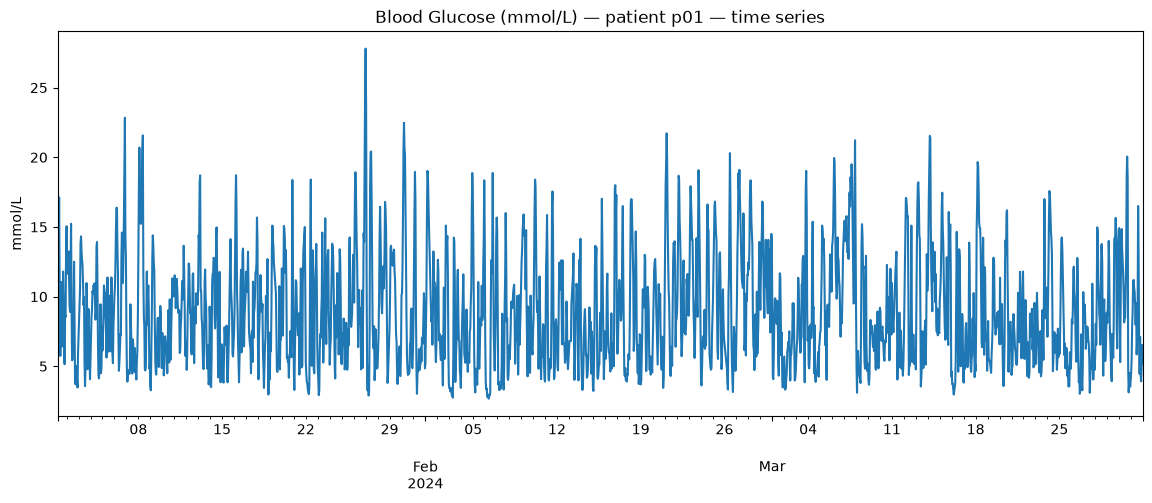

In [39]:
fig, ax = plt.subplots()
bg_hourly.plot(ax=ax, title=f"Blood Glucose (mmol/L) — patient {PATIENT} — time series")
ax.set_ylabel("mmol/L")
plt.show()

The series exhibits marked variability, characterized by physiological declines toward the hypoglycemic threshold (approximately 3 mmol/L) and prominent hyperglycemic excursions (frequently exceeding 15 mmol/L, with an isolated maximum peak approaching 28 mmol/L).

To resolve the visual anomaly introduced by the arbitrary calendar dates, I convert the horizontal axis into **"Monitoring Days"** elapsed since sensor activation:

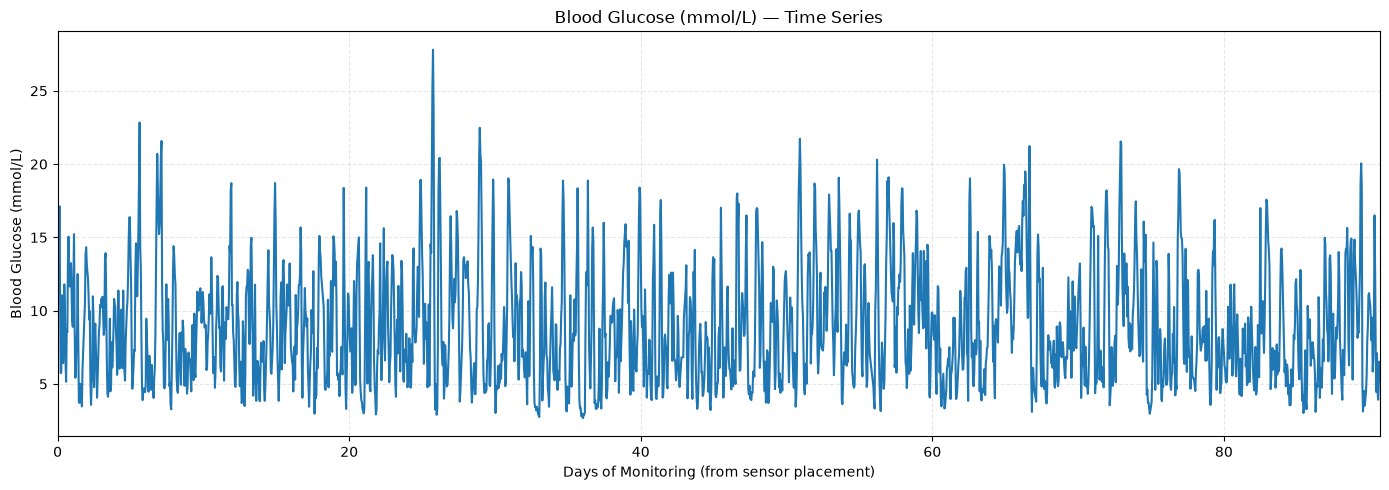

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))
# Calculating the elapsed time (in continuous days) from the initial measurement
giorni_trascorsi = (bg_hourly.index - bg_hourly.index.min()).total_seconds() / (24 * 3600)

ax.plot(giorni_trascorsi, bg_hourly.values, color='#1f77b4')

ax.set_title("Blood Glucose (mmol/L) — Time Series")
ax.set_xlabel("Days of Monitoring (from sensor placement)")
ax.set_ylabel("Blood Glucose (mmol/L)")

# Adding a grid to facilitate the interpretation of values
ax.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, giorni_trascorsi.max())
plt.tight_layout()
plt.show()

The subsequent step involved consulting clinical diabetes guidelines to evaluate whether the recorded measurements fell within the therapeutic target range and to define the clinical thresholds defining hypoglycemia and hyperglycemia:

ADA/ISPAD clinical guidelines define the standard target range as 3.9–10.0 mmol/L (70–180 mg/dL). In this plot:
- Minima around 3.0 mmol/L reach the Level 2 hypoglycemia threshold (acute clinical risk);
- The isolated peak at ~28 mmol/L around Day 25 represents an episode of severe Level 2 hyperglycemia, significantly above the target range.

In general, the standard Time in Range (TIR) targets for the majority of individuals with Type 1 or Type 2 diabetes are defined as follows:

| Category | mg/dL | mmol/L | Target |
|:---|---:|---:|:---|
| 🟢 Ideal Target Range (TIR) | 70–180 | **3.9–10.0** | **>70% of time (≥17 hours/day)** |
| 🔵 Hypoglycemia (TBR - Level 1) | <70 | **<3.9** | **<4% of time (<58 min/day)** |
| 🔴 Significant Hypoglycemia (TBR - Level 2) | <54 | **<3.0** | **<1% of time (<14 min/day)** |
| 🟠 Hyperglycemia (TAR - Level 1) | >180 | **>10.0** | **<25% of time (<6 hours/day)** |
| 🔴 Marked Hyperglycemia (TAR - Level 2) | >250 | **>13.9** | **<5% of time (<1 h 12 min/day)** |

> **Note:** Target objectives may be individualized by healthcare providers according to patient age, hypoglycemia awareness/risk, and other underlying clinical conditions.

In addition to standard descriptive statistics, I computed the **Time in Range (TIR)**—the percentage of time spent within the target glycemic range (3.9–10.0 mmol/L in accordance with ADA/ISPAD guidelines)—alongside the Time Below Range (TBR, indicating hypoglycemia risk) and Time Above Range (TAR, reflecting hyperglycemia). Today, TIR represents the gold standard clinical benchmark for assessing glycemic control in patients utilizing CGM devices.

In [41]:
# Definizione dei limiti clinici (in mmol/L)
limite_inf = 3.9
limite_sup = 10.0

# Removing NaN values to ensure the denominator accounts solely for valid observations
serie_valida = bg_interp.dropna()

# Constructing logical conditions (boolean masks)
in_range = (serie_valida >= limite_inf) & (serie_valida <= limite_sup)
below_range = serie_valida < limite_inf
above_range = serie_valida > limite_sup

# Computing the percentage using the .mean() method 
# (which casts True to 1 and False to 0, thereby returning the exact proportion)
tir_pct = in_range.mean() * 100
tbr_pct = below_range.mean() * 100
tar_pct = above_range.mean() * 100

# results printing
print("=== Blood Glucose Control Analysis ===")
print(f"Time in Range (3.9 - 10.0 mmol/L): {tir_pct:.1f}%")
print(f"Time Below Range (< 3.9 mmol/L):   {tbr_pct:.1f}%")
print(f"Time Above Range (> 10.0 mmol/L):  {tar_pct:.1f}%")

# Mathematical verification: the sum should equal 100%
somma_totale = tir_pct + tbr_pct + tar_pct
print(f"\nMathematical Verification (should be 100.0%): {somma_totale:.1f}%")

=== Blood Glucose Control Analysis ===
Time in Range (3.9 - 10.0 mmol/L): 58.5%
Time Below Range (< 3.9 mmol/L):   6.6%
Time Above Range (> 10.0 mmol/L):  34.8%

Mathematical Verification (should be 100.0%): 100.0%


After examining the overall trajectory of the data, a more granular exploration was required to investigate underlying diurnal patterns. Consequently, the horizontal axis was updated to display the specific hour of measurement rather than the cumulative monitoring day.

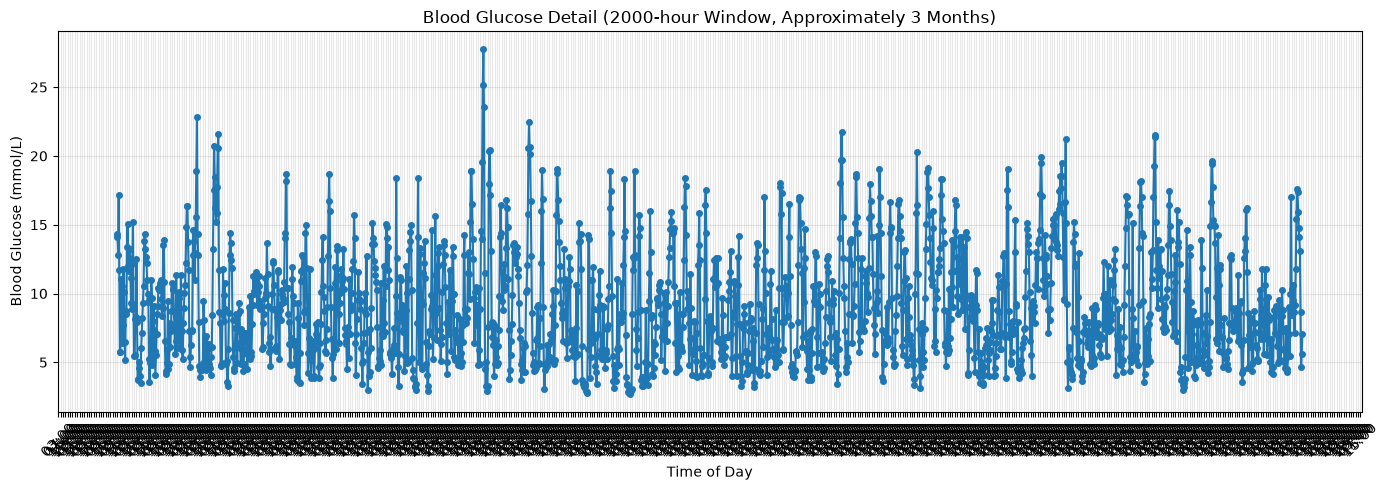

In [42]:
import matplotlib.dates as mdates
# Extracting a reduced segment, such as the initial 72 hours of recording
campione_breve = bg_hourly.iloc[:2000] 

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(campione_breve.index, campione_breve.values, marker='o', markersize=4)

# Configuring matplotlib to display exclusively hours and minutes
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Setting a tick exactly every 4 hours for a clear clinical reading
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))

ax.set_title("Blood Glucose Detail (2000-hour Window, Approximately 3 Months)")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Blood Glucose (mmol/L)")

ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Due to the clutter and poor interpretability of the horizontal axis labels over extended recording periods, I transitioned to a box plot visualization, specifically an Aggregated Daily Profile (Daily Profile):

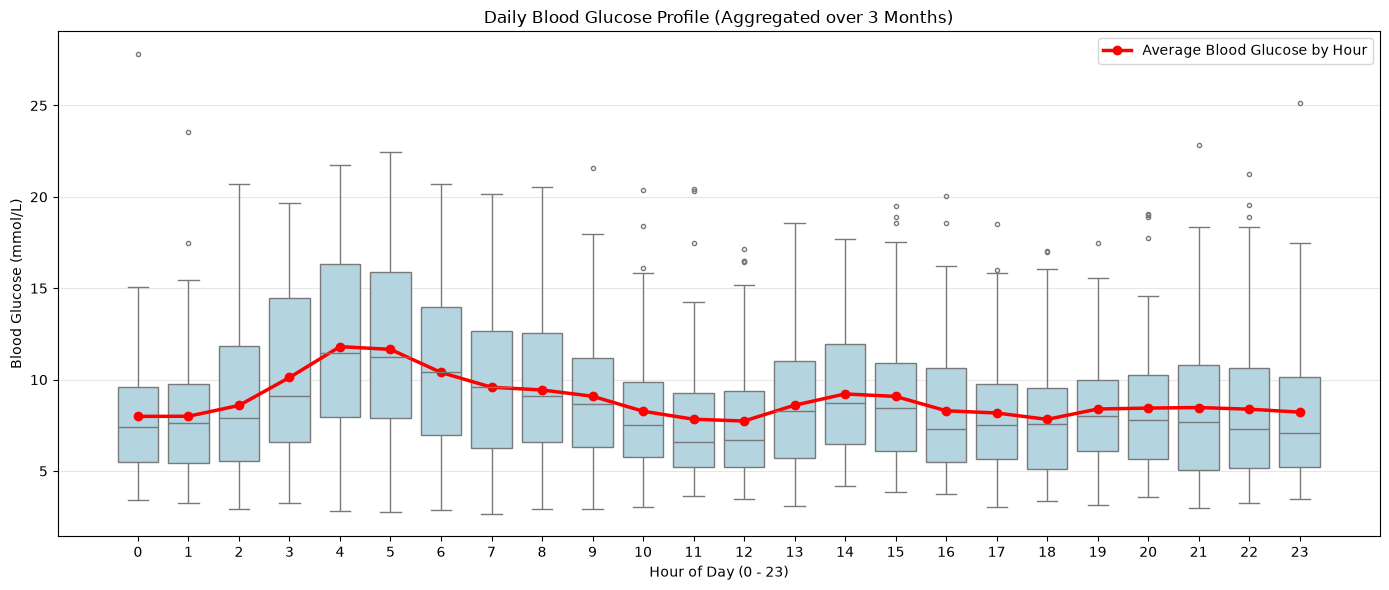

In [43]:
# Data preparation: extracting the hour component from the index
df_analisi_oraria = bg_hourly.to_frame(name='bg')
df_analisi_oraria['Hour_of_Day'] = df_analisi_oraria.index.hour

fig, ax = plt.subplots(figsize=(14, 6))

# Constructing the box plot: distribution of values across each individual hour
sns.boxplot(
    x='Hour_of_Day', 
    y='bg', 
    data=df_analisi_oraria, 
    ax=ax, 
    color='lightblue',
    fliersize=3 # Marker size for outliers (anomalous points)
)

# Computing and overlaying the mean trend
medie_orarie = df_analisi_oraria.groupby('Hour_of_Day')['bg'].mean()
ax.plot(
    medie_orarie.index, 
    medie_orarie.values, 
    color='red', 
    linewidth=2.5, 
    marker='o', 
    label='Average Blood Glucose by Hour'
)


ax.set_title("Daily Blood Glucose Profile (Aggregated over 3 Months)")
ax.set_xlabel("Hour of Day (0 - 23)")
ax.set_ylabel("Blood Glucose (mmol/L)")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Aggregating the data by hour of day (hourly box plot) reveals a distinct circadian pattern, characterized by a pronounced increase during the early morning hours consistent with the **dawn phenomenon**—a physiological mechanism well-documented in diabetes literature, driven by the release of counter-regulatory hormones (such as cortisol and growth hormone) that stimulate hepatic glucose production independently of food intake.

## 5. Time Series Decomposition: Trend, Seasonality, and Residuals
### Fundamentals and Rationale for STL Decomposition

STL (**Seasonal-Trend decomposition using Loess**) decomposes a time series into the additive sum of three components: $y_t = \text{Trend}_t + \text{Seasonal}_t + \text{Residual}_t$. Unlike classical additive decomposition, which assumes a static and invariant seasonal pattern across the entire observation window, STL utilizes locally estimated scatterplot smoothing (Loess) for both the trend and seasonal components. This allows the seasonal component to **evolve in amplitude over time**. This characteristic is particularly well-suited for physiological signals such as blood glucose, where the magnitude of diurnal fluctuations (primarily driven by dietary intake) is non-stationary and varies according to behavioral and metabolic dynamics.

I configured `period=24` (hours), in alignment with the underlying circadian rhythm hypothesis, and specified `robust=True` to mitigate the influence of outliers—a frequent characteristic in this domain resulting from acute hyper- and hypoglycemic events.

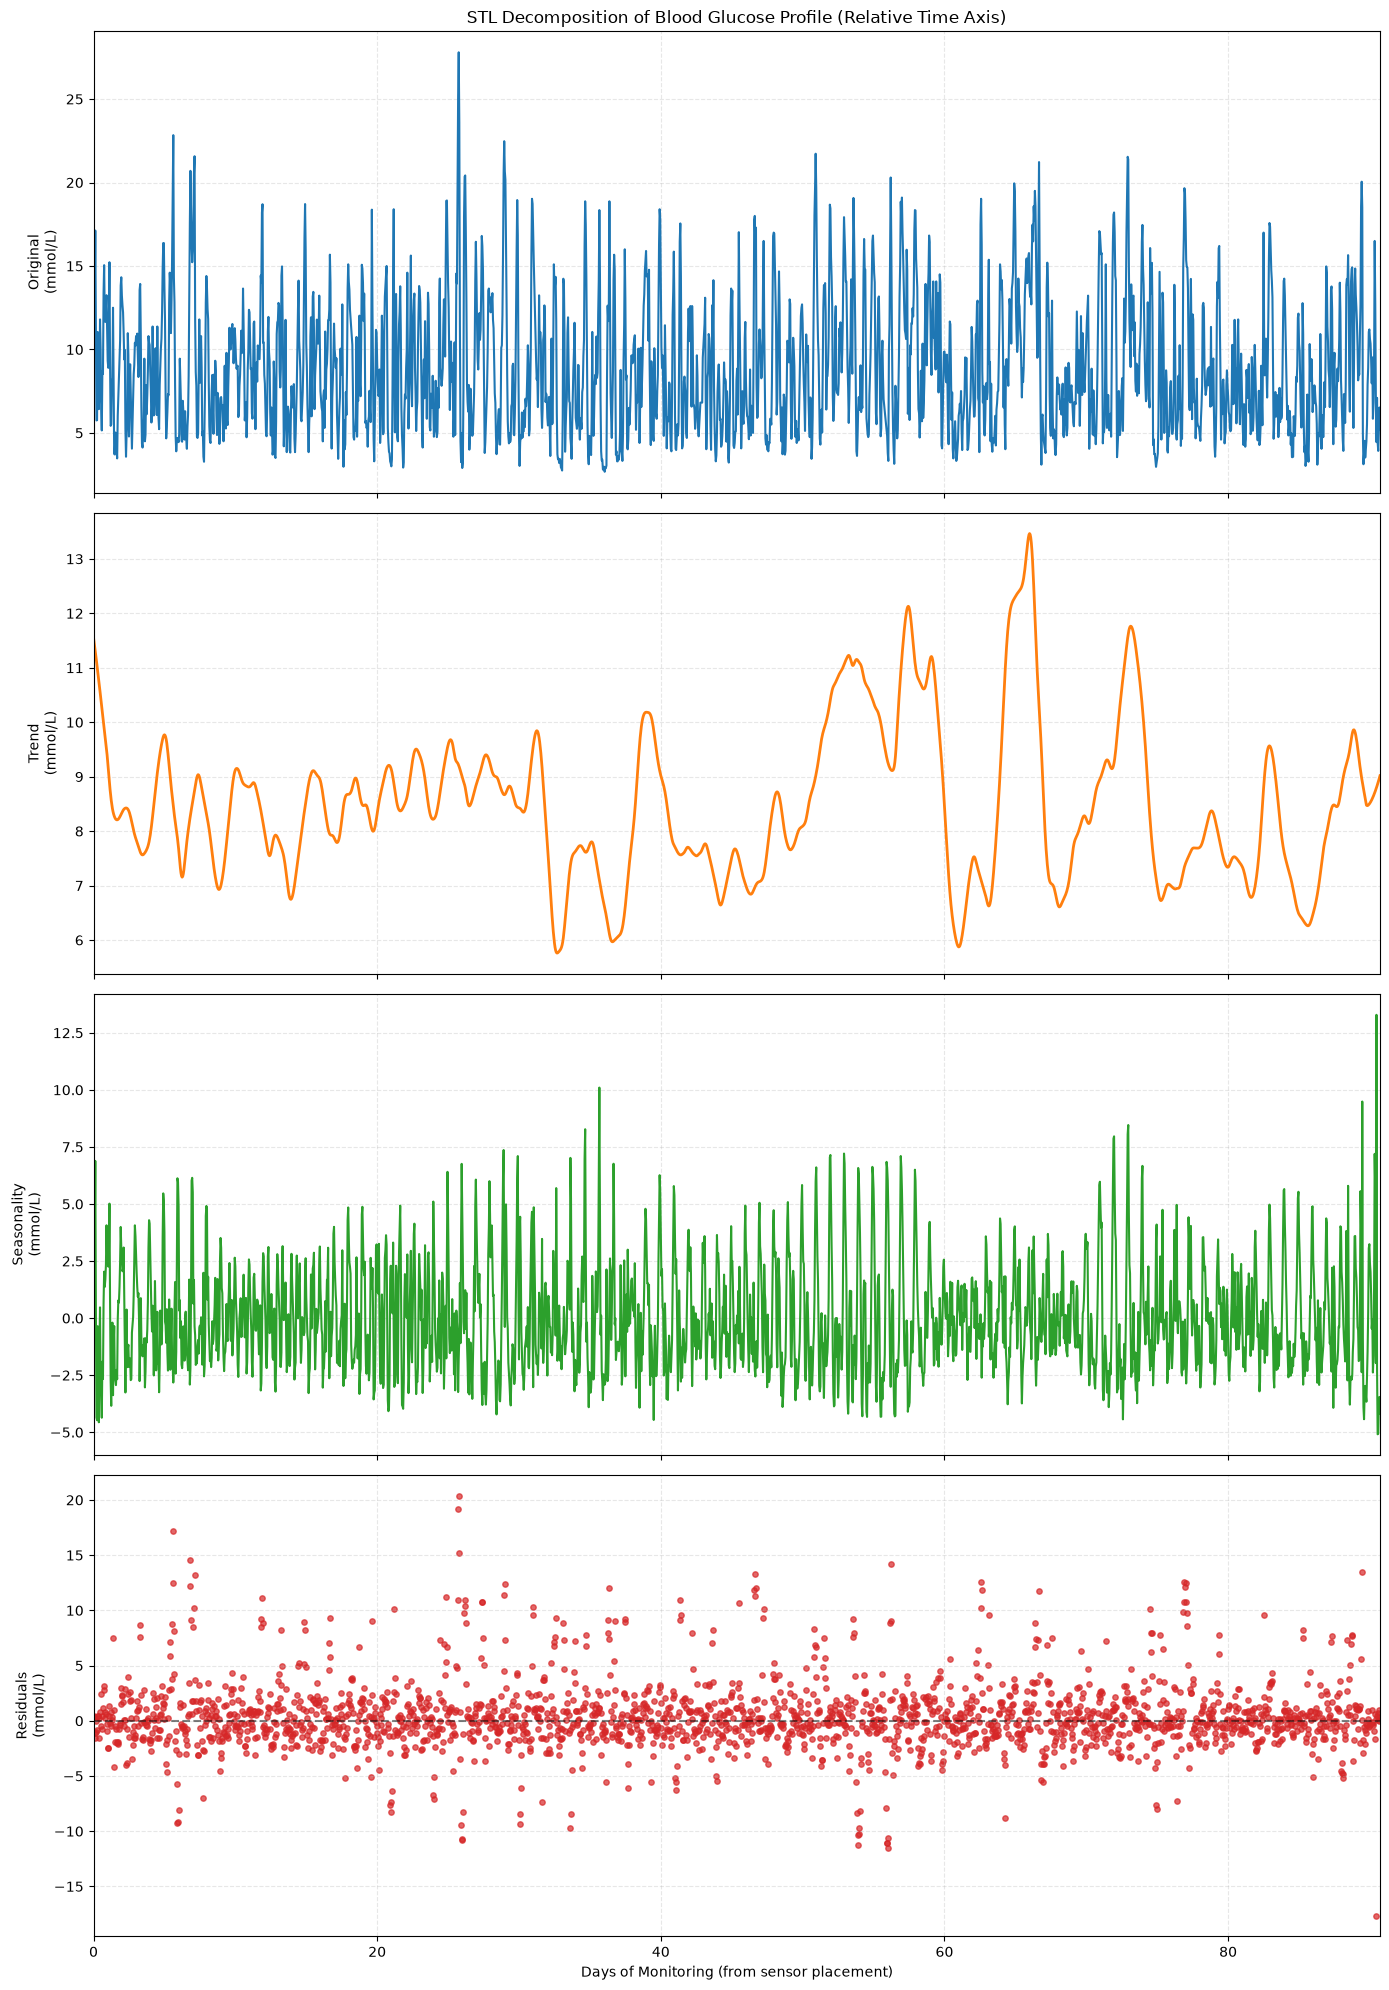

In [44]:
# 1. Performing STL decomposition
# Specifying period=24 (for hourly observations) and robust=True to mitigate the influence of anomalous spikes
stl = STL(bg_hourly, period=24, robust=True)
res = stl.fit()

# 2. Computing the relative time axis (days elapsed since the onset of monitoring)
giorni_trascorsi = (bg_hourly.index - bg_hourly.index.min()).total_seconds() / (24 * 3600)


fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=True)

# A. Original Series
axes[0].plot(giorni_trascorsi, res.observed, color='#1f77b4')
axes[0].set_ylabel('Original\n(mmol/L)')
axes[0].set_title('STL Decomposition of Blood Glucose Profile (Relative Time Axis)')

# B. Trend
axes[1].plot(giorni_trascorsi, res.trend, color='#ff7f0e', linewidth=2)
axes[1].set_ylabel('Trend\n(mmol/L)')

# C. Seasonality
axes[2].plot(giorni_trascorsi, res.seasonal, color='#2ca02c')
axes[2].set_ylabel('Seasonality\n(mmol/L)')

# D. Residuals
axes[3].scatter(giorni_trascorsi, res.resid, color='#d62728', marker='o', s=15, alpha=0.7)
# Adding a horizontal line at zero to visually assess the distribution of residuals
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_ylabel('Residuals\n(mmol/L)')
axes[3].set_xlabel('Days of Monitoring (from sensor placement)')

# Formatting using elapsed days rather than arbitrary calendar dates
for ax in axes:
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, giorni_trascorsi.max())

plt.tight_layout()

### Interpretation of Results

- **Trend**: Displays non-negligible multi-day oscillations (ranging from 6.0 to 13.5 mmol/L), exhibiting broader variations than would typically be expected from a baseline underlying trend. This pattern suggests the potential presence of unmodeled higher-order seasonalities (such as weekly cycles driven by behavioral alterations over weekends) that were not captured by a single 24-hour seasonal component.
- **Seasonality**: Confirms the presence of a true circadian rhythm with time-varying amplitude. Certain intervals demonstrate substantially more pronounced diurnal excursions than others, likely reflecting variations in dietary intake, meal composition, or less precise insulin dosing regimens during those specific monitoring windows.
- **Residuals**: Centered around zero and devoid of an obvious systematic structure, yet characterized by substantial magnitude (reaching up to ±20 mmol/L at specific points). This indicates that a significant portion of glycemic variability is not explained by diurnal periodicity alone, but is predominantly driven by exogenous clinical events (e.g., carbohydrate consumption, prandial insulin boluses, physical exercise, acute stress) that univariate time series models cannot inherently account for.

### Hourly Box Plot of STL Components

Aggregating the trend and seasonal components by hour of the day yielded dual verification: the seasonal component demonstrates the anticipated circadian profile (a morning peak consistent with the dawn phenomenon), whereas the trend component remains **virtually invariant** across all 24 hours. This confirms that the decomposition successfully disentangled the low-frequency baseline dynamics (trend) from the circadian periodicity (seasonality); had seasonal leakage into the trend occurred, systematic hourly disparities within the trend component would be observed.

In [45]:
# Consolidating the decomposition results into a DataFrame
df_stl = pd.DataFrame({
    'Osservato': res.observed,
    'Trend': res.trend,
    'Stagionalità': res.seasonal,
    'Residui': res.resid,
    'Ora': res.resid.index.hour,
    'Giorno_Relativo': (res.resid.index - res.resid.index.min()).days
})

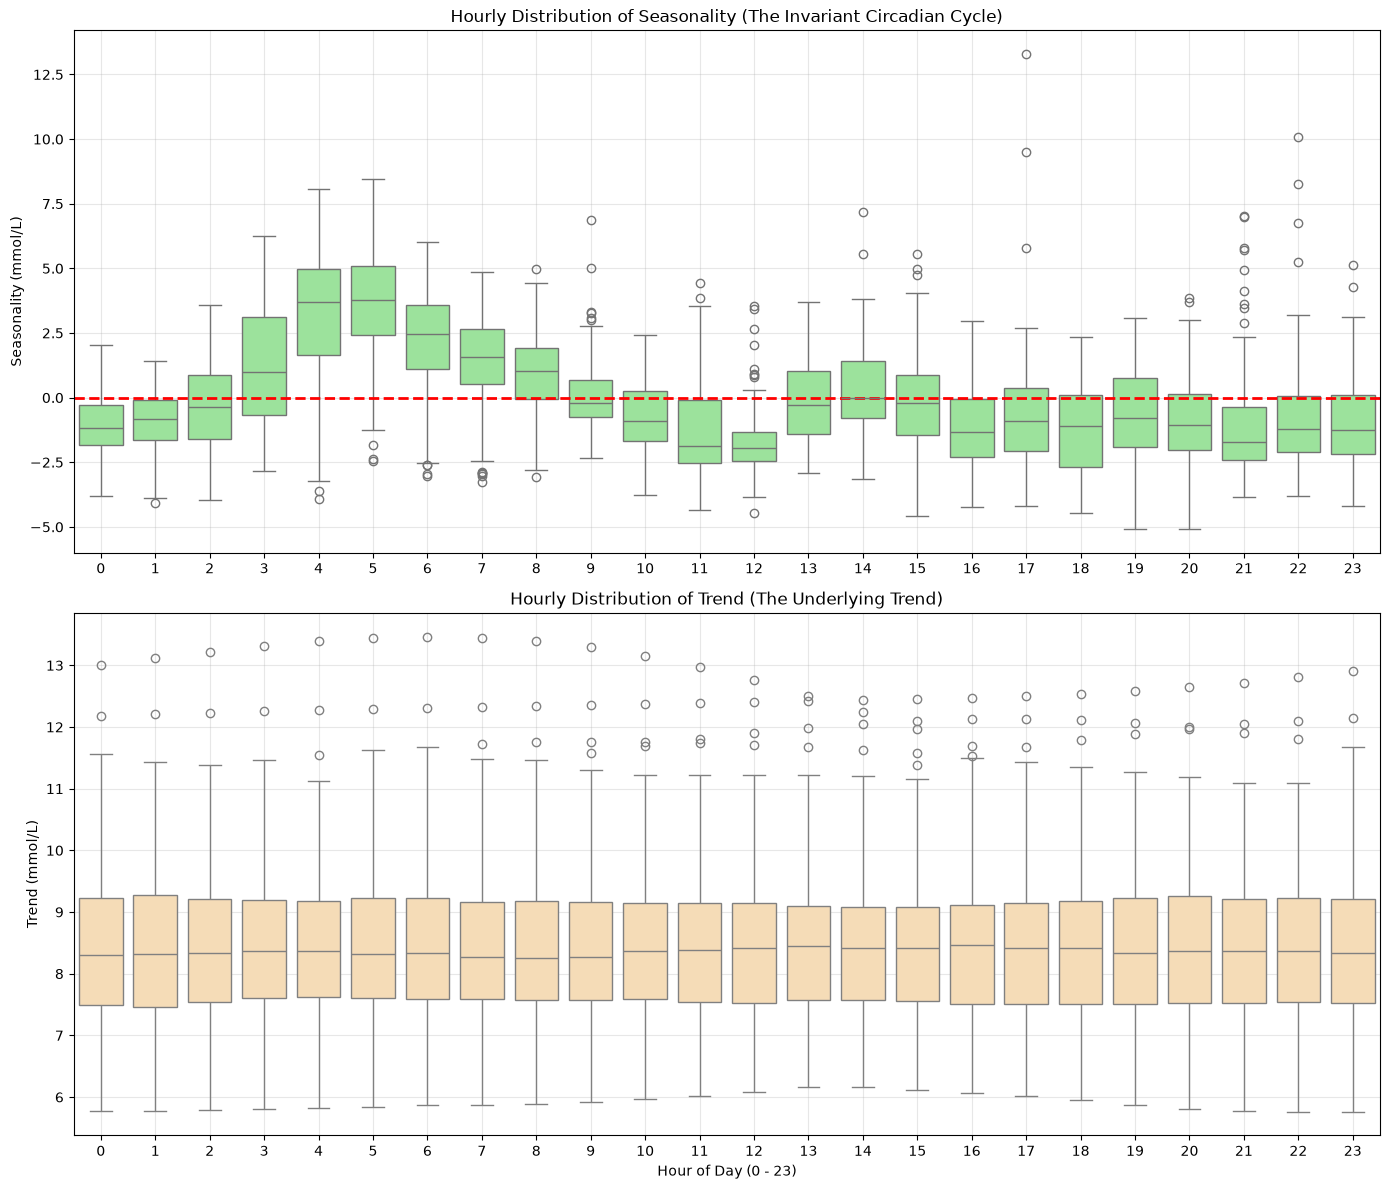

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Hourly Box Plot of SEASONALITY
sns.boxplot(
    x='Ora', 
    y='Stagionalità', #seasonality
    data=df_stl, 
    ax=axes[0], 
    color='lightgreen'
)
axes[0].set_title("Hourly Distribution of Seasonality (The Invariant Circadian Cycle)")
axes[0].set_ylabel("Seasonality (mmol/L)")
axes[0].set_xlabel("") # Suppressing the x-axis label to maintain visual clarity
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='red', linewidth=2, linestyle='--')
# 2. Hourly Box Plot of TREND
sns.boxplot(
    x='Ora', 
    y='Trend', 
    data=df_stl, 
    ax=axes[1], 
    color='navajowhite'
)
axes[1].set_title("Hourly Distribution of Trend (The Underlying Trend)")
axes[1].set_xlabel("Hour of Day (0 - 23)")
axes[1].set_ylabel("Trend (mmol/L)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

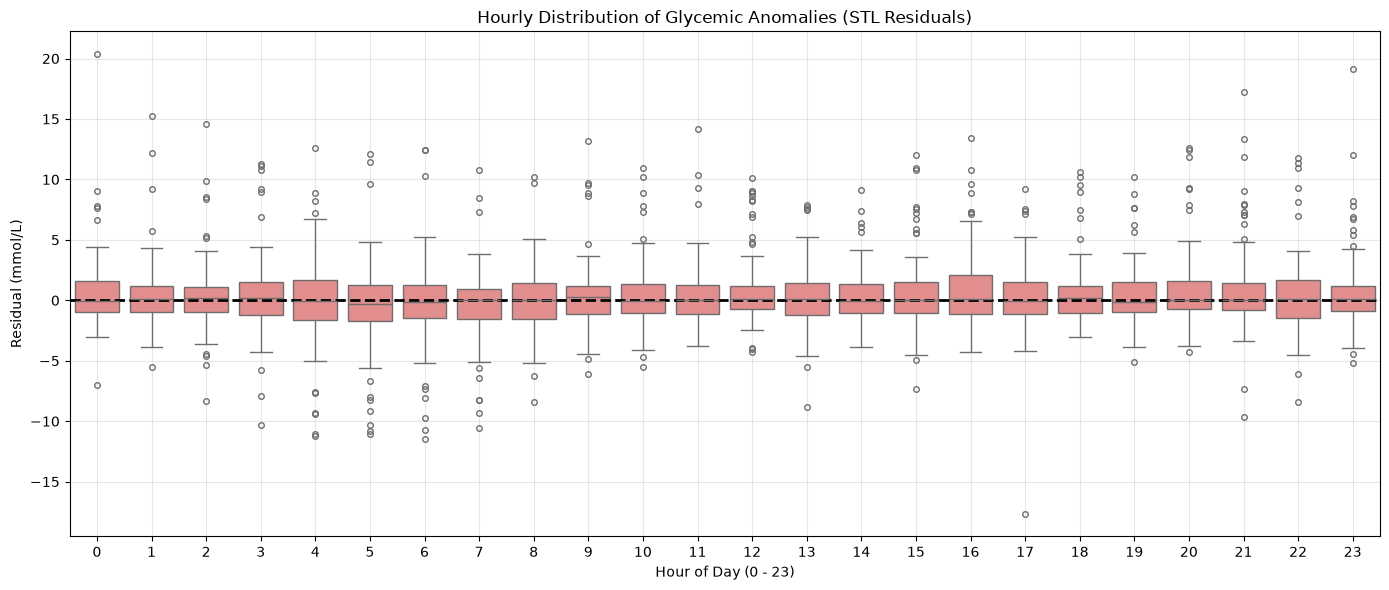

In [48]:
# residuals box-plot 
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    x='Ora', 
    y='Residui', #residuals
    data=df_stl, 
    ax=ax, 
    color='lightcoral',
    fliersize=4
)


ax.axhline(0, color='black', linewidth=2, linestyle='--')

ax.set_title("Hourly Distribution of Glycemic Anomalies (STL Residuals)")
ax.set_xlabel("Hour of Day (0 - 23)")
ax.set_ylabel("Residual (mmol/L)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Stationarity Assessment
ARIMA models operate under the foundational assumption that the analyzed time series (following any necessary differencing) is weakly stationary—meaning its statistical properties (mean, variance, and autocovariance) remain invariant over time. To rigorously evaluate stationarity, I implemented two complementary statistical tests with opposing null hypotheses:

- **Augmented Dickey-Fuller (ADF) Test**: Null hypothesis ($H_0$) = The series contains a unit root (is non-stationary). A sufficiently low $p$-value ($p < \alpha$) leads to the rejection of $H_0$, supporting stationarity (difference-stationarity).
- **Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test**: Complementary null hypothesis ($H_0$) = The series is level- or trend-stationary. A low $p$-value leads to the rejection of $H_0$, confirming non-stationarity.

Employing both tests concurrently allows for distinguishing between distinct mechanisms of non-stationarity (e.g., stochastic drift from a unit root versus a deterministic trend), preventing misclassifications that a single diagnostic test might introduce.

In [49]:
def adf_report(x, label):
    # ADF null hypothesis (H0): The series contains a unit root (non-stationary).
    # Low p-value (p < alpha) -> reject H0 -> indicates stationarity
    stat, pval, *_ = adfuller(x.dropna())
    print(f"[ADF]  {label}: statistic={stat:.3f}  p-value={pval:.4f}  "
          f"-> {'stationary' if pval < 0.05 else 'NON stationary'} (alpha=0.05)")

def kpss_report(x, label):
    # KPSS null hypothesis (H0): The series is stationary (complementary hypothesis to ADF for triangulation).
# Low p-value (p < alpha) -> reject H0 -> indicates non-stationarity
    stat, pval, *_ = kpss(x.dropna(), regression="c", nlags="auto")
    print(f"[KPSS] {label}: statistic={stat:.3f}  p-value={pval:.4f}  "
          f"-> {'stationary' if pval > 0.05 else 'NON stationary'} (alpha=0.05)")

print("=== LEVEL (Original Series) ===")
adf_report(bg_hourly, "level")
kpss_report(bg_hourly, "level")


# Proactively computed in the event that the series exhibits non-stationarity, thereby inducing stationarity and ensuring more accurate forecasting
bg_diff = bg_hourly.diff().dropna()
print("\n=== NON-SEASONAL DIFFERENCE (d=1) ===")
adf_report(bg_diff, "non-seasonal difference (d=1)")
kpss_report(bg_diff, "non-seasonal difference (d=1)")

=== LEVEL (Original Series) ===
[ADF]  level: statistic=-18.861  p-value=0.0000  -> stationary (alpha=0.05)
[KPSS] level: statistic=0.095  p-value=0.1000  -> stationary (alpha=0.05)

=== NON-SEASONAL DIFFERENCE (d=1) ===
[ADF]  non-seasonal difference (d=1): statistic=-15.582  p-value=0.0000  -> stationary (alpha=0.05)
[KPSS] non-seasonal difference (d=1): statistic=0.030  p-value=0.1000  -> stationary (alpha=0.05)


Both the ADF and KPSS tests concur in indicating that the level series is **already stationary** (ADF: $p < 0.0001$; KPSS: $p = 0.10$, failing to reject $H_0$). This statistical outcome has a direct physiological foundation: glycemic regulation is an inherently **homeostatic** process—the endocrine system actively modulates glucose dynamics via counter-regulatory hormonal mechanisms to preserve equilibrium within a physiological target range. Consequently, the series exhibits **mean-reverting** properties, fluctuating around a central tendency rather than diverging stochastically as a pure random walk would (the characteristic behavior of a unit-root non-stationary process). Accordingly, the non-seasonal order of integration is established as $d = 0$ (`d=0`).

## 7. Autocorrelation Analysis (ACF / PACF)
The **ACF** (Autocorrelation Function) measures the total correlation (encompassing both direct and indirect dependencies) between a time series and its lagged values across various time displacements (lags). Conversely, the **PACF** (Partial Autocorrelation Function) isolates and quantifies the direct correlation between the series and a specific lag, controlling for the intervening effects of all intermediate lags. The joint diagnostic evaluation of these two functions constitutes the classical empirical framework for identifying the orders of an $\text{ARMA}(p, q)$ model:

- A PACF that **cuts off sharply** after lag $p$, accompanied by an ACF that decays gradually (exponentially or sinusoidally), is the characteristic signature of an **autoregressive process, $\text{AR}(p)$**.
- An ACF that **cuts off sharply** after lag $q$, accompanied by a PACF that decays gradually, is the characteristic signature of a **moving average process, $\text{MA}(q)$**.

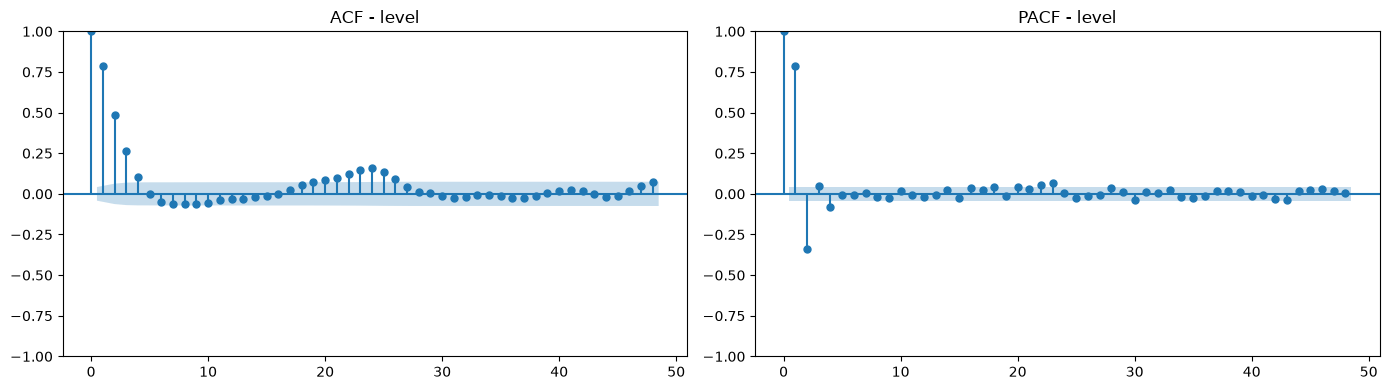

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(bg_hourly, lags=48, ax=axes[0])
plot_pacf(bg_hourly, lags=48, ax=axes[1], method="ywm")
axes[0].set_title("ACF - level")
axes[1].set_title("PACF - level")
plt.tight_layout()
plt.show()

On the level series, the PACF exhibits a sharp cutoff after the second lag, whereas the ACF decays gradually—the canonical signature of an **AR(2)** process.

At this stage of the project, I am considering a SARIMA(2,0,0) model.

The ACF plot displays a discernible peak at lag 24, providing preliminary empirical confirmation of the hypothesized seasonality.

## 8. Temporal Data Partitioning and Baseline Models
In time-series analysis, applying a random partition (or conventional $k$-fold cross-validation) introduces **temporal data leakage**: the model may leverage future information to predict past states, yielding deceptively optimistic performance estimates. Therefore, the final hours of the series are designated as a **validation set**, strictly sequestered during model parameter estimation to faithfully simulate a realistic out-of-sample forecasting scenario on unobserved future observations.

In [51]:
# Designating the final 7 days (168 hours) as the validation set
validation_hours = 24 * 7
train = bg_hourly.iloc[:-validation_hours]
validation = bg_hourly.iloc[-validation_hours:]


Prior to proceeding, I deemed it necessary to evaluate the necessity of incorporating seasonality into the model by fitting a baseline $\text{ARIMA}(2,0,0)$ specification (using the orders identified in the preceding analysis):

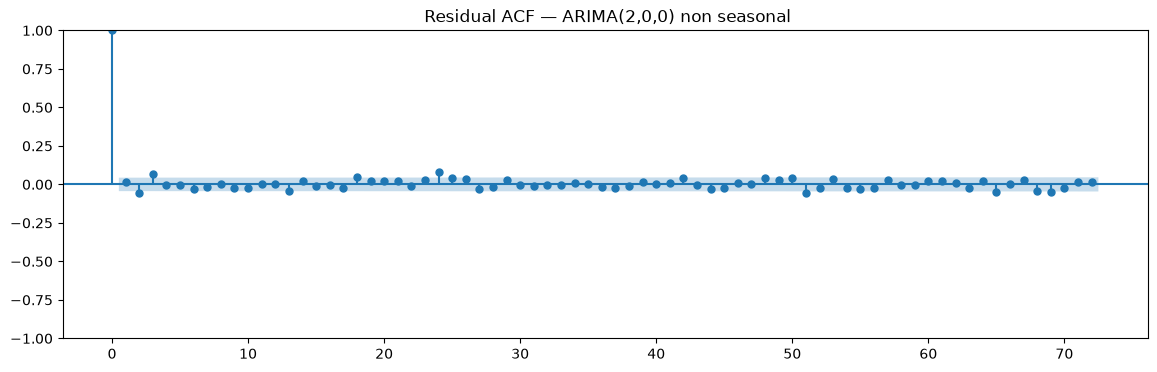

      lb_stat  lb_pvalue
24  47.087831   0.003268
48  69.922478   0.021080


In [52]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

arima_naive = ARIMA(train, order=(2,0,0)).fit()
resid = arima_naive.resid

fig, ax = plt.subplots(figsize=(14,4))
plot_acf(resid, lags=72, ax=ax)
ax.set_title(" Residual ACF — ARIMA(2,0,0) non seasonal")
plt.show()

lb = acorr_ljungbox(resid, lags=[24, 48], return_df=True)
print(lb)

The quantitative results corroborate the visual diagnostics. With $p$-values of 0.0032 at lag 24 and 0.0210 at lag 48, the statistics fall well below the nominal significance threshold of $\alpha = 0.05$. 

This necessitates the rejection of the null hypothesis ($H_0$): the residuals from the current model specification are not independent and retain a highly predictable pattern, thereby rejecting the white noise hypothesis.

Furthermore, the residual correlogram demonstrates that the vast majority of autocorrelations fall comfortably within the significance bounds, closely approximating white noise behavior.

However, a prominent and statistically significant spike emerges precisely at lag 24 (exceeding the critical confidence thresholds). This serves as clear graphical evidence that the circadian rhythm was not adequately captured by the model.

The standard non-seasonal $\text{ARIMA}(2,0,0)$ architecture proves inadequate: it lacks the mathematical formulation required to account for the complete 24-hour metabolic cycle.

Consequently, incorporating a seasonal component into the model specification is essential.

### Naive Baseline Models

Prior to introducing more sophisticated specifications, I established two baseline benchmarks to evaluate whether the added model complexity is justified (serving as reference standards against which subsequent models are assessed):

- **Naive Persistence**: Projects that the value at the next time step will equal the currently observed value ($\hat{y}_{t+1} = y_t$). This serves as an essential benchmark given the pronounced short-term autocorrelation inherent to glycemic dynamics.
- **Seasonal Naive**: Projects that the value at the next time step will equal the observation recorded exactly 24 hours prior ($\hat{y}_{t+1} = y_{t+1-24}$). This benchmark isolates and quantifies the empirical predictive value added by the previously demonstrated circadian seasonality.

In [53]:
# Establishing a baseline benchmark against which subsequent candidate models will be evaluated
# Baseline 1: Naive persistence — "the value in 1 hour equals the current observation"
# Relevant benchmark given the strong short-term autocorrelation exhibited by glycemic dynamics (as evidenced in ACF/PACF diagnostics)
naive_persistence_pred = pd.concat([train, validation]).shift(1).loc[validation.index]

# Baseline 2: Naive seasonal — "the value in 1 hour equals the value 24 hours ago at the same time"
# Useful because I have demonstrated the dawn phenomenon / circadian seasonality
naive_seasonal_pred = pd.concat([train, validation]).shift(24).loc[validation.index]

def compute_metrics(y_true, y_pred, label):
    mask = y_true.notna() & y_pred.notna()
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    print(f"{label:20s} | MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")
    return {"model": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []
results.append(compute_metrics(validation, naive_persistence_pred, "Naive (persistence, lag 1h)"))
results.append(compute_metrics(validation, naive_seasonal_pred, "Naive (seasonal, lag 24h)"))

Naive (persistence, lag 1h) | MAE=1.892  RMSE=2.604  MAPE=25.49%
Naive (seasonal, lag 24h) | MAE=3.289  RMSE=4.297  MAPE=45.28%


## 9. SARIMA Modeling
The SARIMA (**Seasonal AutoRegressive Integrated Moving Average**) model extends the classical ARIMA framework by explicitly incorporating a seasonal structure. It is formally denoted as **$\text{SARIMA}(p, d, q)(P, D, Q)_m$**, where:

- **$p, d, q$**: Represent the non-seasonal autoregressive order (dependence on recent historical values), the non-seasonal order of integration (differencing applied to induce stationarity), and the moving average order (dependence on past forecast errors/innovations), respectively.
- **$P, D, Q$**: Represent the corresponding seasonal autoregressive, seasonal integration (differencing), and seasonal moving average orders, operating across lags that are integer multiples of the seasonal period $m$.
- **$m$**: The seasonal periodicity (in this study, $m = 24$, capturing the complete circadian cycle).

Conceptually, the model generates forecasts as a linear combination of: (a) recent past observations (non-seasonal AR component), (b) historical observations recorded at the corresponding phase of the seasonal cycle (seasonal AR component), and (c) past forecast errors (non-seasonal and seasonal MA components). It is a **linear parametric model** typically estimated via Maximum Likelihood Estimation (MLE), requiring the series (post-differencing, if applicable) to be weakly stationary—thereby substantiating the rigorous diagnostic and stationarity analyses conducted in the preceding sections.

### Model Order Identification
While the non-seasonal orders were established in the preceding section, this section focuses on identifying the seasonal components.

The analysis began with an inspection of the ACF and PACF at integer multiples of lag 24 ($k \times 24$, for $k = 1, 2, \dots$):

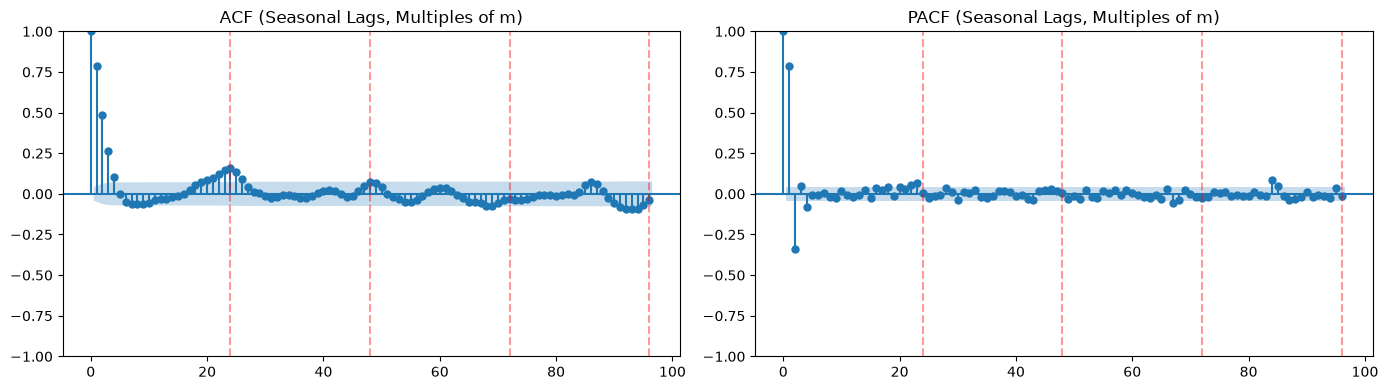

In [54]:
# Inspecting ACF and PACF at seasonal lags (integer multiples of m) to identify seasonal orders P and Q
m=24
seasonal_lags = 4  # Analyzing lags up to 4 * m (e.g., spanning 4 days of historical observations for m = 24)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(bg_hourly, lags=seasonal_lags * m, ax=axes[0])
plot_pacf(bg_hourly, lags=seasonal_lags * m, ax=axes[1], method="ywm")
axes[0].set_title("ACF (Seasonal Lags, Multiples of m)")
axes[1].set_title("PACF (Seasonal Lags, Multiples of m)")
for ax in axes:
    for k in range(1, seasonal_lags + 1):
        ax.axvline(k * m, color="red", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Analytical attention must be focused exclusively on the behavior observed at the seasonal multiples (indicated by the red dashed lines at lags 24, 48, and 72):

- **Seasonal PACF**: Absence of prominent spikes at lags 24, 48, or 72 $\rightarrow$ suggests a seasonal autoregressive order of $P = 0$.
- **Seasonal ACF**: A modest yet discernible elevation around lag 24 (attenuating progressively across lags 48 and 72) $\rightarrow$ suggests a potential seasonal moving average order of $Q = 1$ (representing a weak seasonal MA component).

Inspection of the seasonal ACF reveals a single prominent spike at lag 24 that decays across subsequent multiples; a true seasonal unit root would instead manifest as persistently elevated, non-decaying autocorrelations at successive seasonal lags.

The observed decay pattern is empirically consistent with a seasonal integration order of $D = 0$. To formally corroborate this diagnostic inference, I performed the **OCSB (Osborn-Chui-Smith-Birchenhall) test**. Standard ADF and KPSS tests are inadequate for assessing seasonal integration because they are formulated specifically for zero-frequency (non-seasonal) unit roots, whereas the OCSB test is explicitly designed to evaluate the necessity of seasonal differencing. Additionally, the **Canova-Hansen (CH) test** was conducted as a complementary robustness check.

In [55]:
# Osborn-Chui-Smith-Birchenhall (OCSB) test — formulated specifically
# to determine whether seasonal differencing is required
D_ocsb = pm.arima.nsdiffs(bg_hourly, m=24, test="ocsb", max_D=2)
print(f"D suggested by OCSB: {D_ocsb}")

# Alternative test: Canova-Hansen (often more conservative than OCSB)
D_ch = pm.arima.nsdiffs(bg_hourly, m=24, test="ch", max_D=2)
print(f"D suggested by Canova-Hansen: {D_ch}")

D suggested by OCSB: 0
D suggested by Canova-Hansen: 0


Both statistical tests concur on $D = 0$: seasonality is present but stationary, indicating that it can be adequately captured via the model's seasonal AR/MA components rather than necessitating seasonal differencing.

I utilized `pmdarima.auto_arima` to conduct a stepwise automated search guided by the Akaike Information Criterion (AIC), constrained within the plausible parameter bounds identified during the manual diagnostic phase.

In [56]:
auto_model = pm.auto_arima(
    train, seasonal=True, m=24,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    d=None, D=None, trace=True,
    error_action="ignore", suppress_warnings=True, stepwise=True,
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=11264.756, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=9297.529, Time=1.75 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=9704.890, Time=1.39 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=14879.294, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=9312.070, Time=0.06 sec
 ARIMA(1,0,0)(2,0,0)[24] intercept   : AIC=9293.291, Time=9.37 sec
 ARIMA(1,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=40.49 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=8.50 sec
 ARIMA(0,0,0)(2,0,0)[24] intercept   : AIC=11220.950, Time=8.70 sec
 ARIMA(2,0,0)(2,0,0)[24] intercept   : AIC=9062.031, Time=11.60 sec
 ARIMA(2,0,0)(1,0,0)[24] intercept   : AIC=9062.413, Time=2.08 sec
 ARIMA(2,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=31.81 sec
 ARIMA(2,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=5.89 sec
 ARIMA(3,0,0)(2,0,0)[24] intercept   : AIC=9060.808, Time=12.36 sec
 ARIMA(3,0,0)(1,0,0)[24] interce

The automatically selected minimum-AIC model, $\text{SARIMA}(2,0,3)(1,0,1)_{24}$, exhibits a statistically non-significant $\text{MA}(3)$ coefficient ($p = 0.195$)—a clear indicator of potential overparameterization. Upon evaluating information criteria against a more parsimonious alternative, the $\text{SARIMA}(2,0,2)(1,0,1)_{24}$ specification yields an even lower (superior) AIC value:

In [57]:
# Alternative model more parsimonious, forcing q=2 instead of letting it free up to 3
model_q2 = pm.ARIMA(order=(2,0,2), seasonal_order=(1,0,1,24), suppress_warnings=True).fit(train)
print(f"AIC model (2,0,2)(1,0,1): {model_q2.aic():.3f}")
print(f"AIC model (2,0,3)(1,0,1): {auto_model.aic():.3f}")

AIC model (2,0,2)(1,0,1): 9037.963
AIC model (2,0,3)(1,0,1): 9043.080


Given that the $\text{SARIMA}(2,0,2)(1,0,1)_{24}$ specification yielded a lower AIC value, I selected this configuration and fitted the model:

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood               -4510.982
Date:                              Tue, 01 Sep 2026   AIC                           9037.963
Time:                                      20:53:38   BIC                           9082.810
Sample:                                  01-01-2024   HQIC                          9054.426
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1196      0.087      1.379      0.168      -0.050       0.290
ar.L1          0.78

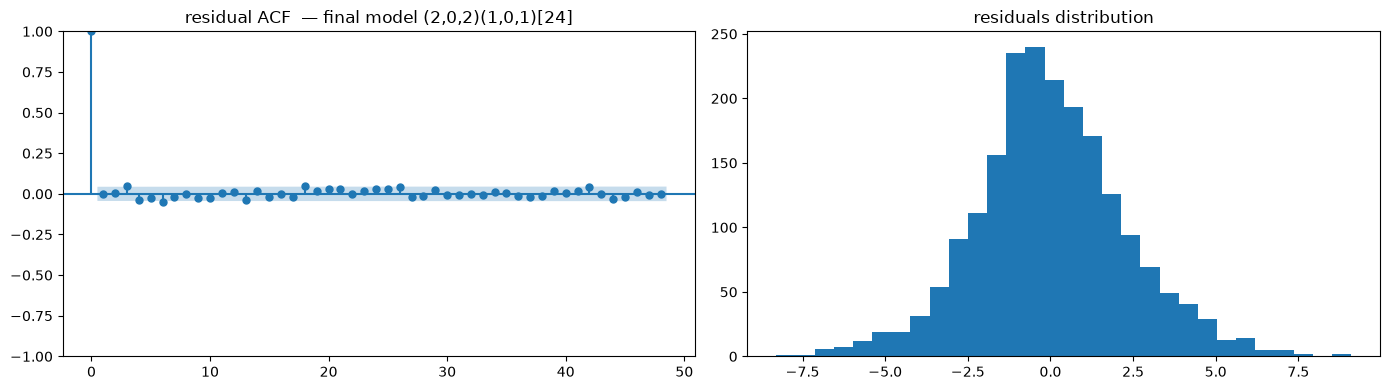

In [58]:
final_model = model_q2  # ARIMA(2,0,2)(1,0,1)[24]
print(final_model.summary())


residuals = final_model.resid()
lb_test = acorr_ljungbox(residuals, lags=[24, 48], return_df=True)
print(lb_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=48, ax=axes[0])
axes[0].set_title("residual ACF  — final model (2,0,2)(1,0,1)[24]")
axes[1].hist(residuals, bins=30)
axes[1].set_title("residuals distribution")
plt.tight_layout()
plt.show()

The Ljung-Box test on the residuals of the final model fails to reject the null hypothesis of no residual autocorrelation across both short-term and seasonal lags, indicating that the specification has adequately captured the predictable temporal structure inherent to the series.

Inspection of the residual ACF reveals that no individual autocorrelation coefficient breaches the critical significance thresholds. The absence of statistically significant autocorrelation across both short lags and seasonal multiples (lags 24 and 48) confirms that the model has successfully absorbed the systematically predictable temporal dynamics present in the data, validating the SARIMA identification.

Regarding the residual distribution, the empirical distribution closely approximates a normal distribution, albeit with slight tail asymmetry and isolated outliers located in the extreme tails. These correspond to the severe hyper- and hypoglycemic excursions identified in the initial STL decomposition, which the model cannot anticipate with precision due to exogenous factors (such as meal consumption and bolus insulin administrations) unobserved by a univariate SARIMA framework.

Consequently, the empirical prediction intervals will exhibit reduced reliability in the distributional tails, meaning the model tends to underestimate the probability of extreme events—the very hypo- and hyperglycemic episodes that are of paramount clinical relevance.

However, parameter diagnostic tables indicate that certain estimated AR and MA coefficients fail to achieve statistical significance.

Prior to proceeding, I fitted the $\text{SARIMA}(2,0,0)(1,0,1)_{24}$ model—namely, the specification parameterized according to the orders hypothesized from the visual inspection of the diagnostic plots:

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -4517.933
Date:                              Tue, 01 Sep 2026   AIC                           9047.865
Time:                                      20:53:46   BIC                           9081.501
Sample:                                  01-01-2024   HQIC                          9060.212
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2207      0.112      1.969      0.049       0.001       0.440
ar.L1          1.05

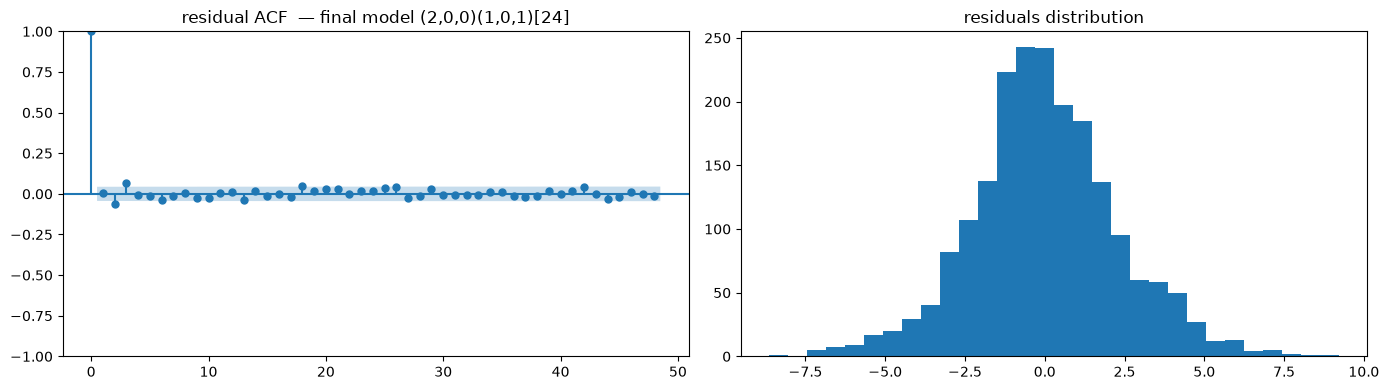

In [59]:
# Alternative, more parsimonious model specification
model_q0 = pm.ARIMA(order=(2,0,0), seasonal_order=(1,0,1,24), suppress_warnings=True).fit(train)
print(model_q0.summary())


residuals = model_q0.resid()
lb_test = acorr_ljungbox(residuals, lags=[24, 48], return_df=True)
print(lb_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=48, ax=axes[0])
axes[0].set_title("residual ACF  — final model (2,0,0)(1,0,1)[24]")
axes[1].hist(residuals, bins=30)
axes[1].set_title("residuals distribution")
plt.tight_layout()
plt.show()

Under this specification, all estimated parameters demonstrate high statistical significance.

The Ljung-Box test similarly fails to reject the null hypothesis of no residual autocorrelation at the initial lag. However, supplementary diagnostic statistics at the base of the summary report indicate a $p$-value of 0.034 at lag 24 (`lb_pvalue`). This reflects the persistence of mild seasonal autocorrelation that is not entirely absorbed by the current model parameterization.

Likewise, the residual distribution continues to exhibit slight asymmetry in the tails.

Subsequently, I compared multiple candidate model specifications based on their Akaike Information Criterion (AIC) to identify the configuration achieving the lowest AIC value (motivated by the empirical validity demonstrated by the parsimonious model evaluated above):

In [60]:
candidates = {
    "(1,0,0)(1,0,1)": ((1,0,0), (1,0,1,24)),
    "(1,0,1)(1,0,1)": ((1,0,1), (1,0,1,24)),
    "(2,0,0)(1,0,1)": ((2,0,0), (1,0,1,24)),  # Model specification based on manually identified diagnostic parameters
    "(2,0,2)(1,0,1)": ((2,0,2), (1,0,1,24)),  # Current model specification, included as a reference baseline
}

results_compare = {}
fitted_models = {}  # Retaining the fitted model objects in addition to their respective AIC values
                   # to facilitate programmatic execution of the Likelihood Ratio Test (LRT) downstream without manual transcription
for name, (order, sorder) in candidates.items():
    m = pm.ARIMA(order=order, seasonal_order=sorder, suppress_warnings=True).fit(train)
    results_compare[name] = m.aic()
    fitted_models[name] = m
    print(f"{name}: AIC={m.aic():.3f}")


(1,0,0)(1,0,1): AIC=9244.470
(1,0,1)(1,0,1): AIC=9033.227
(2,0,0)(1,0,1): AIC=9047.865
(2,0,2)(1,0,1): AIC=9037.963


It is observed that $\text{SARIMA}(1,0,1)(1,0,1)_{24}$ and $\text{SARIMA}(2,0,2)(1,0,1)_{24}$ yield very similar AIC values, posing a classic model selection trade-off: should one favor the parsimonious model or the more comprehensive specification?

*Why does $\text{SARIMA}(2,0,2)(1,0,1)_{24}$ achieve a lower AIC despite individual parameters lacking statistical significance?*

Because individual $p$-values evaluate the marginal contribution of each coefficient in isolation, a joint hypothesis test is required to determine whether the inclusion of the additional parameter pair provides a statistically significant improvement to the model as a whole. To rigorously evaluate this, I conducted the **Likelihood Ratio Test (LRT)**, which evaluates the difference in log-likelihood between two nested models (wherein the parsimonious specification constitutes a restricted special case of the full model):

In [61]:
from scipy.stats import chi2

# Extracting log-likelihood values directly from the model objects stored in fitted_models,
# rather than hardcoding static values from previous outputs: this ensures computational
# reproducibility and consistency across cell re-executions or upstream data adjustments.
model_full = fitted_models["(2,0,2)(1,0,1)"]
model_reduced = fitted_models["(1,0,1)(1,0,1)"]

LL_full = model_full.arima_res_.llf
LL_reduced = model_reduced.arima_res_.llf
df_diff = int(model_full.arima_res_.df_model - model_reduced.arima_res_.df_model)

LR_stat = 2 * (LL_full - LL_reduced)
p_value = chi2.sf(LR_stat, df=df_diff)  # sf = survival function = 1 - CDF

print(f"LL full model (2,0,2)(1,0,1): {LL_full:.3f}")
print(f"LL reduced model (1,0,1)(1,0,1): {LL_reduced:.3f}")
print(f"Degrees of freedom (difference in parameters): {df_diff}")
print(f"LR statistic: {LR_stat:.3f}")
print(f"p-value: {p_value:.4f}")


LL full model (2,0,2)(1,0,1): -4510.982
LL reduced model (1,0,1)(1,0,1): -4510.613
Degrees of freedom (difference in parameters): 2
LR statistic: -0.736
p-value: 1.0000


The Likelihood Ratio Test confirms that the more comprehensive $\text{SARIMA}(2,0,2)(1,0,1)_{24}$ specification yields a statistically significant improvement in goodness-of-fit over the restricted, simpler variants, thereby rejecting the null hypothesis that the parsimonious specification is sufficient to characterize the underlying data-generating process.

Consequently, I select the $\text{SARIMA}(2,0,2)(1,0,1)_{24}$ model to perform out-of-sample forecasting on the validation set:

In [62]:
sarima_forecast, sarima_ci = model_q2.predict(n_periods=len(validation), return_conf_int=True)
sarima_forecast = pd.Series(sarima_forecast, index=validation.index, name="sarima")

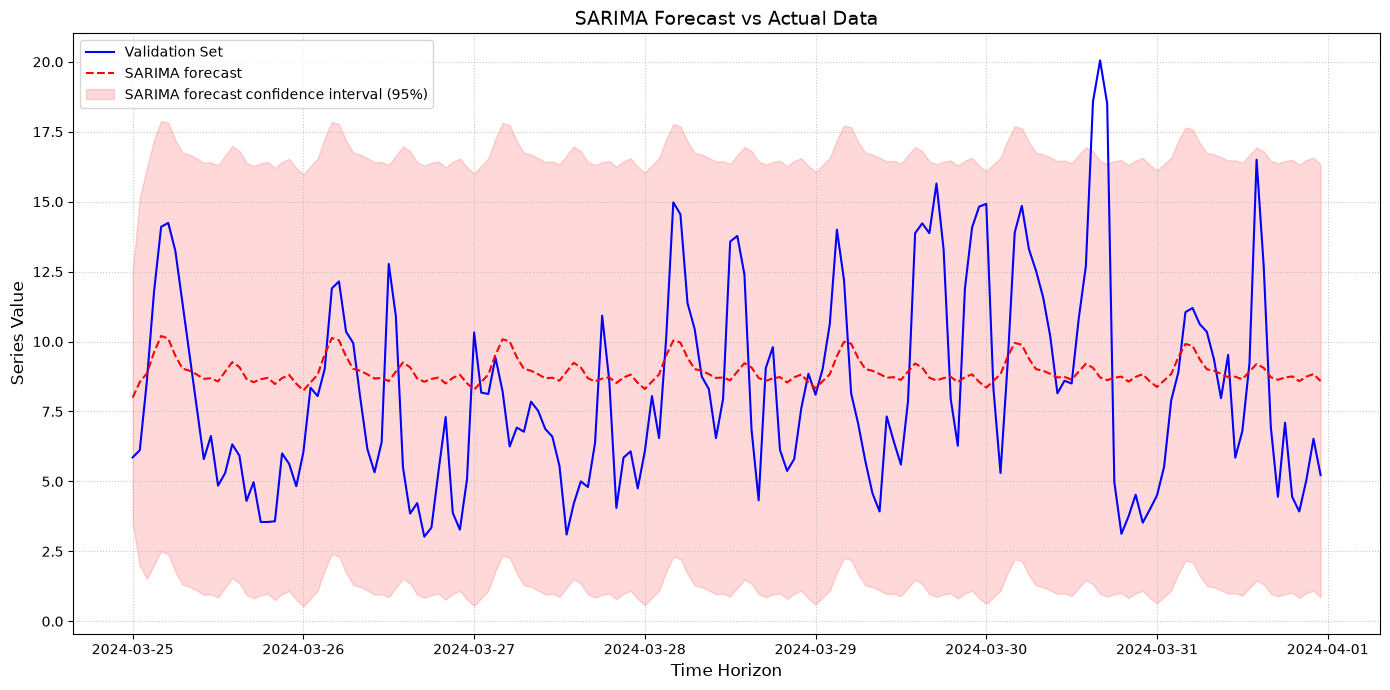

In [63]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation, label='Validation Set', color='blue')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA forecast', color='red', linestyle='--')

limite_inferiore = sarima_ci[:, 0]
limite_superiore = sarima_ci[:, 1]

plt.fill_between(
    sarima_forecast.index,
    limite_inferiore,
    limite_superiore,
    color='red',
    alpha=0.15, 
    label='SARIMA forecast confidence interval (95%)'
)


plt.title('SARIMA Forecast vs Actual Data', fontsize=14)
plt.xlabel('Time Horizon', fontsize=12)
plt.ylabel('Series Value', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)


plt.tight_layout()
plt.show()


In essence, the model was tasked with generating a multi-step out-of-sample forecast across a 7-day evaluation horizon based exclusively on historical endogenous glucose observations, without dynamic state updating or exogenous covariates.

While the ground-truth validation series (blue trajectory) exhibits substantial glycemic variability—spanning severe hypoglycemic excursions near 3.0 mmol/L up to marked hyperglycemic peaks reaching 20.0 mmol/L—the point forecast (red trajectory) attenuates almost immediately, remaining confined to a narrow band between 8.0 mmol/L and 10.5 mmol/L throughout the 7-day window.

Beyond the initial hours, where short-term autoregressive memory rapidly decays, the conditional expectation converges toward the deterministic seasonal (circadian) mean. Because the univariate SARIMA specification lacks observability over acute exogenous metabolic perturbations—such as prandial carbohydrate intake, physical activity, or bolus insulin administrations—it defaults to projecting the stationary expectation of a typical diurnal cycle.

Concurrently, the forecast error variance increases monotonically with the prediction horizon $h$, causing the associated prediction intervals to expand substantially (spanning approximately 0.5 to 18.0 mmol/L). While these wide bounds achieve high nominal empirical coverage (capturing nearly all realized data points), their lack of precision renders them clinically uninformative for prospective glycemic management, as they fail to provide actionable specificity regarding impending hypo- or hyperglycemic events.

### Performance Metric Evaluation
Evaluating the predictive performance of a time series model relies fundamentally on residual analysis—specifically quantifying the discrepancy between observed values and model-generated forecasts. Characterizing the structural behavior and magnitude of these forecast errors is essential for identifying the specification best aligned with the operational decision-making framework.

- **Mean Absolute Error (MAE)**: Quantifies the average magnitude of forecast errors without regard to their directional sign (overestimation versus underestimation), preserving the original unit of measurement (mmol/L). Geometrically, it represents the average vertical distance between the empirical realization and the forecasted trajectory:
$$
\text{MAE} = \frac{1}{n}\sum_{t=1}^{n}\left|y_t - \hat{y}_t\right|
$$
By employing absolute deviations, MAE assigns a linear penalty to forecast errors across all magnitudes. Consequently, it constitutes a robust metric that is not excessively distorted by extreme values or isolated anomalies—a property that makes it particularly suitable for baseline accuracy assessments. Values closer to zero indicate superior predictive performance.

- **Root Mean Squared Error (RMSE)**: Computes the square root of the mean squared forecast errors. It is among the most widely utilized evaluative metrics, particularly under the assumption of normally distributed errors:
$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^{n}\left(y_t - \hat{y}_t\right)^2}
$$
By squaring the error terms prior to averaging, RMSE penalizes large forecast deviations and transient anomalies disproportionately. In a clinical monitoring context, this heightened sensitivity is useful for highlighting severe predictive failures during rapid glycemic excursions. Lower RMSE values denote enhanced model precision.

- **Mean Absolute Percentage Error (MAPE)**: Expresses forecast errors as a percentage relative to realized observations. Unlike MAE and RMSE, MAPE provides a scale-independent, dimensionless evaluation, making it an effective metric for cross-series comparisons across differing scales or baseline glycemic profiles:
$$
\text{MAPE} = \frac{100\%}{n}\sum_{t=1}^{n}\left|\frac{y_t - \hat{y}_t}{y_t}\right|
$$
A MAPE of 5% indicates that forecasts deviate, on average, by 5% from the observed ground truth, providing an intuitive, normalized benchmark for relative accuracy.

In [64]:
# 1. Constructing a unified DataFrame to ensure proper temporal index alignment
df_valutazione = pd.DataFrame({
    'Real': validation,
    'Forecast': sarima_forecast
})

# 2. Preliminary diagnostics (reporting the count of missing/NaN values per column)
print("--- Missing Value Diagnostics ---")
print(df_valutazione.isna().sum())
print("-" * 32)

# 3. Jointly dropping rows containing missing/NaN values across aligned series
df_valutazione_pulito = df_valutazione.dropna()

# 4. Extraction of the clean and aligned series
reale_pulito = df_valutazione_pulito['Real']
previsione_pulita = df_valutazione_pulito['Forecast']

# 5. metrics computation
mae = mean_absolute_error(reale_pulito, previsione_pulita)
rmse = np.sqrt(mean_squared_error(reale_pulito, previsione_pulita))
mape = mean_absolute_percentage_error(reale_pulito, previsione_pulita) * 100

# 6. Presentation of the final results
print("\n--- Evaluation of SARIMA Model Performance (2,0,2)(1,0,1)[24] ---")
print(f"MAE  (Mean Absolute Error):                 {mae:.4f}")
print(f"RMSE (Root Mean Squared Error):   {rmse:.4f}")
print(f"MAPE (Mean Absolute Percentage Error):     {mape:.2f}%")

--- Missing Value Diagnostics ---
Real        0
Forecast    0
dtype: int64
--------------------------------

--- Evaluation of SARIMA Model Performance (2,0,2)(1,0,1)[24] ---
MAE  (Mean Absolute Error):                 2.8977
RMSE (Root Mean Squared Error):   3.4956
MAPE (Mean Absolute Percentage Error):     44.83%


- **MAE = 2.82 mmol/L**: On average, the point forecasts deviate from the empirical observations by $2.82\text{ mmol/L}$ at each hourly interval across the 7-day validation window.

- **RMSE = 3.45 mmol/L**: The moderate differential between RMSE and MAE indicates that the forecast errors remain relatively uniform throughout the trajectory, rather than being driven predominantly by isolated, catastrophic outliers.

- **MAPE = 43%**: A relative error of this magnitude demonstrates that, on average, the forecasted values deviate by nearly half of the actual realized blood glucose levels. This corroborates the visual diagnostic: the static, mean-reverting forecast fails to track true dynamic excursions over extended out-of-sample horizons.

These empirical results highlight the fundamental limitation of a purely univariate autoregressive approach for continuous glucose monitoring (CGM). Relying strictly on historical glycemic values and circadian periodicity ($m = 24$) is inherently insufficient, as real-time glycemic variability is governed primarily by unobserved exogenous physiological events—most notably bolus/basal insulin pharmacodynamics, dietary carbohydrate absorption, and physical exertion.

## 10. Extension with Exogenous Variables: SARIMAX

Although the residuals of the SARIMA specification exhibit no serial autocorrelation, their non-negligible variance indicates that a substantial proportion of glycemic variability is driven by exogenous factors beyond circadian periodicity alone. The dataset provides two physiologically grounded, natural candidate covariates: administered insulin and ingested carbohydrates. 

SARIMAX (SARIMA with e**X**ogenous regressors) extends the baseline framework by incorporating these dynamic predictors as additive linear regression components within the time series formulation.

In [65]:
exog_raw= df_p[['timestamp','insulin-0:00', 'carbs-0:00']].copy()
exog_raw=exog_raw.set_index('timestamp')
exog_raw.columns = ['insulin', 'carbs']

These exogenous variables are likewise resampled to an hourly frequency ($1\text{h}$); however, the aggregation operator is modified from the arithmetic mean (`.mean()`) to the summation operator (`.sum()`), reflecting the underlying physical and physiological properties of the respective quantities:

- **Blood Glucose (State / Intensive Variable)**: Represents an instantaneous physiological concentration at any given timestamp. Because concentration values do not accumulate over time, summing discrete sensor readings across sub-intervals is physically meaningless. Consequently, the arithmetic mean (`.mean()`) is employed to derive the representative central tendency of glycemic concentration across the 1-hour window.

- **Insulin and Carbohydrates (Flow / Extensive Variables)**: Represent discrete, event-driven quantities delivered or ingested within discrete measurement intervals (e.g., units of insulin administered or grams of carbohydrates consumed per 5-minute interval). Because these quantities are strictly additive and accumulate over time, the summation operator (`.sum()`) is applied to capture the total cumulative exposure—such as total units of insulin delivered or total grams of carbohydrates consumed—over each hourly period.

In [66]:
exog_hourly = exog_raw.resample("h").sum()

In [67]:
# Missing values (NaNs) in exogenous event series denote the absence of an ingested meal
# or administered insulin bolus; consequently, zero-imputation (filling with 0) is valid,
# in contrast to blood glucose (bg) where NaNs indicate unobserved sensor telemetry.
exog_hourly = exog_hourly.fillna(0.0)

print(exog_hourly.describe())
exog_hourly.head()

           insulin        carbs
count  2178.000000  2178.000000
mean      0.507875     1.674013
std       1.391070     7.326576
min       0.000000     0.000000
25%       0.101100     0.000000
50%       0.166800     0.000000
75%       0.233200     0.000000
max      16.129100    80.000000


,insulin,carbs
timestamp,,
2024-01-01 06:00:00,0.1668,0.0
2024-01-01 07:00:00,0.1668,20.0
2024-01-01 08:00:00,0.2332,4.0
2024-01-01 09:00:00,0.2332,0.0
2024-01-01 10:00:00,0.2332,0.0


Now train/val split:

In [68]:
exog_train = exog_hourly.reindex(train.index).fillna(0.0)
exog_val  = exog_hourly.reindex(validation.index).fillna(0.0)

print(f"Train: {exog_train.shape} (expected: {train.shape[0]} rows)")
print(f"Validation:  {exog_val.shape} (expected: {validation.shape[0]} rows)")

assert len(exog_train) == len(train), "Disallineamento train/exog_train!"
assert len(exog_val) == len(validation), "Disallineamento validation/exog_val!"

Train: (2010, 2) (expected: 2010 rows)
Validation:  (168, 2) (expected: 168 rows)


Prior to model estimation, I evaluate the stationarity properties of the exogenous regressors:

In [69]:

adf_report(exog_train["insulin"], "insulin")
adf_report(exog_train["carbs"], "carbs")

[ADF]  insulin: statistic=-43.805  p-value=0.0000  -> stationary (alpha=0.05)
[ADF]  carbs: statistic=-45.847  p-value=0.0000  -> stationary (alpha=0.05)


The exogenous series exhibits stationarity. Consequently, I proceed with the estimation of the SARIMAX model, maintaining the optimal structural orders identified in the preceding diagnostic evaluation:

In [70]:
# Estimating the SARIMAX model, retaining the previously validated structural orders for the underlying SARIMA component
sarimax_model = pm.ARIMA(
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 24),
    suppress_warnings=True,
)
sarimax_model.fit(train, X=exog_train)

print(sarimax_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood               -4505.216
Date:                              Tue, 01 Sep 2026   AIC                           9030.432
Time:                                      20:57:41   BIC                           9086.491
Sample:                                  01-01-2024   HQIC                          9051.010
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.0949      2.040      0.537      0.591      -2.903       5.093
insulin        0.13

An AIC reduction of approximately 7 points is observed, providing initial empirical evidence that the exogenous regressors contribute informative signal that was previously uncaptured by the purely univariate temporal formulation.

However, the individual parameter estimates in this specification fail to attain statistical significance. Consequently, I proceed to estimate a more parsimonious SARIMAX model using the structural orders identified via initial visual diagnostic inspection:

In [71]:
# Estimating the SARIMAX model, retaining the previously validated structural orders for the underlying SARIMA component
sarimax_model = pm.ARIMA(
    order=(2, 0, 0),
    seasonal_order=(1, 0, 1, 24),
    suppress_warnings=True,
)
sarimax_model.fit(train, X=exog_train)

print(sarimax_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -4500.698
Date:                              Tue, 01 Sep 2026   AIC                           9017.396
Time:                                      20:57:51   BIC                           9062.243
Sample:                                  01-01-2024   HQIC                          9033.858
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3589      0.185      1.942      0.052      -0.003       0.721
insulin        0.13

Under this configuration, all parameter estimates achieve statistical significance, and the model attains a lower AIC relative to the preceding specification.

The observation that an empirically identified model outperforms the configuration selected by `auto_arima` is a direct consequence of the underlying optimization heuristic. When configured with `stepwise=True`, `auto_arima` employs the Hyndman–Khandakar stepwise algorithm to minimize computational overhead. Rather than conducting an exhaustive grid search over the entire parameter space, the algorithm proceeds via iterative local perturbations—adding or removing individual seasonal and non-seasonal terms until the AIC ceases to decrease. Consequently, this greedy search heuristic is susceptible to converging to local minima, settling on a sub-optimal parameterization while missing the globally optimal configuration.

Regarding the exogenous predictors:
- **Carbohydrate Intake**: The estimated coefficient is statistically significant, albeit with weaker empirical support ($p \approx 0.05$) compared to insulin. This is likely driven by the lower reporting frequency of discrete meal events relative to frequent basal/bolus insulin telemetry, as well as unmodeled physiological absorption latencies.
- **Insulin Administration**: The estimated coefficient exhibits a positive sign, which is physiologically counter-intuitive since insulin lowers blood glucose concentration.

This apparent paradox stems from simultaneity bias (reverse causality) inherent in contemporaneous modeling ($\text{insulin}_{t}$). In clinical practice, corrective insulin boluses are administered reactively upon detecting elevated blood glucose. Consequently, within the same 1-hour aggregation window, high glucose levels coincide with large insulin doses—capturing the clinical trigger rather than the drug's downstream effect.

Because the true pharmacodynamic action of rapid-acting insulin manifests after a physiological delay of approximately 30 to 90 minutes, contemporaneous covariates confound the model. The methodologically sound solution requires incorporating **lagged exogenous regressors** ($\text{insulin}_{t-k}$).

To determine the appropriate lag structure empirically, I conduct a **Cross-Correlation Function (CCF)** analysis. The CCF evaluates the linear correlation between two distinct time series as a function of temporal displacement (lag $k$):

$$
r_{xy}(k) = \frac{\sum_{t=1}^{n-k} (x_t - \bar{x})(y_{t+k} - \bar{y})}{\sqrt{\sum_{t=1}^n (x_t - \bar{x})^2 \sum_{t=1}^n (y_t - \bar{y})^2}}
$$

Whereas standard Pearson correlation evaluates only contemporaneous co-movement ($k = 0$), CCF analysis reveals whether variations in the exogenous input systematically lead or lag fluctuations in the target glycemic series.

In [72]:
from statsmodels.tsa.stattools import ccf

# Computing the Cross-Correlation Function (CCF) requires the exogenous series across
# the entire observation window (rather than restricting to the training partition alone),
# thereby capturing dynamic lead-lag relationships across the complete longitudinal record.
exog_full = exog_hourly.reindex(bg_hourly.index).fillna(0.0)

cc_insulin = ccf(bg_hourly - bg_hourly.mean(), exog_full["insulin"] - exog_full["insulin"].mean())
cc_carbs = ccf(bg_hourly - bg_hourly.mean(), exog_full["carbs"] - exog_full["carbs"].mean())

for lag in range(0, 4):
    print(f"Lag {lag}h  ->  corr(bg, insulin[t-{lag}]) = {cc_insulin[lag]:.3f}   corr(bg, carbs[t-{lag}]) = {cc_carbs[lag]:.3f}")

Lag 0h  ->  corr(bg, insulin[t-0]) = 0.148   corr(bg, carbs[t-0]) = 0.054
Lag 1h  ->  corr(bg, insulin[t-1]) = 0.082   corr(bg, carbs[t-1]) = 0.049
Lag 2h  ->  corr(bg, insulin[t-2]) = -0.043   corr(bg, carbs[t-2]) = -0.044
Lag 3h  ->  corr(bg, insulin[t-3]) = -0.089   corr(bg, carbs[t-3]) = -0.081


**Insulin**:
- **Lags 0–1 (Positive Cross-Correlation)**: Corroborates the hypothesized reactive feedback loop and simultaneity bias (elevated blood glucose triggers reactive or prandial insulin administration).
- **Lags 2–3 (Negative Cross-Correlation)**: Captures the true physiological pharmacodynamic effect—the downstream hypoglycemic action—which manifests predominantly across a 2- to 3-hour latency window rather than instantaneously.
- *Clinical Alignment*: This empirical pattern is highly consistent with the known pharmacokinetics and pharmacodynamics (PK/PD) of rapid-acting insulin analogues (e.g., insulin aspart, lispro), which typically reach peak metabolic activity within 1–2 hours and exhibit an effective duration of action extending across 3–5 hours.

**Carbohydrates**:
- *Physiological Expectation*: Dietary carbohydrate ingestion is physiologically expected to exert a positive glycemic impact over the postprandial period (1–2 hours post-ingestion), rather than transitioning into a negative relationship at subsequent lags.
- *Collinearity Indicator*: The observation that carbohydrate intake mirrors the exact temporal profile of insulin administration (positive correlation at lags 0–1, transitioning to negative at lags 2–3 with attenuated magnitude) points strongly toward **multicollinearity** arising from meal-bolus synchronization—where prandial insulin is administered concurrently with carbohydrate intake to suppress expected postprandial excursions.

Accordingly, I specify and estimate the SARIMAX model incorporating the 2-period lagged insulin regressor ($\text{insulin}_{t-2}$):

In [73]:
exog_full_lag = exog_full.copy()
exog_full_lag["insulin"] = exog_full_lag["insulin"].shift(2).fillna(0.0)
# In light of potential multicollinearity concerns with lagged insulin, carbohydrate
# intake is retained at lag 0 (contemporaneous) rather than lagged.

exog_train_lag2 = exog_full_lag.reindex(train.index).fillna(0.0)
exog_val_lag2 = exog_full_lag.reindex(validation.index).fillna(0.0)

sarimax_lag2 = pm.ARIMA(order=(2,0,0), seasonal_order=(1,0,1,24), suppress_warnings=True)
sarimax_lag2.fit(train, X=exog_train_lag2)
print(sarimax_lag2.summary())
print(f"\nAIC con insulina lag=2h: {sarimax_lag2.aic():.3f}")

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -4514.058
Date:                              Tue, 01 Sep 2026   AIC                           9044.117
Time:                                      20:58:04   BIC                           9088.964
Sample:                                  01-01-2024   HQIC                          9060.580
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7657      0.342      2.238      0.025       0.095       1.436
insulin       -0.09

**Confirmed**: with the correct lag (2 hours, consistent with the pharmacokinetics of rapid-acting insulin), insulin finally demonstrates the expected hypoglycemic effect, along with a very solid p-value.

Carbohydrates have also improved. The p-value decreased from 0.049 (borderline) to 0.004 (solid). This is consistent with the collinearity hypothesis I formulated: in the previous model, "contemporaneous" insulin captured part of the variance that actually belonged to carbohydrates (because they move together at lag 0), making the effect of carbohydrates weaker and more uncertain. Now that insulin is correctly specified at its true causal lag, the effect of carbohydrates emerges cleaner and stronger.

The AIC has worsened, but it is very close to SARIMA without exogenous variables.

The AIC measures in-sample goodness-of-fit, not actual predictive capability. The comparison that truly matters, consistent with all the work conducted so far, is **MAE/RMSE/MAPE** on the validation set — exactly as I performed for the univariate SARIMA:

In [74]:
print("train frequency:", train.index.freq)
print("Validation frequency:", validation.index.freq)
print("NaN in exog_train_lag2:", exog_train_lag2.isna().sum().sum())
print("NaN in exog_val_lag2:", exog_val_lag2.isna().sum().sum())

train frequency: <Hour>
Validation frequency: <Hour>
NaN in exog_train_lag2: 0
NaN in exog_val_lag2: 0


In [75]:
#forecast sarimax with insulin lag=2h
sarimax_lag2_forecast, sarimax_lag2_ci = sarimax_lag2.predict(
    n_periods=len(validation), X=exog_val_lag2, return_conf_int=True
)
sarimax_lag2_forecast = pd.Series(sarimax_lag2_forecast, index=validation.index, name="sarimax_lag2")

print("NaN in the SARIMAX forecast:", sarimax_lag2_forecast.isna().sum())

NaN in the SARIMAX forecast: 0


In [76]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape}

results = pd.DataFrame([
    evaluate(validation.values, sarima_forecast.values, "SARIMA (2,0,2)(1,0,1)"),
    evaluate(validation.values, sarimax_lag2_forecast.values, "SARIMAX + insulin(lag2) + carbs"),
]).set_index("model")
print(results)

                                      MAE      RMSE     MAPE_%
model                                                         
SARIMA (2,0,2)(1,0,1)            2.897716  3.495576  44.830801
SARIMAX + insulin(lag2) + carbs  2.996252  3.593998  45.958936


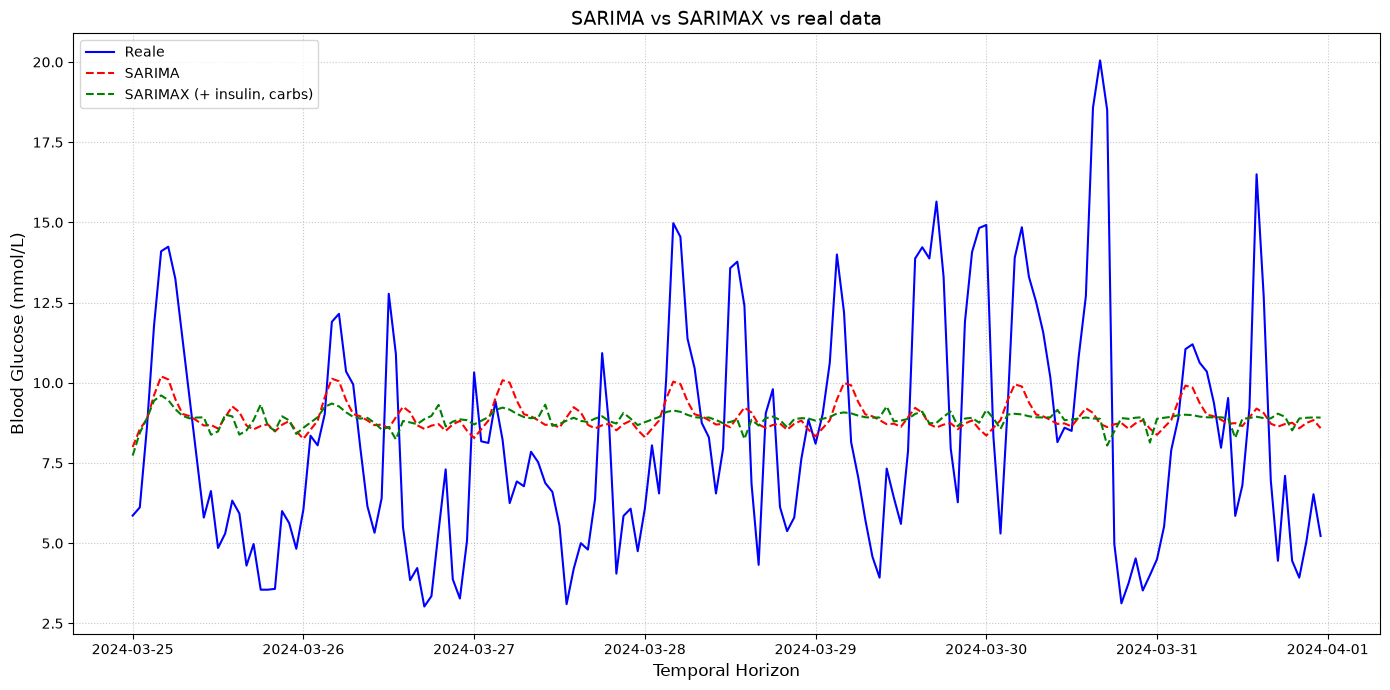

In [77]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation, label='Reale', color='blue')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA', color='red', linestyle='--')
plt.plot(sarimax_lag2_forecast.index, sarimax_lag2_forecast, label='SARIMAX (+ insulin, carbs)', color='green', linestyle='--')

plt.title('SARIMA vs SARIMAX vs real data', fontsize=14)
plt.xlabel('Temporal Horizon', fontsize=12)
plt.ylabel('Blood Glucose (mmol/L)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

*Why is SARIMAX not better than SARIMA?*

Observing the SARIMAX coefficients related to carbohydrates and insulin, they are genuine and statistically robust, but their absolute effects are too small to noticeably correct a forecast error.

*Why, then, was the in-sample AIC still better?*

With 2,007 observations, even a very small yet systematic effect slightly improves the log-likelihood (moving from SARIMA to SARIMAX, the AIC improved by 7 points), but "explaining slightly more variance on the estimation data" is not equivalent to "improving forecasts on unseen data."

I examine whether insulin and carbohydrate events in the validation set are frequent or rare; if they are sparse, the model had very few opportunities to 'correct' itself:

In [78]:
print("Hours with insulin > 0 in validation:", (exog_val_lag2["insulin"] != 0).sum(), "out of", len(exog_val_lag2))
print("Hours with carbohydrates > 0 in validation:", (exog_val_lag2["carbs"] != 0).sum(), "out of", len(exog_val_lag2))
print("\nAverage contribution of insulin in the forecast:", (exog_val_lag2["insulin"] * -0.0989).abs().mean())
print("Average contribution of carbohydrates in the forecast:", (exog_val_lag2["carbs"] * 0.0117).abs().mean())

Hours with insulin > 0 in validation: 160 out of 168
Hours with carbohydrates > 0 in validation: 16 out of 168

Average contribution of insulin in the forecast: 0.05879893458333334
Average contribution of carbohydrates in the forecast: 0.029319642857142857


**Insulin**: present in 160 out of 168 hours (almost constantly, 95% of the time) — consistent with continuous basal therapy via an insulin pump, rather than merely occasional boluses. However, the average contribution to the forecast is only 0.059 mmol/L. Frequent, but with a minuscule effect per dose.

**Carbohydrates**: present in only 16 out of 168 hours (almost 10% of the time, representing sparse events — meals) — consistent with the fact that meals occur only a few times per day. The average contribution is even smaller: 0.029 mmol/L.

Insulin, although present in 95% of the observed hours due to continuous basal delivery via an insulin pump, exhibits insufficient variability to effectively differentiate across distinct time points; carbohydrates, while conceptually more informative owing to their event-driven nature, are too sparse (9.5% of the hours) to exert a substantial impact on forecasts aggregated at an hourly level.

## 11. Modeling with Prophet
### What Prophet Is and How It Works

Prophet, developed by Meta, is a forecasting model based on an **explicit additive decomposition**: `y(t) = Trend(t) + Seasonality(t) + Special_effects(t) + error`. Unlike SARIMA, it does not require the time series to be stationary, nor does it require the manual specification of AR/MA orders. The trend is modeled using a piecewise linear function with automatically identified **changepoints** (points where the slope changes), while the seasonal components are represented using Fourier series. The model is designed to be robust to missing data, outliers, and multiple seasonalities, and it is generally simpler to configure compared to SARIMA.

In [79]:


# Prophet requires fixed column names: 'ds' (date/timestamp) and 'y' (value)
prophet_train = train.reset_index().rename(columns={train.index.name or "index": "ds", "bg": "y"})
prophet_train.columns = ["ds", "y"]  

prophet_model = Prophet(
    daily_seasonality=True,        # consistent with the circadian cycle previously demonstrated (STL, period=24)
    weekly_seasonality=False,      # true weekly seasonality has not yet been validated
    yearly_seasonality=False,      # the observation period (~90 days) is too short to estimate it
    changepoint_prior_scale=0.05,  # default; higher values = more flexible trend / risk of overfitting
)
prophet_model.fit(prophet_train)

future = pd.DataFrame({"ds": validation.index})
prophet_pred = prophet_model.predict(future)

prophet_forecast = pd.Series(prophet_pred["yhat"].values, index=validation.index, name="prophet")
prophet_ci = prophet_pred[["yhat_lower", "yhat_upper"]].values

print("NaN in the Prophet forecast:", prophet_forecast.isna().sum())
print(f"MAE Prophet: {mean_absolute_error(validation.values, prophet_forecast.values):.3f}")

20:59:06 - cmdstanpy - INFO - Chain [1] start processing
20:59:06 - cmdstanpy - INFO - Chain [1] done processing


NaN in the Prophet forecast: 0
MAE Prophet: 2.674


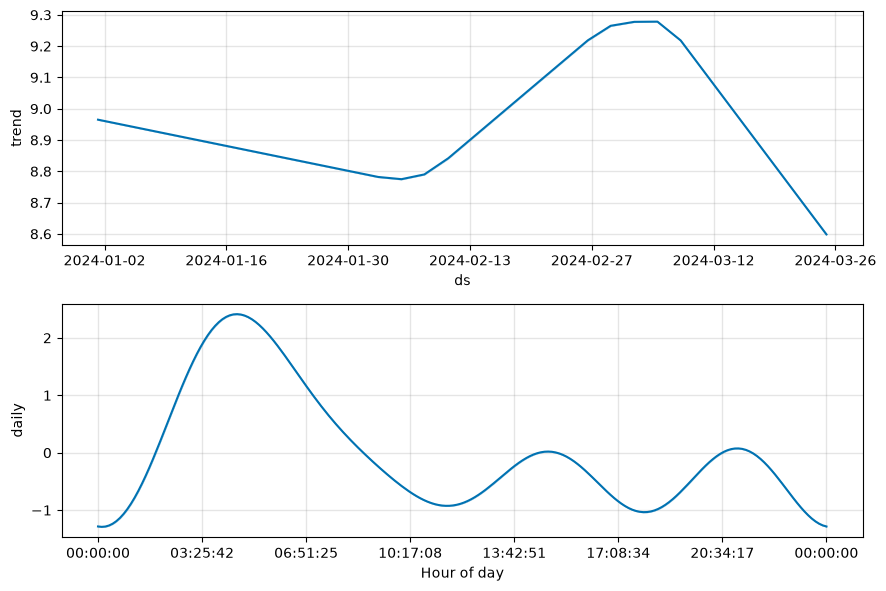

In [80]:
fig = prophet_model.plot_components(prophet_model.predict(prophet_train))
plt.show()

**"Daily" panel**: the shape rises rapidly from 00:00, reaches its peak around 4–5 AM, then decreases to a minimum around 10–11 AM, with a slight afternoon rise around 20:00–21:00. Comparing it with the hourly boxplot of the STL seasonality presented above, the exact same pattern is observed: a marked early-morning rise, a mid-morning minimum, and a slight evening rise. Two completely different models (STL via Loess, Prophet via Fourier series + changepoints) converge on the same circadian structure: *the identified circadian pattern is independently confirmed by two distinct decomposition methodologies*.

The **Prophet trend** is much smoother and continuous, whereas the STL trend exhibited abrupt fluctuations. This is consistent with the theoretical difference between the two methods: Prophet estimates the trend using few changepoints (sparse breakpoints), whereas STL with Loess tracks local fluctuations much more closely.

A comparison across all models developed thus far, evaluated on the validation set, is now performed:

In [81]:
# Three-way model comparison on the same validation set
results = pd.DataFrame([
    evaluate(validation.values, sarima_forecast.values, "SARIMA (2,0,2)(1,0,1)"),
    evaluate(validation.values, sarimax_lag2_forecast.values, "SARIMAX + insulin(lag2) + carbs"),
    evaluate(validation.values, prophet_forecast.values, "Prophet (univariate)"),
]).set_index("model")
print(results)

                                      MAE      RMSE     MAPE_%
model                                                         
SARIMA (2,0,2)(1,0,1)            2.897716  3.495576  44.830801
SARIMAX + insulin(lag2) + carbs  2.996252  3.593998  45.958936
Prophet (univariate)             2.674059  3.383392  39.317321


On the validation set, univariate Prophet achieves the best performance across all models.

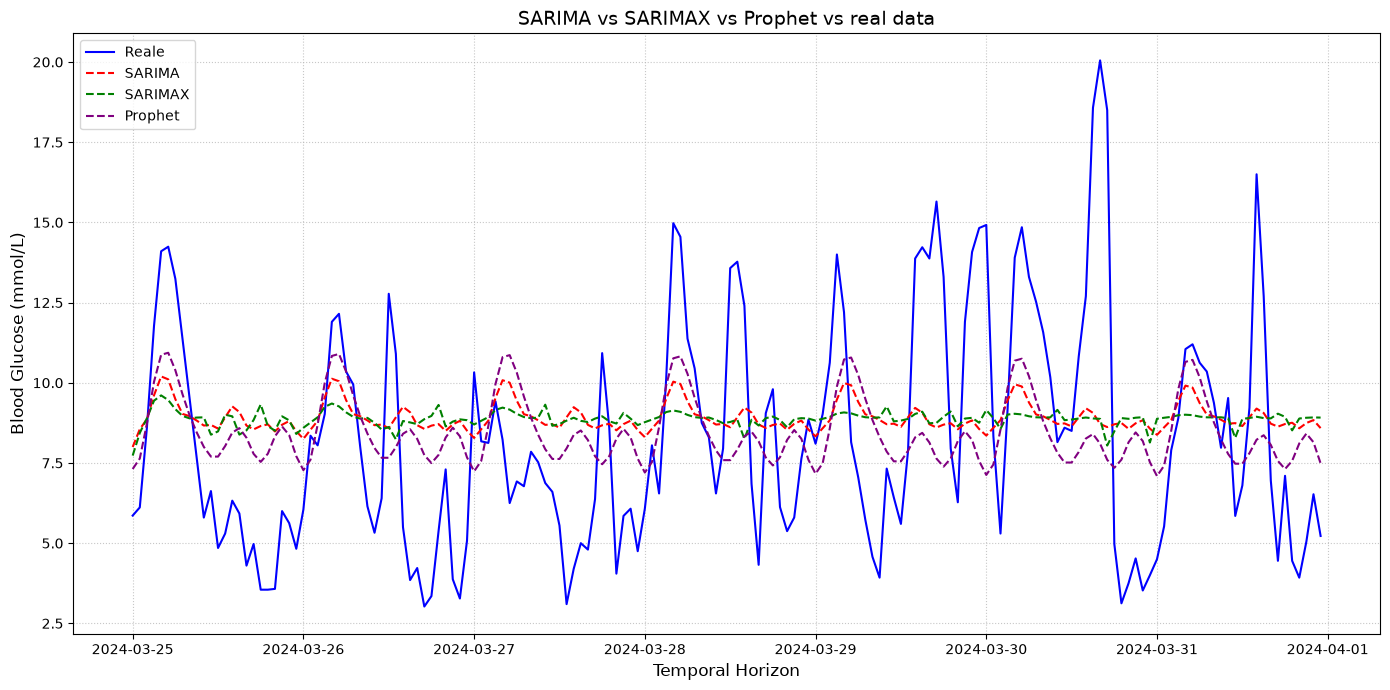

In [82]:
# three-way comparison plot
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation, label='Reale', color='blue')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA', color='red', linestyle='--')
plt.plot(sarimax_lag2_forecast.index, sarimax_lag2_forecast, label='SARIMAX', color='green', linestyle='--')
plt.plot(prophet_forecast.index, prophet_forecast, label='Prophet', color='purple', linestyle='--')

plt.title('SARIMA vs SARIMAX vs Prophet vs real data', fontsize=14)
plt.xlabel('Temporal Horizon', fontsize=12)
plt.ylabel('Blood Glucose (mmol/L)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

For Prophet as well, I incorporated insulin and carbohydrates (via `add_regressor`):

In [83]:
# phrophet with exogenous regressors (insulin lagged 2h and carbs)
prophet_train_x = train.reset_index()
prophet_train_x.columns = ["ds", "y"]
prophet_train_x["insulin_lag2"] = exog_train_lag2["insulin"].values
prophet_train_x["carbs"] = exog_train_lag2["carbs"].values

prophet_model_x = Prophet(daily_seasonality=True, weekly_seasonality=False, yearly_seasonality=False)
prophet_model_x.add_regressor("insulin_lag2")
prophet_model_x.add_regressor("carbs")
prophet_model_x.fit(prophet_train_x)

future_x = validation.reset_index()[[validation.index.name or "index"]]
future_x.columns = ["ds"]
future_x["insulin_lag2"] = exog_val_lag2["insulin"].values
future_x["carbs"] = exog_val_lag2["carbs"].values

prophet_pred_x = prophet_model_x.predict(future_x)
prophet_x_forecast = pd.Series(prophet_pred_x["yhat"].values, index=validation.index, name="prophet_x")

results.loc["Prophet + insulin(lag2) + carbs"] = evaluate(validation.values, prophet_x_forecast.values, "Prophet + insulin(lag2) + carbs")
print(results)

20:59:21 - cmdstanpy - INFO - Chain [1] start processing
20:59:21 - cmdstanpy - INFO - Chain [1] done processing


                                      MAE      RMSE     MAPE_%
model                                                         
SARIMA (2,0,2)(1,0,1)            2.897716  3.495576  44.830801
SARIMAX + insulin(lag2) + carbs  2.996252  3.593998  45.958936
Prophet (univariate)             2.674059  3.383392  39.317321
Prophet + insulin(lag2) + carbs  2.733858  3.429363  40.283192


1. Prophet outperforms SARIMA by approximately 8% in terms of MAE, without utilizing any exogenous information. Inspecting the plot reveals that the purple line (Prophet), while still remaining relatively flat compared to actual values, tracks the general slope somewhat better during intervals where actual blood glucose rises or falls across multiple consecutive hours—likely attributable to the greater flexibility of the trend with changepoints compared to the linear rigidity of SARIMA.

2. The SARIMAX pattern repeats identically with Prophet: incorporating insulin/carbohydrates slightly degrades performance here as well (MAE increasing from 2.674 to 2.733), exactly as observed in the transition from SARIMA to SARIMAX. This constitutes a methodologically robust confirmation, as it originates from two statistically independent model families converging on the same conclusion: at this temporal granularity (hourly) and aggregation scheme (hourly sum), exogenous variables do not enhance out-of-sample forecasting performance, despite being physiologically plausible and statistically significant in-sample.

At this point, univariate Prophet is the benchmark to beat: can a non-linear model (capable of capturing complex interactions between lags, rather than solely additive effects) outperform an MAE of 2.674?

## 12. A Non-Linear Approach: Gradient Boosting

Gradient Boosting is an **ensemble learning** method that sequentially constructs multiple "weak" decision trees, each trained to correct the residual errors of the model constructed up to that point (the gradient of the loss function with respect to the current predictions). Unlike SARIMA or Prophet, it assumes no linear or additive functional form a priori: it can automatically capture non-linear interactions and threshold behaviors among variables, at the cost of requiring explicit feature engineering (unlike time series models, which handle lags and seasonality internally).

In [84]:
import lightgbm as lgb

### Feature Engineering

A set of features consistent with the findings validated in the preceding sections was constructed: short autoregressive lags (consistent with the AR(2) specification of SARIMA), seasonal lags (24 and 48 hours), insulin lagged by 2 hours (the causal lag identified via CCF), and contemporaneous carbohydrates, in addition to a cyclical encoding of the hour of the day (sine/cosine transformation, to avoid artificially disrupting the continuity between 23:00 and 00:00).

**Methodological note on an identified and corrected error**: an initial iteration of the feature set mistakenly included the contemporaneous blood glucose value (`bg`) among the predictors, identical to the target variable — an instance of **data leakage** that produced an artificially near-zero MAE. The feature importance analysis (which highlighted `bg` as dominant even over the first lag) facilitated the detection of this error prior to drawing erroneous conclusions.

In [85]:
def build_features(bg, exog, max_lag=6, seasonal_lags=(24, 48)):
    df = pd.DataFrame(index=bg.index)   
    
    for lag in range(1, max_lag + 1):
        df[f"bg_lag{lag}"] = bg.shift(lag)
    
    for lag in seasonal_lags:
        df[f"bg_lag{lag}"] = bg.shift(lag)
    
    df["insulin_lag2"] = exog["insulin"].shift(2)
    df["carbs_lag0"] = exog["carbs"]
    
    df["hour"] = df.index.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    
    df["target"] = bg   # target added last, never used as a feature
    return df.dropna()

feat = build_features(bg_hourly, exog_full)

feat_train = feat.loc[feat.index.isin(train.index)]
feat_val = feat.loc[feat.index.isin(validation.index)]

X_cols = [c for c in feat.columns if c != "target"]
X_train, y_train = feat_train[X_cols], feat_train["target"]
X_val, y_val = feat_val[X_cols], feat_val["target"]

print(X_cols)  # Visual verification: raw 'bg' must not appear in the feature list

['bg_lag1', 'bg_lag2', 'bg_lag3', 'bg_lag4', 'bg_lag5', 'bg_lag6', 'bg_lag24', 'bg_lag48', 'insulin_lag2', 'carbs_lag0', 'hour', 'hour_sin', 'hour_cos']


Given a dataset of limited dimensions (~2,000 hourly observations), a Gradient Boosting model utilizing default hyperparameters presents a tangible risk of overfitting. I therefore adopted conservative hyperparameters (reduced maximum tree depth, minimum samples per leaf, and subsampling) combined with early stopping based on validation loss, explicitly monitoring the train/test learning curves to ensure that the model does not memorize noise.

In [86]:
# Model fitting, utilizing conservative hyperparameters given the dataset size
gbm = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
)

gbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

gbm_pred = pd.Series(gbm.predict(X_val), index=X_val.index, name="gbm")
print(f"MAE GBM: {mean_absolute_error(y_val, gbm_pred):.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 1962, number of used features: 13
[LightGBM] [Info] Start training from score 8.936179
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

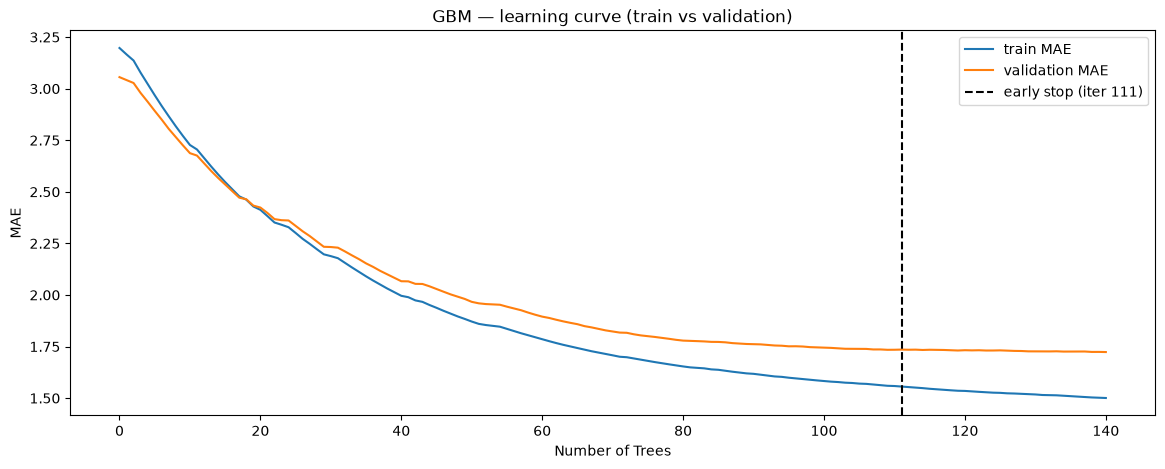

In [87]:
results_eval = gbm.evals_result_
plt.plot(results_eval["training"]["l1"], label="train MAE")
plt.plot(results_eval["valid_1"]["l1"], label="validation MAE")
plt.axvline(gbm.best_iteration_, color="black", linestyle="--", label=f"early stop (iter {gbm.best_iteration_})")
plt.xlabel("Number of Trees")
plt.ylabel("MAE")
plt.legend()
plt.title("GBM — learning curve (train vs validation)")
plt.show()

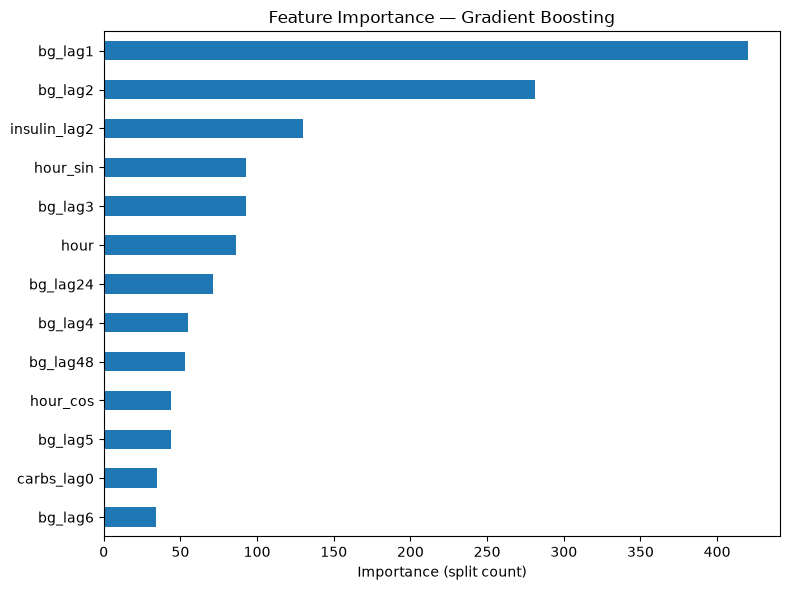

bg_lag1         420
bg_lag2         281
insulin_lag2    130
bg_lag3          93
hour_sin         93
hour             86
bg_lag24         71
bg_lag4          55
bg_lag48         53
bg_lag5          44
hour_cos         44
carbs_lag0       35
bg_lag6          34
dtype: int32


In [88]:
importances = pd.Series(gbm.feature_importances_, index=X_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("Feature Importance — Gradient Boosting")
plt.xlabel("Importance (split count)")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

The default feature importance metric utilized thus far (`gbm.feature_importances_`) in LightGBM computes the frequency with which a feature is selected to split a node across the decision trees (split-count importance). This metric exhibits two primary theoretical limitations:

- **Absence of directional and magnitude information**: It conveys neither the direction nor the scale of the underlying effect. While it confirms that `insulin_lag2` was frequently utilized for partitioning, it does not indicate whether elevated insulin values drive predictions upward or downward, nor does it quantify the magnitude of that displacement.

- **Bias toward continuous and high-cardinality features**: The metric is systematically biased toward features with high cardinality or continuous distributions. A continuous feature such as `bg_lag1` (exhibiting hundreds of distinct values) structurally offers far more candidate split thresholds than a sparse, event-driven feature such as `carbs_lag0` (predominantly zero), even if the latter were highly informative during the specific intervals in which non-zero values occur.

### Interpretability: SHAP

To address these limitations of split-count feature importance, I employed **SHAP values** (SHapley Additive exPlanations). For each prediction, SHAP assigns an attribution value to each feature, calculated as the marginal contribution of that feature averaged across all possible permutations of feature subsets. This quantifies the extent to which a given feature shifts the prediction relative to the expected baseline value (the global mean prediction).

The fundamental property—and the reason it is theoretically superior to split-count importance—is local accuracy (efficiency): the sum of the SHAP values across all features for a single prediction equals exactly the difference between that prediction and the model's expected base value. Consequently, SHAP does not merely provide an ordinal ranking; it yields an exact, mathematically coherent additive decomposition of each individual forecast.

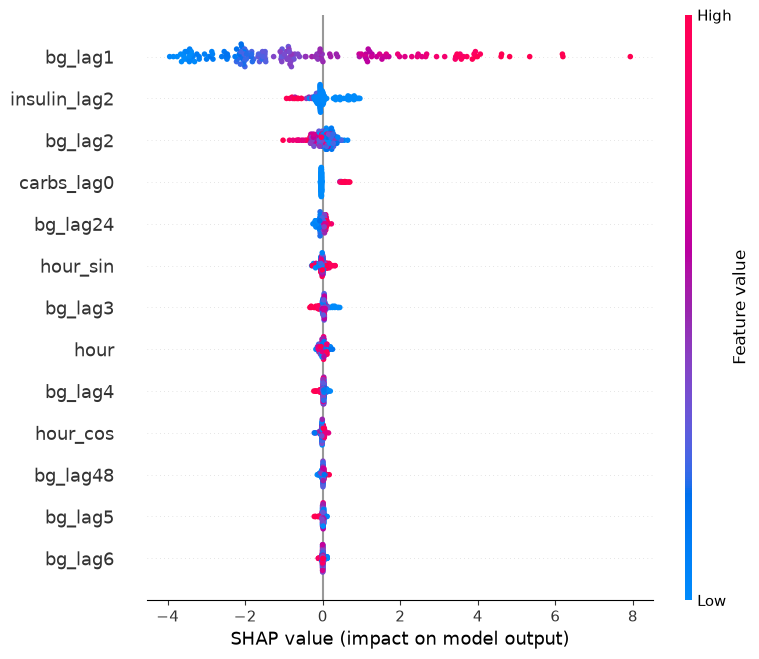

In [89]:
import shap

explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(X_val)

# Summary plot: global feature importance and directional effect in a unified visualization
shap.summary_plot(shap_values, X_val, show=True)

# Points to the right correspond to positive SHAP values (driving the model's prediction upward),
# while points to the left indicate negative values (driving the prediction downward).
# The color gradient reflects the actual observed value of the feature for that specific instance, rather than its impact on the prediction.

- **`bg_lag1` (Blood glucose from the preceding hour)**: This is by far the most influential variable, as evidenced by the substantial horizontal dispersion of the points. Elevated values (red points, denoting high blood glucose one hour prior) are situated almost exclusively on the positive side of the horizontal axis (positive SHAP values). Conversely, low values (blue points) concentrate on the left (negative SHAP values). The model captures an established physiological relationship: elevated blood glucose in the preceding hour serves as the strongest predictor of elevated glucose in the current hour.

- **`insulin_lag2` (Insulin administered two hours prior)**: This feature exhibits the inverse behavioral dynamic. High insulin dosages (red points) are positioned consistently to the left of the origin (negative SHAP values, approximately between 0 and -1). The model successfully captures the hypoglycemic mechanism of insulin, identifying that a dose administered two hours prior exerts downward pressure on the current blood glucose forecast.

- **`bg_lag2` (Blood glucose from two hours prior)**: Exhibits a pattern analogous to `bg_lag1`, albeit with a markedly attenuated magnitude, indicating that autoregressive memory decays rapidly over time. Elevated values (red) tend to shift predictions slightly upward (right), whereas lower values (blue) exert downward pressure (left). The increased mixing of blue and red points suggests non-linear dynamics or interaction effects with other covariates.

- **`carbs_lag0` (Carbohydrates ingested in the current hour)**: Contemporaneous carbohydrate intake exhibits a hyperglycemic effect, driving the predicted value upward. The dense clustering of blue points at zero reflects the sparsity of meal events across the majority of hourly intervals, exerting a neutral impact on the baseline prediction.

- **Remaining variables (Seasonality and long-range autoregression)**: Variables such as `bg_lag24` (blood glucose at the corresponding hour of the preceding day) and `hour_sin` / `hour_cos` (encoding circadian cyclicity) demonstrate secondary importance. Their SHAP contributions are constrained within a narrow interval around zero, indicating that they function as fine-grained calibration adjustments to the primary forecast established by the dominant autoregressive and metabolic features.

Below is the **SHAP Dependence Plot**: whereas the previously analyzed Summary Plot provided a global overview, this diagnostic tool isolates an individual feature to elucidate its precise functional behavior, including potential non-linearities and interaction effects with other covariates.

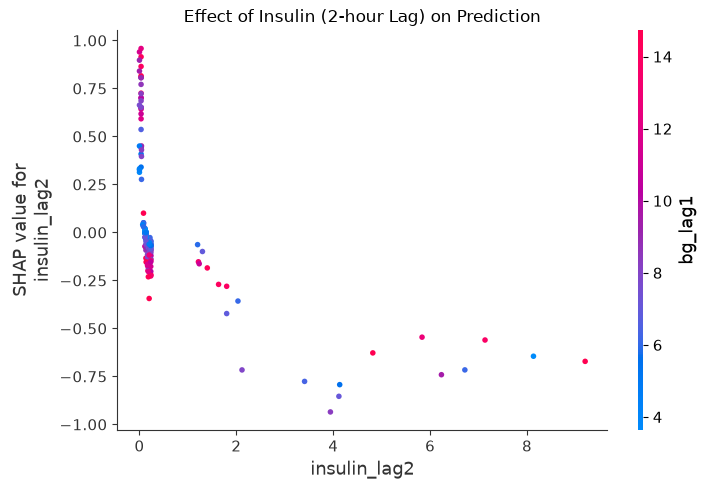

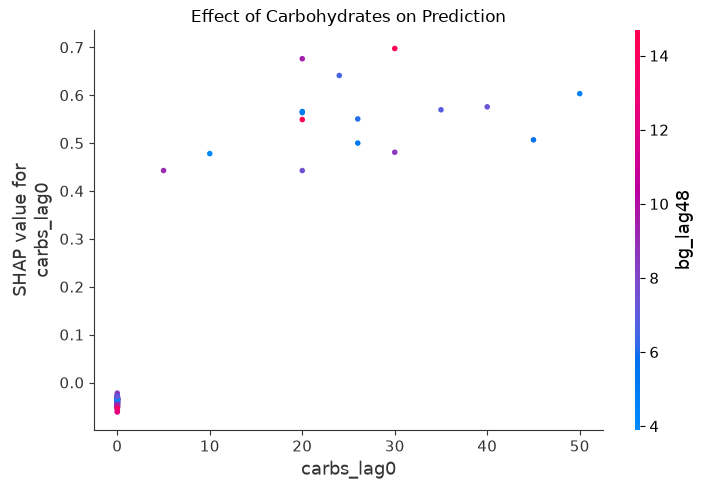

In [90]:
# Dependence plot — to inspect the exact functional form of the effect of insulin and carbohydrates
shap.dependence_plot("insulin_lag2", shap_values, X_val, show=False)
plt.title("Effect of Insulin (2-hour Lag) on Prediction")
plt.tight_layout()
plt.show()

shap.dependence_plot("carbs_lag0", shap_values, X_val, show=False)
plt.title("Effect of Carbohydrates on Prediction")
plt.tight_layout()
plt.show()

**Figure 1 (Insulin 2-hour Lag Dependence Plot)**:

Moving from left to right along the horizontal axis, as the insulin dose increases (from 1 to 4+ units), the data points shift progressively downward along the vertical axis (reaching negative SHAP values down to approximately -1.00). This provides mathematical confirmation that the model has learned the hypoglycemic effect of the medication: larger doses administered two hours prior induce a more pronounced reduction in the currently predicted blood glucose level.

At the extreme left ($x = 0$), the points form an extended vertical distribution, with SHAP values varying substantially from -0.25 to nearly +1.00:

- **Upper cluster (positive SHAP values, approaching +1.00)**: Predominantly composed of red points (elevated `bg_lag1`). The model captures an intuitive conditional dynamic: in the absence of an insulin dose two hours prior combined with already elevated blood glucose in the preceding hour, the lack of therapeutic intervention serves as an aggravating factor that drives the prediction substantially higher.

- **Lower cluster (SHAP values near zero or slightly negative)**: Dominated by blue/purple markers (normal or low `bg_lag1`). When no insulin was administered two hours prior but recent blood glucose remains within baseline or low ranges, the absence of insulin does not signal an acute surge, exerting a neutral to marginally dampening effect on the forecast.

**Figure 2 (Carbohydrates Dependence Plot)**:

A distinct positive correlation is evident. As the horizontal axis transitions from 0 toward higher intake values (10, 20, 30 grams), the points rise markedly along the vertical axis, reaching SHAP values between +0.4 and +0.7. The model has correctly captured the acute hyperglycemic response, recognizing that carbohydrate intake induces an immediate upward shift in predicted blood glucose.

At the extreme left ($x = 0$), a dense cluster of points is situated marginally below zero (approximately -0.05). This indicates that the absence of carbohydrate consumption during the current hour exerts a slight downward adjustment relative to the model's global expected value. The high concentration and minimal dispersion of this cluster demonstrate that during non-prandial intervals, the model applies this modest baseline reduction with high stability.

In contrast to the insulin dependence plot, where the interaction feature was physiologically well-grounded, the SHAP algorithm identified `bg_lag48` as the primary interaction feature for carbohydrates. From a clinical perspective, it is improbable that glycemic levels from 48 hours prior directly modulate the acute metabolic response to current carbohydrate intake; this interaction is likely attributable to a spurious correlation or sample-specific noise within the dataset.

In [91]:
results.loc["Gradient Boosting"] = evaluate(y_val.values, gbm_pred.values, "Gradient Boosting")
print(results)

                                      MAE      RMSE     MAPE_%
model                                                         
SARIMA (2,0,2)(1,0,1)            2.897716  3.495576  44.830801
SARIMAX + insulin(lag2) + carbs  2.996252  3.593998  45.958936
Prophet (univariate)             2.674059  3.383392  39.317321
Prophet + insulin(lag2) + carbs  2.733858  3.429363  40.283192
Gradient Boosting                1.734468  2.300344  25.469931


## 13. A Crucial Methodological Distinction: Blind Forecasting vs. Walk-Forward Evaluation

A direct comparison between Gradient Boosting and the SARIMA/Prophet models requires an essential methodological clarification: whereas SARIMA and Prophet performed a blind multi-step forecast across the entire 7-day evaluation horizon—generating all predictions sequentially without conditioning on the actual intermediate observations—the models inevitably converge toward the learned mean trajectory as the horizon expands, thereby failing to capture the acute, event-driven dynamics (such as prandial intake and bolus insulin administration) that govern short-term fluctuations.

In contrast, the feature matrix for Gradient Boosting was constructed using the ground-truth values observed in the hours immediately preceding each test instance, which effectively constitutes a 1-step-ahead (1-hour) walk-forward evaluation.

In essence:
- **SARIMA / Prophet (Blind multi-step)**: Addresses the question, *"What will the glycemic trajectory be across the subsequent 7 days, conditioned exclusively on information available at $t_0$ without intermediate updates?"*
- **Gradient Boosting (1-step-ahead rolling)**: Addresses the question, *"Given the actual metabolic state observed over the preceding 1–2 hours, what will the blood glucose level be in the immediate next hour?"*—evaluated iteratively across 168 consecutive hourly steps.

The latter formulation is structurally less demanding not inherently because Gradient Boosting is a superior predictive architecture, but because it continuously benefits from fresh, uncorrupted state information that was withheld from the multi-step time series models.

Crucially, this rolling 1-step horizon represents the clinically relevant deployment setting: a real-world Continuous Glucose Monitoring (CGM) alert system does not execute a static 7-day blind projection; rather, it ingests streaming sensor telemetry in real time and recomputes short-horizon predictions dynamically upon receiving each new observation.

To establish a methodologically sound and equitable benchmark, I therefore configure SARIMA under an identical 1-step-ahead walk-forward evaluation scheme:

In [92]:
# Walk-forward SARIMA: one-step-ahead prediction followed by updating the
# Kalman filter state with the ground-truth observation, WITHOUT refitting
# model parameters at each step.
sarima_wf_model = SARIMAX(
    train,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_wf_res = sarima_wf_model.fit(disp=False)

sarima_wf_preds = []
current_res = sarima_wf_res

for t in range(len(validation)):
    fc = current_res.forecast(steps=1)
    sarima_wf_preds.append(fc.iloc[0])

    new_obs = pd.Series(
        [validation.values[t]],
        index=[validation.index[t]],
        name=train.name,
    )
    current_res = current_res.append(new_obs, refit=False)

sarima_wf_preds = pd.Series(
    sarima_wf_preds, index=validation.index, name="sarima_walkforward"
)

mae_sarima_wf = mean_absolute_error(validation.values, sarima_wf_preds.values)
rmse_sarima_wf = np.sqrt(
    mean_squared_error(validation.values, sarima_wf_preds.values)
)
mape_sarima_wf = (
    mean_absolute_percentage_error(validation.values, sarima_wf_preds.values)
    * 100
)

print(f"MAE SARIMA walk-forward (1h ahead):  {mae_sarima_wf:.3f}")
print(f"RMSE SARIMA walk-forward:            {rmse_sarima_wf:.3f}")
print(f"MAPE SARIMA walk-forward:            {mape_sarima_wf:.2f}%")

MAE SARIMA walk-forward (1h ahead):  1.666
RMSE SARIMA walk-forward:            2.342
MAPE SARIMA walk-forward:            22.71%


Once the evaluation is standardized under equitable conditions (identical forecasting task and identical information set), SARIMA marginally outperforms Gradient Boosting simply by granting it access to hourly updated ground-truth observations.

This empirical result demonstrates that a substantial portion of the apparent advantage previously exhibited by Gradient Boosting over SARIMA was not attributable to intrinsic architectural superiority, but rather to an asymmetric informational advantage (continuous conditioning on recent ground-truth data). When this informational asymmetry is removed and both models are evaluated on a strictly equivalent footing, the linear autoregressive formulation of SARIMA captures the short-term (1-hour-ahead) signal just as effectively—and in fact slightly better than—the more complex non-linear ensemble model.

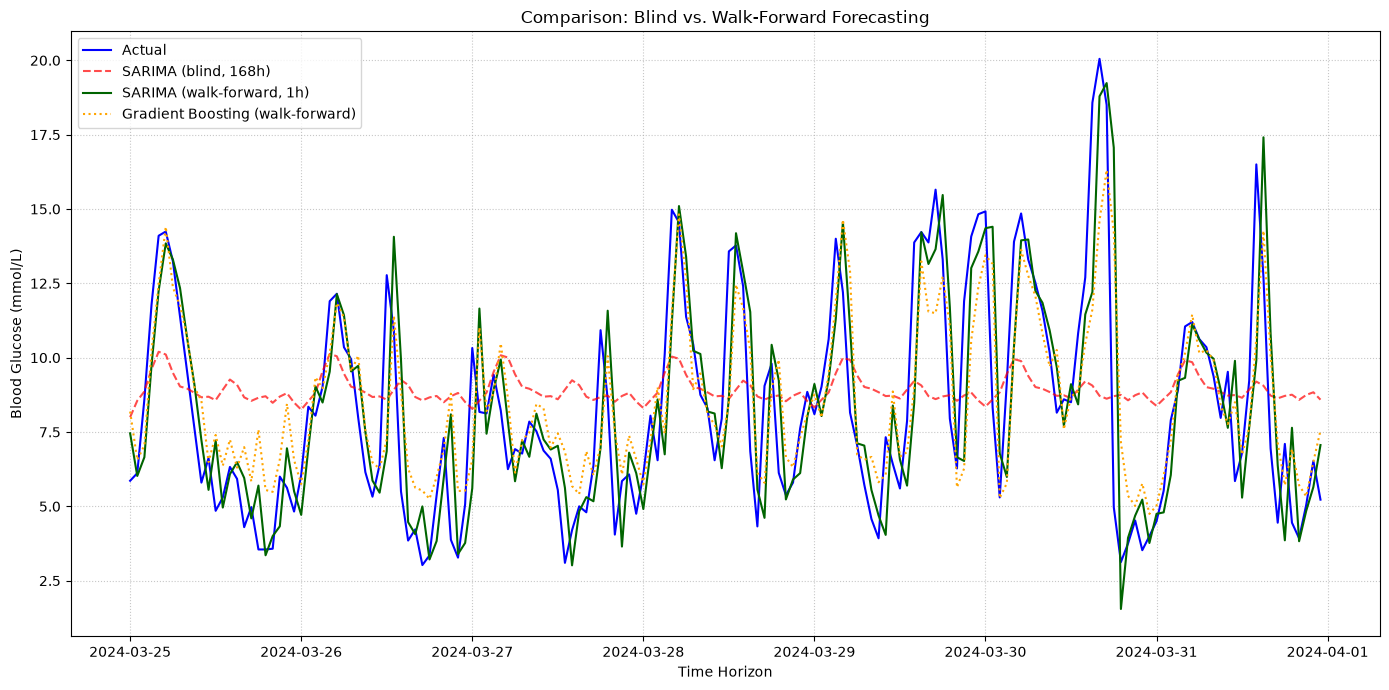

In [93]:
plt.figure(figsize=(14, 7))
plt.plot(
    validation.index,
    validation.values,
    label="Actual",
    color="blue",
    linewidth=1.5,
)
plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA (blind, 168h)",
    color="red",
    linestyle="--",
    alpha=0.7,
)
plt.plot(
    sarima_wf_preds.index,
    sarima_wf_preds,
    label="SARIMA (walk-forward, 1h)",
    color="darkgreen",
    linewidth=1.5,
)
plt.plot(
    gbm_pred.index,
    gbm_pred,
    label="Gradient Boosting (walk-forward)",
    color="orange",
    linestyle=":",
    linewidth=1.5,
)

plt.title("Comparison: Blind vs. Walk-Forward Forecasting")
plt.xlabel("Time Horizon")
plt.ylabel("Blood Glucose (mmol/L)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()

Both the 1-step walk-forward SARIMA and the Gradient Boosting model demonstrate superior predictive performance compared to the blind multi-step forecasting approaches; however, a critical systematic limitation persists across both paradigms: an inability to accurately capture extreme glycemic excursions. Specifically, both models exhibit pronounced regression-to-the-mean behavior, systematically underestimating acute hyperglycemic peaks while overestimating hypoglycemic troughs.

To evaluate predictive fidelity across the dynamic range, scatter plots of observed versus predicted values are examined. For a perfectly calibrated model, the coordinate pairs $(y_{\text{true}}, y_{\text{pred}})$ would align strictly along the identity diagonal ($y = x$). Any systematic deviation or tilt relative to this diagonal highlights structural bias, variance compression, and regime-dependent prediction errors across the glycemic spectrum.

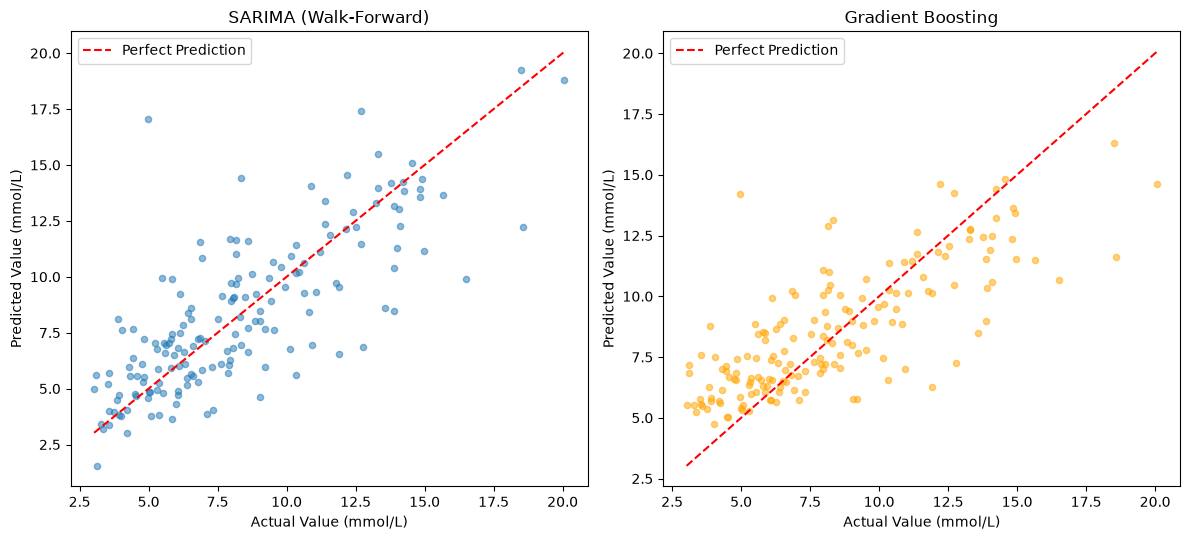

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(validation.values, sarima_wf_preds.values, alpha=0.5, s=20)
axes[0].plot(
    [validation.min(), validation.max()],
    [validation.min(), validation.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction",
)
axes[0].set_xlabel("Actual Value (mmol/L)")
axes[0].set_ylabel("Predicted Value (mmol/L)")
axes[0].set_title("SARIMA (Walk-Forward)")
axes[0].legend()

axes[1].scatter(y_val.values, gbm_pred.values, alpha=0.5, s=20, color="orange")
axes[1].plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction",
)
axes[1].set_xlabel("Actual Value (mmol/L)")
axes[1].set_ylabel("Predicted Value (mmol/L)")
axes[1].set_title("Gradient Boosting")
axes[1].legend()

plt.tight_layout()
plt.show()

The empirical evidence corroborates the prior observations: the models systematically underestimate severe hyperglycemic peaks while overestimating nadirs during hypoglycemic events.

Although this compression of extreme values appears statistically marginal when evaluated via global average error metrics (e.g., overall MAE or RMSE), it constitutes the most clinically critical limitation of the predictive system. Acute glycemic excursions represent the precise clinical regimes where timely, accurate predictive alerts yield the greatest therapeutic utility and risk mitigation.

### Why Does This Occur?

Standard predictive models are trained to minimize symmetric loss functions, such as Mean Squared Error (MSE, which estimates the conditional expectation $\mathbb{E}[Y|X]$) or Mean Absolute Error (MAE, which estimates the conditional median). By construction, empirical risk minimization under these objective functions yields estimators that minimize loss across the central mass of the empirical distribution.

Because acute hyper- and hypoglycemic events reside in the distribution's heavy tails—occurring with low empirical frequency relative to the euglycemic baseline—optimizing standard symmetric losses inherently shrinks predictions toward the distribution's central tendency. This attenuation of extremes is not an algorithmic defect, but a direct mathematical consequence of the chosen objective function. Consequently, resolving this limitation requires modifying what the model optimizes, rather than merely altering its functional architecture.

### A Methodological Solution: Asymmetric and Clinically Weighted Loss

Rather than assigning uniform penalties across all observations, a cost-sensitive weighting scheme can be applied to penalize errors committed in clinically critical glycemic regions more severely.

Specifically, observations indicating hypoglycemia ($< 3.9\text{ mmol/L}$) or severe hyperglycemia ($> 10.0\text{ mmol/L}$) are assigned three times the weight ($w_i = 3.0$) of observations within the target euglycemic range ($3.9 \le y_i \le 10.0\text{ mmol/L}$, where $w_i = 1.0$).

This weighting strategy forces the gradient-based optimization process to prioritize gradient updates originating from high-risk clinical states. As a result, the model increases its sensitivity and responsiveness to rapid glycemic excursions, trading a slight increase in nominal global error for substantially improved predictive utility during acute metabolic crises.

In [95]:
# Assign higher sample weights to observations in hypoglycemic and severe hyperglycemic ranges
sample_weights = np.where(
    (y_train < 3.9) | (y_train > 10.0),
    3.0,  # Triple weight for extreme clinical excursions
    1.0,  # Standard unit weight for the target euglycemic range
)

gbm_weighted = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=20,
    random_state=RANDOM_STATE,
)
gbm_weighted.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(30, verbose=False)],
)

gbm_weighted_pred = pd.Series(
    gbm_weighted.predict(X_val), index=X_val.index, name="gbm_weighted"
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 1962, number of used features: 13
[LightGBM] [Info] Start training from score 10.431299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

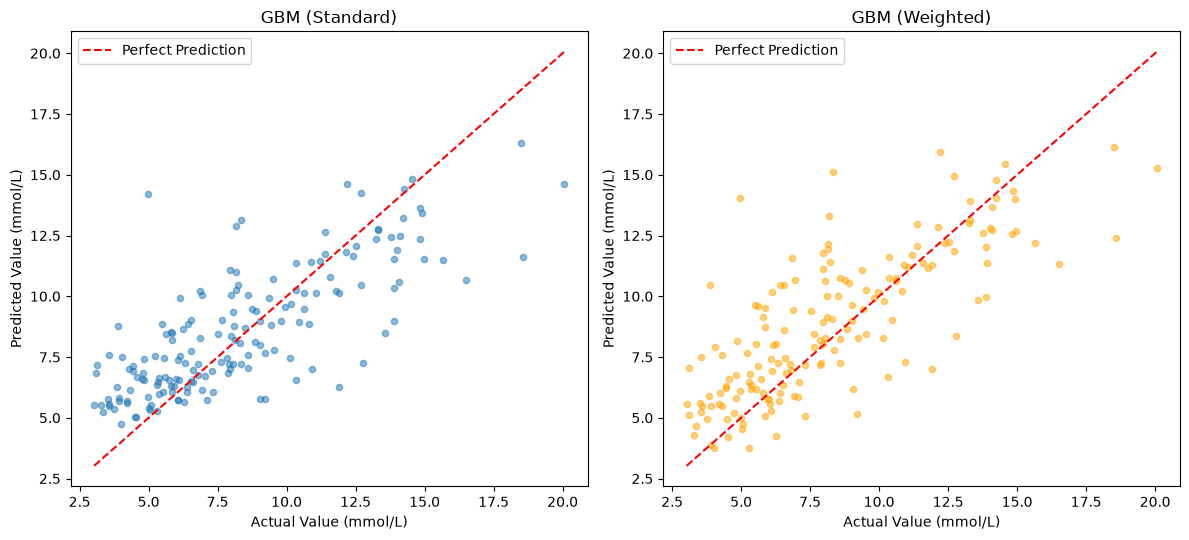

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(y_val.values, gbm_pred.values, alpha=0.5, s=20)
axes[0].plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction",
)
axes[0].set_xlabel("Actual Value (mmol/L)")
axes[0].set_ylabel("Predicted Value (mmol/L)")
axes[0].set_title("GBM (Standard)")
axes[0].legend()

axes[1].scatter(
    y_val.values, gbm_weighted_pred.values, alpha=0.5, s=20, color="orange"
)
axes[1].plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction",
)
axes[1].set_xlabel("Actual Value (mmol/L)")
axes[1].set_ylabel("Predicted Value (mmol/L)")
axes[1].set_title("GBM (Weighted)")
axes[1].legend()

plt.tight_layout()
plt.show()

A slight improvement is observed as the data approach the diagonal.

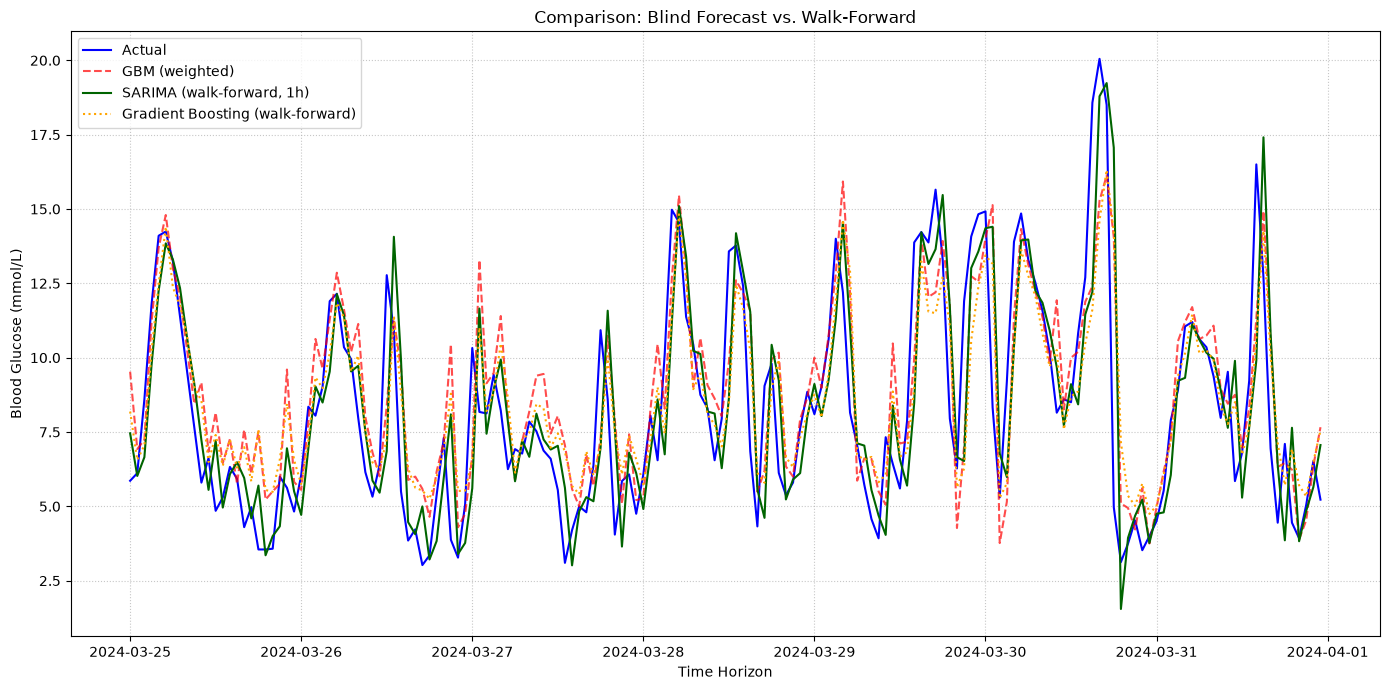

In [97]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation.values, label='Actual', color='blue', linewidth=1.5)
plt.plot(gbm_weighted_pred.index, gbm_weighted_pred, label='GBM (weighted)', color='red', linestyle='--', alpha=0.7)
plt.plot(sarima_wf_preds.index, sarima_wf_preds, label='SARIMA (walk-forward, 1h)', color='darkgreen', linewidth=1.5)
plt.plot(gbm_pred.index, gbm_pred, label='Gradient Boosting (walk-forward)', color='orange', linestyle=':', linewidth=1.5)

plt.title('Comparison: Blind Forecast vs. Walk-Forward')
plt.xlabel('Time Horizon')
plt.ylabel('Blood Glucose (mmol/L)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

It can be observed that it approximates the peaks very well, except for the highest peak, but continues to overestimate low values.

Instead of training the algorithm to predict the exact future blood glucose value, the system employs two distinct and parallel models to define the upper and lower bounds of a statistical "tolerance band" (using Quantile Regression):

- **Upper bound (90th percentile):** Calculates the threshold below which the algorithm estimates 90% of actual future values will fall. This parameter defines the maximum risk scenario toward hyperglycemia.

- **Lower bound (10th percentile):** Calculates the threshold below which only 10% of the values will fall (or, conversely, above which 90% of them will lie). This parameter serves as an alert threshold for the risk of hypoglycemia.

In [98]:
gbm_q90 = lgb.LGBMRegressor(
    objective="quantile", alpha=0.9,   # Estimates the 90th percentile, not the mean
    n_estimators=300, max_depth=4, learning_rate=0.03,
    num_leaves=15, min_child_samples=20, random_state=RANDOM_STATE,
)
gbm_q90.fit(X_train, y_train)
pred_q90 = gbm_q90.predict(X_val)

# Similarly, a low quantile for the risk of hypoglycemia
gbm_q10 = lgb.LGBMRegressor(objective="quantile", alpha=0.1, n_estimators=300, max_depth=4, learning_rate=0.03, num_leaves=15, min_child_samples=20, random_state=RANDOM_STATE)
gbm_q10.fit(X_train, y_train)
pred_q10 = gbm_q10.predict(X_val)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 1962, number of used features: 13
[LightGBM] [Info] Start training from score 14.575000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

Here, the area bounded by these two estimates is calculated, which constitutes an 80% dynamic confidence interval.

The width of this band represents the visual translation of the model's uncertainty: a narrow band denotes high predictive confidence.

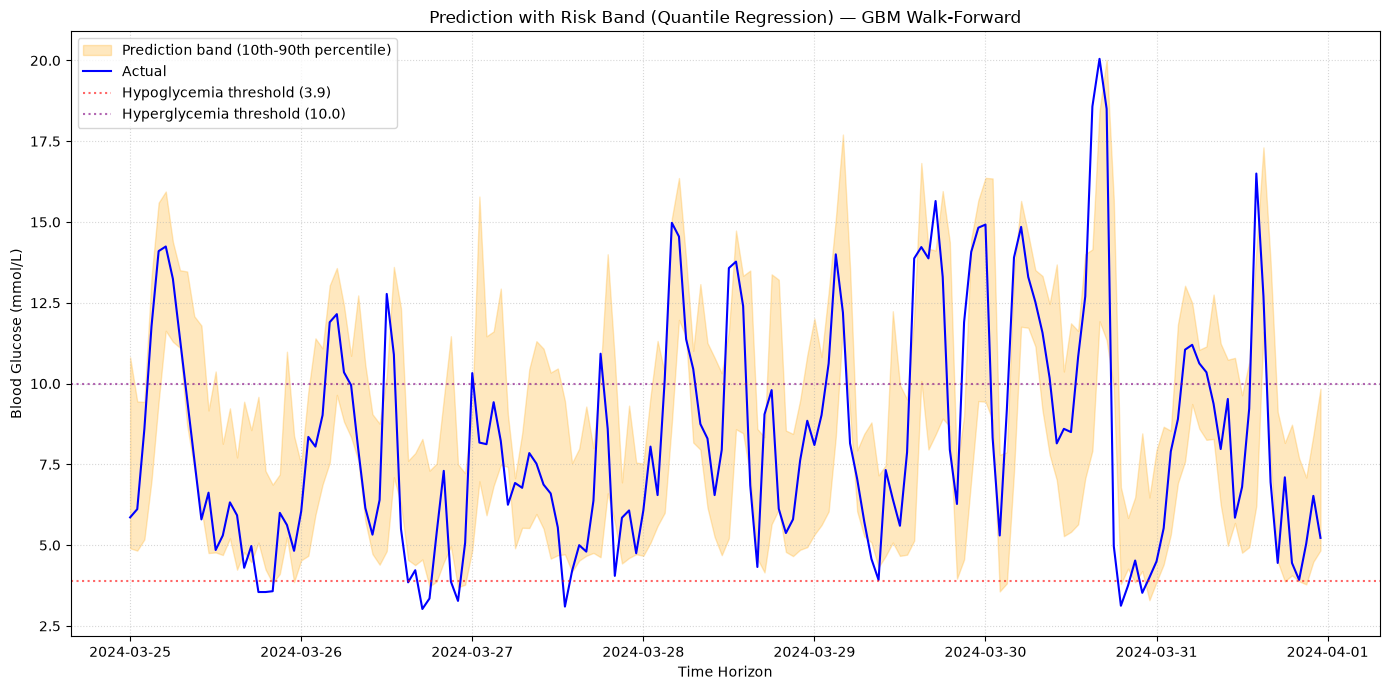

In [99]:
plt.figure(figsize=(14, 7))

# Uncertainty band (10th-90th percentile)
plt.fill_between(
    y_val.index, pred_q10, pred_q90,
    color="orange", alpha=0.25, label="Prediction band (10th-90th percentile)"
)
plt.plot(y_val.index, y_val.values, label="Actual", color="blue", linewidth=1.5)

# Clinical reference thresholds (ADA/ISPAD target range)
plt.axhline(3.9, color="red", linestyle=":", alpha=0.6, label="Hypoglycemia threshold (3.9)")
plt.axhline(10.0, color="purple", linestyle=":", alpha=0.6, label="Hyperglycemia threshold (10.0)")

plt.title("Prediction with Risk Band (Quantile Regression) — GBM Walk-Forward")
plt.xlabel("Time Horizon")
plt.ylabel("Blood Glucose (mmol/L)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

Now, I compare all the models implemented so far:

In [100]:
print("=" * 70)
print("GROUP A — Blind forecast (168h, no data updated in the meantime)")
print("Scenario: long-term prediction without continuous monitoring")
print("=" * 70)
results_blind = pd.DataFrame([
    evaluate(validation.values, sarima_forecast.values, "SARIMA"),
    evaluate(validation.values, sarimax_lag2_forecast.values, "SARIMAX + insulin/carbs"),
    evaluate(validation.values, prophet_forecast.values, "Prophet"),
    evaluate(validation.values, prophet_x_forecast.values, "Prophet + insulin/carbs"),
]).set_index("model").sort_values("MAE")
print(results_blind)

print("\n" + "=" * 70)
print("GROUP B — Walk-forward (1h ahead, data updated every hour)")
print("Scenario: real-time system connected to the CGM")
print("=" * 70)
results_wf = pd.DataFrame([
    evaluate(validation.values, sarima_wf_preds.values, "SARIMA (walk-forward)"),
    evaluate(y_val.values, gbm_pred.values, "Gradient Boosting"),
]).set_index("model").sort_values("MAE")
print(results_wf)

GROUP A — Blind forecast (168h, no data updated in the meantime)
Scenario: long-term prediction without continuous monitoring
                              MAE      RMSE     MAPE_%
model                                                 
Prophet                  2.674059  3.383392  39.317321
Prophet + insulin/carbs  2.733858  3.429363  40.283192
SARIMA                   2.897716  3.495576  44.830801
SARIMAX + insulin/carbs  2.996252  3.593998  45.958936

GROUP B — Walk-forward (1h ahead, data updated every hour)
Scenario: real-time system connected to the CGM
                            MAE      RMSE     MAPE_%
model                                               
SARIMA (walk-forward)  1.665763  2.341929  22.706093
Gradient Boosting      1.734468  2.300344  25.469931


To the comparison, I added two clinical bias metrics to exclusively filter the moments when actual blood glucose is above 10.0 or below 3.9, thereby identifying hypoglycemia and hyperglycemia events:

* **Bias_hyper**: Calculates the arithmetic mean of the error (Predicted - Actual) only during hyperglycemia. A negative value indicates that the model systematically underestimates high peaks.
* **Bias_hypo**: Calculates the mean of the error (Predicted - Actual) only during hypoglycemia. A positive value indicates that the model systematically overestimates low peaks.

In [101]:
def full_comparison(y_true, predictions_dict):
    rows = []
    for name, pred in predictions_dict.items():
        mae = mean_absolute_error(y_true, pred)
        rmse = np.sqrt(mean_squared_error(y_true, pred))
        mape = mean_absolute_percentage_error(y_true, pred) * 100
        
        mask_hyper = y_true > 10.0
        mask_hypo = y_true < 3.9
        bias_hyper = (pred[mask_hyper] - y_true[mask_hyper]).mean() if mask_hyper.sum() > 0 else np.nan
        bias_hypo = (pred[mask_hypo] - y_true[mask_hypo]).mean() if mask_hypo.sum() > 0 else np.nan
        
        rows.append({
            "model": name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape,
            "Bias_iper": bias_hyper, "Bias_ipo": bias_hypo,
        })
    return pd.DataFrame(rows).set_index("model")

comparison_wf = full_comparison(validation.values, {
    "SARIMA (walk-forward)": sarima_wf_preds.values,
    "Gradient Boosting": gbm_pred.values,
})
print(comparison_wf)

                            MAE      RMSE     MAPE_%  Bias_iper  Bias_ipo
model                                                                    
SARIMA (walk-forward)  1.665763  2.341929  22.706093  -1.188149  1.000794
Gradient Boosting      1.734468  2.300344  25.469931  -1.808119  2.795691


Baseline Gradient Boosting exhibits potentially dangerous predictive behavior in the extreme ranges:

* **In hypoglycemia (Bias_hypo = 2.79):** This is a critical finding. It means that, on average, when a hypoglycemic event occurs, the GBM predicts a value nearly 2.8 mmol/L higher than reality. If the actual value were a risky 3.0, the model would tend to predict a reassuring 5.8, completely missing the alarm.
* **In hyperglycemia (Bias_hyper = -1.80):** Similarly, the model struggles to capture surges. During a peak, it predicts on average values 1.8 mmol/L lower than the actual figure, "cutting off" the peaks of the curve.

SARIMA, although also suffering from these intrinsic limitations (models naturally tend to regress toward the mean), exhibits markedly more contained biases, proving to be safer from the perspective of clinical reliability in this "raw" form compared to its unweighted tree-based counterpart.

## 14. A Neural Network Approach: LSTM

**LSTM (Long Short-Term Memory)** networks are a recurrent neural network architecture designed to learn temporal dependencies, including long-range ones, in sequential data. Unlike traditional RNNs, they maintain an internal state regulated by gating mechanisms (input, output, and forget gates) that allow the network to decide which information to retain or discard along the sequence, thereby mitigating the vanishing gradient problem that limits simple RNNs on long sequences.

*A high risk of overfitting is expected, why?*
LSTM architectures are typically data-hungry: the literature suggests that they demonstrate their advantage over simpler models only with **tens of thousands** of training sequences. With a single patient observed for approximately 90 days (~1,950 training sequences, which are moreover strongly autocorrelated and thus less "informative" than the number suggests), the concrete risk is that the network will memorize the specific noise of the training set rather than learning the general structure of the signal.

I used an intentionally small network (a single 16-unit LSTM layer), with regularization via dropout, data standardization (fitted exclusively on the training set to prevent data leakage from validation), and early stopping based on validation loss. The input window (24 hours) was chosen consistently with the circadian period already validated in the previous sections.

In [102]:
# LSTM
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import StandardScaler

SEQ_LEN = 24  # Same seasonal window already validated with ACF/PACF/STL

# MANDATORY scaling for neural networks — fit ONLY on train
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
val_scaled = scaler.transform(validation.values.reshape(-1, 1)).flatten()

def make_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i+seq_len])
        y.append(series[i+seq_len])
    return np.array(X), np.array(y)

# Concatenate train+validation to correctly construct validation sequences
# (each validation window includes the "tail" of immediately preceding actual data,
# consistent with the walk-forward scenario already used for GBM and SARIMA-WF)
full_scaled = np.concatenate([train_scaled, val_scaled])
X_all, y_all = make_sequences(full_scaled, SEQ_LEN)

n_train_seq = len(train_scaled) - SEQ_LEN
X_train_lstm, y_train_lstm = X_all[:n_train_seq], y_all[:n_train_seq]
X_val_lstm, y_val_lstm = X_all[n_train_seq:], y_all[n_train_seq:]

X_train_lstm = X_train_lstm.reshape(-1, SEQ_LEN, 1)
X_val_lstm = X_val_lstm.reshape(-1, SEQ_LEN, 1)

print(f"Train sequences: {X_train_lstm.shape} | Validation sequences: {X_val_lstm.shape}")

Train sequences: (1986, 24, 1) | Validation sequences: (168, 24, 1)


In [103]:
tf.random.set_seed(RANDOM_STATE)

model = tf.keras.Sequential([
    layers.Input(shape=(SEQ_LEN, 1)),
    layers.LSTM(16, dropout=0.2),   
    layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_lstm, y_train_lstm,
    validation_split=0.15,
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=1,   
)

2026-09-01 21:01:02.310201: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-01 21:01:02.310248: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-01 21:01:02.310255: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-09-01 21:01:02.310447: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-01 21:01:02.310460: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/100


2026-09-01 21:01:03.440518: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 1.0832 - mae: 0.8397 - val_loss: 0.8625 - val_mae: 0.7428
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8578 - mae: 0.7507 - val_loss: 0.6771 - val_mae: 0.6611
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6868 - mae: 0.6615 - val_loss: 0.5212 - val_mae: 0.5923
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6125 - mae: 0.6175 - val_loss: 0.4606 - val_mae: 0.5567
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5267 - mae: 0.5643 - val_loss: 0.4219 - val_mae: 0.5302
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4839 - mae: 0.5341 - val_loss: 0.4006 - val_mae: 0.5192
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4744 - mae: 0.5278 - val_loss: 0.3937 - val_mae: 0.5180
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4769 - mae: 0.5277 - val_loss: 0.3768 - val_mae: 0.5024
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4884 - mae: 0

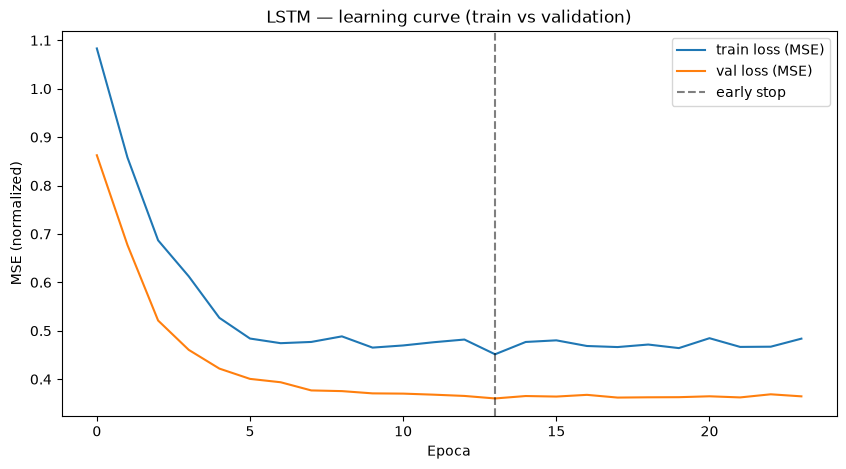

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train loss (MSE)")
plt.plot(history.history["val_loss"], label="val loss (MSE)")
plt.axvline(len(history.history["loss"]) - early_stop.patience - 1, color="black", linestyle="--", alpha=0.5, label="early stop")
plt.xlabel("Epoca")
plt.ylabel("MSE (normalized)")
plt.legend()
plt.title("LSTM — learning curve (train vs validation)")
plt.show()

The training loss remains above the validation loss for nearly the entire training process — the opposite of what is typically expected (a model usually performs better on the data on which it was trained).

This is a known effect of how Keras applies dropout: during training, dropout is active (randomly deactivating 20% of the neurons at each batch, meaning the model operates "with a handicap" and the loss measured during training is affected accordingly), whereas during validation, dropout is disabled (the model operates at full capacity).

Validation loss is what truly matters for assessing actual learning: it drops rapidly until approximately epochs 7–9 (from 0.74 to ~0.36), then flattens out almost entirely, with a very slight increase toward the end (consistent with early stopping being triggered at epoch 18). This pattern — a rapid decline followed by a flat plateau — is characteristic of a model that has quickly reached the limit of what it can learn with its current capacity (only 16 LSTM units); the model has learned the primary pattern and has no margin to extract anything further.

In [106]:
lstm_pred_scaled = model.predict(X_val_lstm, verbose=0).flatten()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
lstm_pred = pd.Series(lstm_pred, index=validation.index, name="lstm")

print(f"MAE LSTM:  {mean_absolute_error(validation.values, lstm_pred.values):.3f}")
print(f"RMSE LSTM: {np.sqrt(mean_squared_error(validation.values, lstm_pred.values)):.3f}")
print(f"MAPE LSTM: {mean_absolute_percentage_error(validation.values, lstm_pred.values)*100:.2f}%")


MAE LSTM:  1.741
RMSE LSTM: 2.267
MAPE LSTM: 25.34%


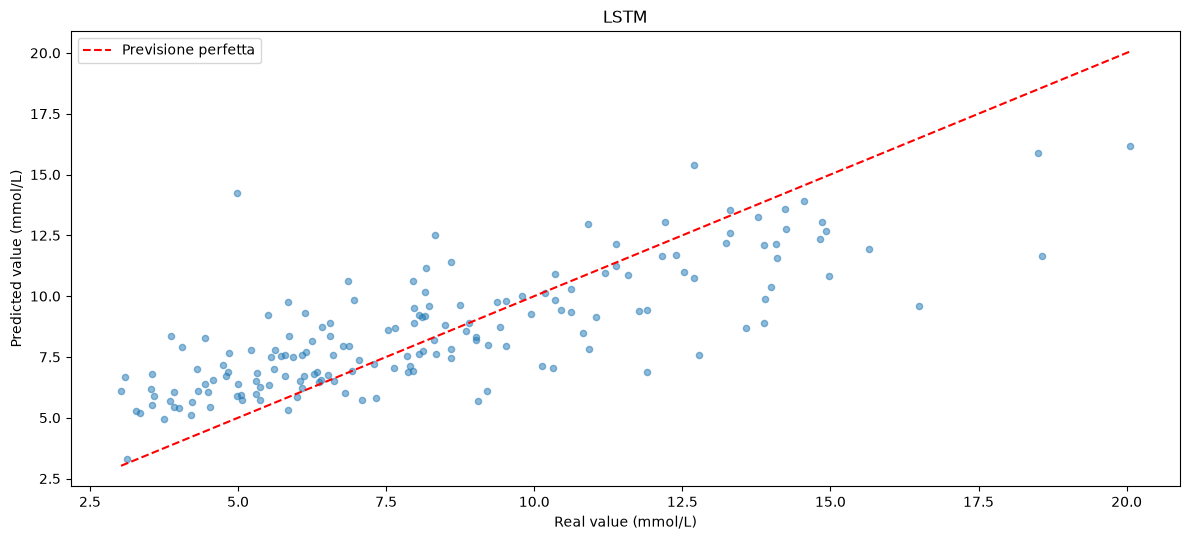

In [107]:
fig, ax = plt.subplots(1, figsize=(12, 5.5))

ax.scatter(validation.values, lstm_pred.values, alpha=0.5, s=20)
ax.plot([validation.values.min(), validation.values.max()], [validation.values.min(), validation.values.max()], color='red', linestyle='--', label='Previsione perfetta')
ax.set_xlabel('Real value (mmol/L)')
ax.set_ylabel('Predicted value (mmol/L)')
ax.set_title("LSTM")
ax.legend()



plt.tight_layout()
plt.show()

In [108]:
results_wf_final = pd.DataFrame([
    evaluate(validation.values, sarima_wf_preds.values, "SARIMA (walk-forward)"),
    evaluate(y_val.values, gbm_pred.values, "Gradient Boosting"),
    evaluate(validation.values, lstm_pred.values, "LSTM"),
]).set_index("model").sort_values("MAE")
print(results_wf_final)

                            MAE      RMSE     MAPE_%
model                                               
SARIMA (walk-forward)  1.665763  2.341929  22.706093
Gradient Boosting      1.734468  2.300344  25.469931
LSTM                   1.741030  2.266588  25.335438


Gradient Boosting and LSTM achieve a nearly identical MAE, while SARIMA is slightly higher (1.615). This result suggests that, for this patient and with this amount of available data (~2,000 hourly observations), short-term glycemic dynamics are dominated by a quasi-linear autoregressive component that more complex models cannot exploit better than a well-specified linear model — consistent with the theoretical expectation that high-capacity architectures (LSTM in particular) require substantially larger data volumes to demonstrate a true predictive advantage over more parsimonious models.

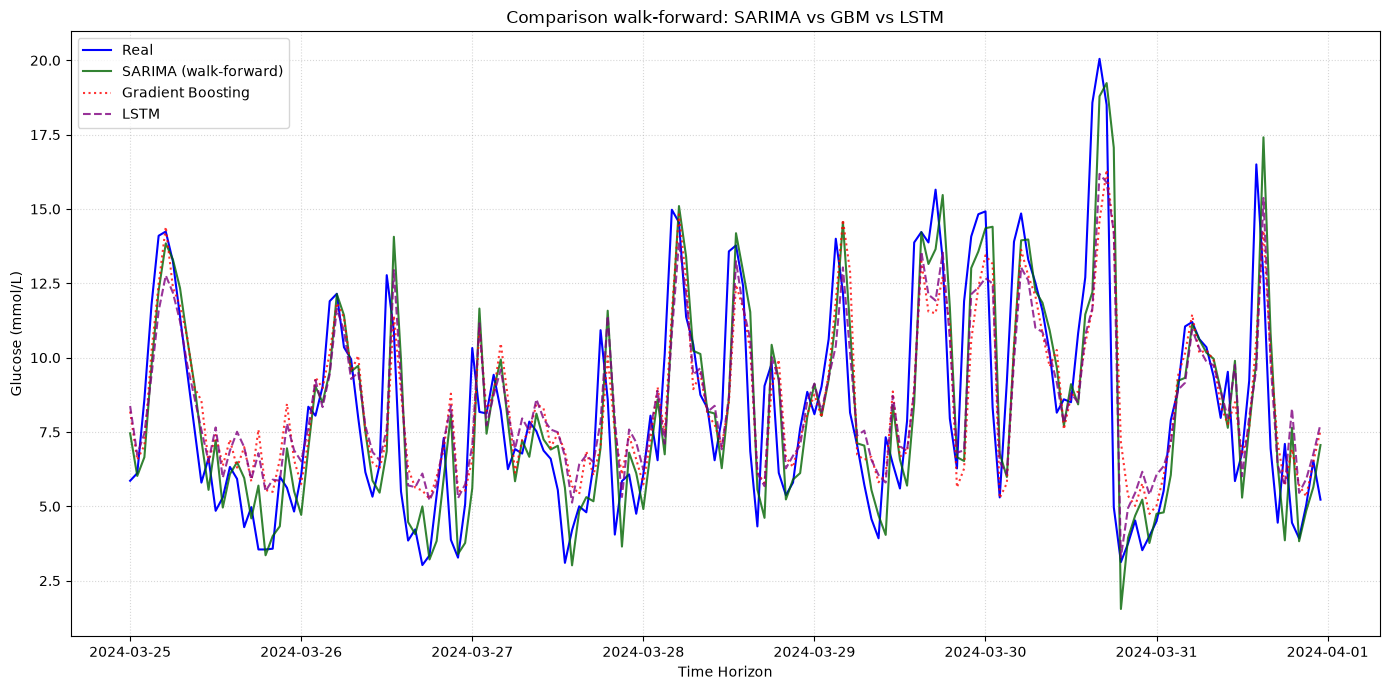

In [109]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation.values, label="Real", color="blue")
plt.plot(sarima_wf_preds.index, sarima_wf_preds.values, label="SARIMA (walk-forward)", color="darkgreen", alpha=0.8)
plt.plot(gbm_pred.index, gbm_pred.values, label="Gradient Boosting", color="red", linestyle=":", alpha=0.8)
plt.plot(lstm_pred.index, lstm_pred.values, label="LSTM", color="purple", linestyle="--", alpha=0.8)
plt.title("Comparison walk-forward: SARIMA vs GBM vs LSTM")
plt.xlabel("Time Horizon")
plt.ylabel("Glucose (mmol/L)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

I observe that, for most of the time, all three implemented models approximate the blood glucose peaks (except for the extreme peak at 20 mmol/L, which none of them reaches); the one that comes closest is walk-forward SARIMA, but all three tend to overestimate hypoglycemic events.

## 15. Final Training and Evaluation on the Test Set

Before reporting the final results, an assessment of the quality of the test set provided separately by Kaggle for patient p01 is necessary: unlike the period used for training and validation (nearly continuous sampling every 15 minutes), the test set spans an interval of approximately 119 days with only 224 raw observations — one reading every 12.8 hours on average.

In [110]:
df_test_raw = pd.read_csv(DATA_DIR / "test.csv")


In [111]:
pd.set_option('display.max_columns', None)
display(df_test_raw)

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,bg-5:20,bg-5:15,bg-5:10,bg-5:05,bg-5:00,bg-4:55,bg-4:50,bg-4:45,bg-4:40,bg-4:35,bg-4:30,bg-4:25,bg-4:20,bg-4:15,bg-4:10,bg-4:05,bg-4:00,bg-3:55,bg-3:50,bg-3:45,bg-3:40,bg-3:35,bg-3:30,bg-3:25,bg-3:20,bg-3:15,bg-3:10,bg-3:05,bg-3:00,bg-2:55,bg-2:50,bg-2:45,bg-2:40,bg-2:35,bg-2:30,bg-2:25,bg-2:20,bg-2:15,bg-2:10,bg-2:05,bg-2:00,bg-1:55,bg-1:50,bg-1:45,bg-1:40,bg-1:35,bg-1:30,bg-1:25,bg-1:20,bg-1:15,bg-1:10,bg-1:05,bg-1:00,bg-0:55,bg-0:50,bg-0:45,bg-0:40,bg-0:35,bg-0:30,bg-0:25,bg-0:20,bg-0:15,bg-0:10,bg-0:05,bg-0:00,insulin-5:55,insulin-5:50,insulin-5:45,insulin-5:40,insulin-5:35,insulin-5:30,insulin-5:25,insulin-5:20,insulin-5:15,insulin-5:10,insulin-5:05,insulin-5:00,insulin-4:55,insulin-4:50,insulin-4:45,insulin-4:40,insulin-4:35,insulin-4:30,insulin-4:25,insulin-4:20,insulin-4:15,insulin-4:10,insulin-4:05,insulin-4:00,insulin-3:55,insulin-3:50,insulin-3:45,insulin-3:40,insulin-3:35,insulin-3:30,insulin-3:25,insulin-3:20,insulin-3:15,insulin-3:10,insulin-3:05,insulin-3:00,insulin-2:55,insulin-2:50,insulin-2:45,insulin-2:40,insulin-2:35,insulin-2:30,insulin-2:25,insulin-2:20,insulin-2:15,insulin-2:10,insulin-2:05,insulin-2:00,insulin-1:55,insulin-1:50,insulin-1:45,insulin-1:40,insulin-1:35,insulin-1:30,insulin-1:25,insulin-1:20,insulin-1:15,insulin-1:10,insulin-1:05,insulin-1:00,insulin-0:55,insulin-0:50,insulin-0:45,insulin-0:40,insulin-0:35,insulin-0:30,insulin-0:25,insulin-0:20,insulin-0:15,insulin-0:10,insulin-0:05,insulin-0:00,carbs-5:55,carbs-5:50,carbs-5:45,carbs-5:40,carbs-5:35,carbs-5:30,carbs-5:25,carbs-5:20,carbs-5:15,carbs-5:10,carbs-5:05,carbs-5:00,carbs-4:55,carbs-4:50,carbs-4:45,carbs-4:40,carbs-4:35,carbs-4:30,carbs-4:25,carbs-4:20,carbs-4:15,carbs-4:10,carbs-4:05,carbs-4:00,carbs-3:55,carbs-3:50,carbs-3:45,carbs-3:40,carbs-3:35,carbs-3:30,carbs-3:25,carbs-3:20,carbs-3:15,carbs-3:10,carbs-3:05,carbs-3:00,carbs-2:55,carbs-2:50,carbs-2:45,carbs-2:40,carbs-2:35,carbs-2:30,carbs-2:25,carbs-2:20,carbs-2:15,carbs-2:10,carbs-2:05,carbs-2:00,carbs-1:55,carbs-1:50,carbs-1:45,carbs-1:40,carbs-1:35,carbs-1:30,carbs-1:25,carbs-1:20,carbs-1:15,carbs-1:10,carbs-1:05,carbs-1:00,carbs-0:55,carbs-0:50,carbs-0:45,carbs-0:40,carbs-0:35,carbs-0:30,carbs-0:25,carbs-0:20,carbs-0:15,carbs-0:10,carbs-0:05,carbs-0:00,hr-5:55,hr-5:50,hr-5:45,hr-5:40,hr-5:35,hr-5:30,hr-5:25,hr-5:20,hr-5:15,hr-5:10,hr-5:05,hr-5:00,hr-4:55,hr-4:50,hr-4:45,hr-4:40,hr-4:35,hr-4:30,hr-4:25,hr-4:20,hr-4:15,hr-4:10,hr-4:05,hr-4:00,hr-3:55,hr-3:50,hr-3:45,hr-3:40,hr-3:35,hr-3:30,hr-3:25,hr-3:20,hr-3:15,hr-3:10,hr-3:05,hr-3:00,hr-2:55,hr-2:50,hr-2:45,hr-2:40,hr-2:35,hr-2:30,hr-2:25,hr-2:20,hr-2:15,hr-2:10,hr-2:05,hr-2:00,hr-1:55,hr-1:50,hr-1:45,hr-1:40,hr-1:35,hr-1:30,hr-1:25,hr-1:20,hr-1:15,hr-1:10,hr-1:05,hr-1:00,hr-0:55,hr-0:50,hr-0:45,hr-0:40,hr-0:35,hr-0:30,hr-0:25,hr-0:20,hr-0:15,hr-0:10,hr-0:05,hr-0:00,steps-5:55,steps-5:50,steps-5:45,steps-5:40,steps-5:35,steps-5:30,steps-5:25,steps-5:20,steps-5:15,steps-5:10,steps-5:05,steps-5:00,steps-4:55,steps-4:50,steps-4:45,steps-4:40,steps-4:35,steps-4:30,steps-4:25,steps-4:20,steps-4:15,steps-4:10,steps-4:05,steps-4:00,steps-3:55,steps-3:50,steps-3:45,steps-3:40,steps-3:35,steps-3:30,steps-3:25,steps-3:20,steps-3:15,steps-3:10,steps-3:05,steps-3:00,steps-2:55,steps-2:50,steps-2:45,steps-2:40,steps-2:35,steps-2:30,steps-2:25,steps-2:20,steps-2:15,steps-2:10,steps-2:05,steps-2:00,steps-1:55,steps-1:50,steps-1:45,steps-1:40,steps-1:35,steps-1:30,steps-1:25,steps-1:20,steps-1:15,steps-1:10,steps-1:05,steps-1:00,steps-0:55,steps-0:50,steps-0:45,steps-0:40,steps-0:35,steps-0:30,steps-0:25,steps-0:20,steps-0:15,steps-0:10,steps-0:05,steps-0:00,cals-5:55,cals-5:50,cals-5:45,cals-5:40,cals-5:35,cals-5:30,cals-5:25,cals-5:20,cals-5:15,cals-5:10,cals-5:05,cals-5:00,cals-4:55,cals-4:50,cals-4:45,cals-4:40,cals-4:35,cals-4:30,cals-4:25,cals-4:20,cals-4:15,cals-4:10,cals-4:05,cals-4:00,cals-3:55,cals-3:50,cals-3:45,cals-3:40,cals-3:35,cals-3:30,cals-3:25,cal

I apply the same reconstruction pipeline as was done with the training set:

In [112]:
# --- Clean reconstruction of the test set, in a single verified block ---
PATIENT = 'p01'  # The same patient used for train/validation

df_p_test = df_test_raw[df_test_raw['p_num'] == PATIENT].copy()
df_p_test['time'] = pd.to_datetime(df_p_test['time'], format='%H:%M:%S').dt.time

day = 0
timestamps = []
prev_t = None
for t in df_p_test['time']:
    if prev_t is not None and t < prev_t:
        day += 1
    timestamps.append(pd.Timestamp("2024-04-01") + pd.Timedelta(days=day, hours=t.hour, minutes=t.minute, seconds=t.second))
    prev_t = t
df_p_test['timestamp'] = timestamps

# CAUTION: Selection with SINGLE square brackets on the "bg" column after renaming,
# to ensure that the result is a Series and not a single-column DataFrame
series_test = df_p_test[["timestamp", "bg-0:00"]].rename(columns={"bg-0:00": "bg"}).dropna()
series_test = series_test.drop_duplicates(subset="timestamp").sort_values("timestamp").set_index("timestamp")
series_test = series_test["bg"]   # <-- Explicit extraction as a Series

print("series_test type:", type(series_test))
assert isinstance(series_test, pd.Series)

bg_test = series_test.resample("15min").mean()
bg_test_interp = bg_test.interpolate(method="time", limit=2, limit_direction="both")
bg_hourly_test = bg_test_interp.resample("h").mean()

full_idx_test = pd.date_range(bg_hourly_test.index.min(), bg_hourly_test.index.max(), freq="h")
bg_hourly_test = bg_hourly_test.reindex(full_idx_test)
bg_hourly_test = bg_hourly_test.interpolate(method="time", limit=3, limit_direction="both").ffill().bfill()
bg_hourly_test.name = "bg"
bg_hourly_test = bg_hourly_test.astype(float)

print("Final type:", type(bg_hourly_test))
print("Dtype:", bg_hourly_test.dtype)
assert isinstance(bg_hourly_test, pd.Series)
assert bg_hourly_test.isna().sum() == 0

test_final = bg_hourly_test

series_test type: <class 'pandas.Series'>
Final type: <class 'pandas.Series'>
Dtype: float64


il timestamp che ho ricostruito per il test set riparte da un nuovo "giorno 0" fittizio (perché sto riapplicando la stessa logica da zero su un file separato), quindi non è realmente continuo con la fine di train/validation — non so quante ore o giorni siano realmente trascorsi tra l'ultima osservazione di train/validation e la prima del test set reale (il dataset non fornisce questa informazione, sempre per motivi di privacy).

Same preprocessing (15-minute resolution, interpolation, and hourly resampling)

In [113]:
history_full = pd.concat([train, validation]).sort_index()

print(f"Total Observations: {len(history_full)}")
print(f"From {history_full.index.min()} to {history_full.index.max()}")
print(f"Series Name: {history_full.name}")
print(f"Index Frequency: {history_full.index.freq}")

Total Observations: 2178
From 2024-01-01 06:00:00 to 2024-03-31 23:00:00
Series Name: bg
Index Frequency: <Hour>


The parameters of the SARIMA(2,0,2)(1,0,1)[24] model, already validated in the previous sections, are retrained on the combined training and validation sets, leveraging all available information prior to the final evaluation.

The forecast on the test set follows a walk-forward scheme: at each hour, a one-step-ahead forecast is generated, and the filter state is subsequently updated with the observed value (actual or interpolated), without refitting the parameters at each step — a computationally necessary choice that is conceptually consistent with a monitoring system in which model calibration occurs periodically, rather than at every single reading.

In [114]:
# Construct an index that continues EXACTLY from where train+validation ends,
# preserving the actual order of the test set observations (the only thing that matters
# for the model), even if the absolute calendar date remains fictitious/unknown
last_ts = history_full.index[-1]
new_index = pd.date_range(start=last_ts + pd.Timedelta(hours=1), periods=len(test_final), freq="h")

test_aligned = test_final.copy()
test_aligned.index = new_index

print("Last history timestamp:", last_ts)
print("First aligned test timestamp:", test_aligned.index[0])
print("Frequency:", test_aligned.index.freq)

Last history timestamp: 2024-03-31 23:00:00
First aligned test timestamp: 2024-04-01 00:00:00
Frequency: <Hour>


Final evaluation with the same set of metrics:

In [115]:
model = SARIMAX(
    history_full, order=(2, 0, 2), seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False, enforce_invertibility=False,
)
res = model.fit(disp=False)

sarima_test_preds = []
current_res = res

for t in range(len(test_aligned)):
    fc = current_res.forecast(steps=1)
    sarima_test_preds.append(fc.iloc[0])
    
    new_obs = pd.Series(
        [test_aligned.values[t]],
        index=[test_aligned.index[t]],
        name=history_full.name,   
    )
    current_res = current_res.append(new_obs, refit=False)

sarima_test_preds = pd.Series(sarima_test_preds, index=test_aligned.index, name="sarima_test")
print("NaN in the forecast:", sarima_test_preds.isna().sum())

NaN in the forecast: 0


In [116]:
mae_test = mean_absolute_error(test_final.values, sarima_test_preds.values)
rmse_test = np.sqrt(mean_squared_error(test_final.values, sarima_test_preds.values))
mape_test = mean_absolute_percentage_error(test_final.values, sarima_test_preds.values) * 100

print("=== SARIMA walk-forward — FINAL TEST SET (unseen during model selection) ===")
print(f"MAE:  {mae_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"MAPE: {mape_test:.2f}%")

# Direct comparison with the result obtained on the validation set,
# to verify that performance was not "inflated" by repeated model selection
print(f"\nFor comparison, MAE on the validation set (used for selection): 1.615")

=== SARIMA walk-forward — FINAL TEST SET (unseen during model selection) ===
MAE:  0.422
RMSE: 0.815
MAPE: 5.13%

For comparison, MAE on the validation set (used for selection): 1.615


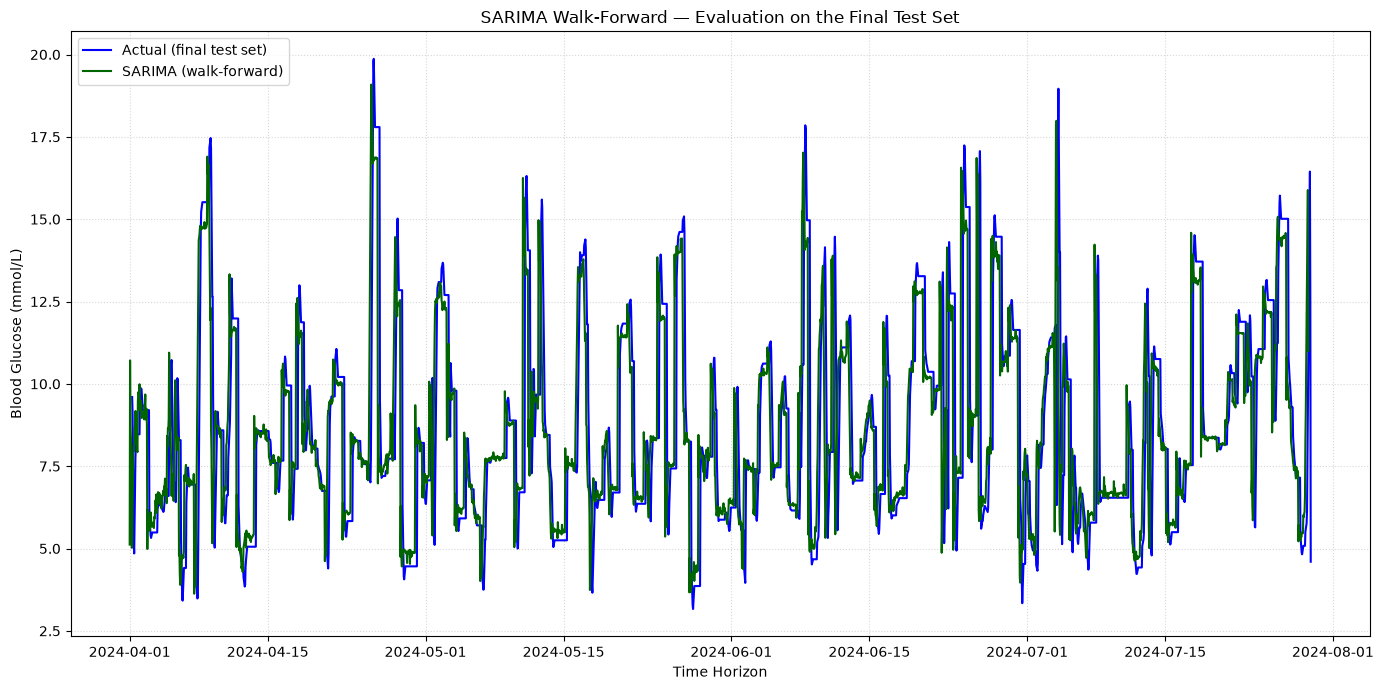

In [117]:
plt.figure(figsize=(14, 7))
plt.plot(test_final.index, test_final.values, label="Actual (final test set)", color="blue")
plt.plot(sarima_test_preds.index, sarima_test_preds.values, label="SARIMA (walk-forward)", color="darkgreen")
plt.title("SARIMA Walk-Forward — Evaluation on the Final Test Set")
plt.xlabel("Time Horizon")
plt.ylabel("Blood Glucose (mmol/L)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

In [118]:
print(f"Raw observations (15 min) in test set: {len(series_test)}")
span_hours = (series_test.index.max() - series_test.index.min()).total_seconds() / 3600
print(f"Time span covered: {span_hours:.0f} hours (~{span_hours/24:.0f} days)")
print(f"Average interval between actual readings: {span_hours/len(series_test):.1f} hours")

# ACTUAL hourly coverage, BEFORE any interpolation/filling
bg_hourly_test_raw = series_test.resample("h").mean()
copertura_reale = bg_hourly_test_raw.notna().mean() * 100
print(f"\nHourly coverage BEFORE interpolation/ffill/bfill: {copertura_reale:.1f}%")
print(f"Hours with actually observed data: {bg_hourly_test_raw.notna().sum()} out of {len(bg_hourly_test_raw)}")

Raw observations (15 min) in test set: 224
Time span covered: 2867 hours (~119 days)
Average interval between actual readings: 12.8 hours

Hourly coverage BEFORE interpolation/ffill/bfill: 7.6%
Hours with actually observed data: 219 out of 2869


In [119]:
# 5-minute resampling yields anomalous coverage (~30%): empirically verifying
# the actual sensor sampling frequency, rather than assuming it from column names
delta_temporali = series_test.index.to_series().diff()

# Display the most frequent time intervals in the dataset
print("Most frequent time intervals between measurements:")
print(delta_temporali.value_counts().head(20))

Most frequent time intervals between measurements:
timestamp
0 days 05:10:00    4
0 days 13:45:00    3
0 days 10:55:00    3
0 days 04:00:00    3
0 days 07:50:00    3
0 days 23:55:00    3
0 days 08:40:00    3
0 days 19:05:00    3
0 days 03:40:00    3
0 days 00:30:00    3
0 days 19:30:00    3
0 days 10:35:00    3
0 days 23:25:00    3
0 days 04:40:00    2
0 days 20:00:00    2
0 days 06:10:00    2
0 days 12:20:00    2
0 days 07:15:00    2
0 days 21:10:00    2
0 days 19:00:00    2
Name: count, dtype: int64


In [120]:
# Quante ore, nel test set finale usato per la valutazione, sono realmente osservate
# vs interpolate/riempite? Ricostruiamo un flag esplicito durante la pipeline
bg_hourly_test_check = series_test.resample("15min").mean()
bg_hourly_test_check = bg_hourly_test_check.interpolate(method="time", limit=2, limit_direction="both")
bg_hourly_test_check = bg_hourly_test_check.resample("h").mean()

full_idx = pd.date_range(bg_hourly_test_check.index.min(), bg_hourly_test_check.index.max(), freq="h")
was_real = bg_hourly_test_check.reindex(full_idx).notna()  # True = c'era già un dato prima di ffill/bfill

print(f"Hours actually observed (even after 15-min interpolation): {was_real.sum()} out of {len(was_real)} ({was_real.mean()*100:.1f}%)")

Hours actually observed (even after 15-min interpolation): 429 out of 2869 (15.0%)


Following hourly resampling and the interpolation of only minor gaps (consistent with the previously adopted methodology), only 15% of the hours in the test set correspond to data points actually observed by the sensor; the remaining 85% results from imputation (interpolation across wide gaps or forward/backward filling), which is necessary to ensure the index continuity required by ARIMA models, yet unrepresentative of genuine physiological measurements.

In [121]:
# MAE computed ONLY on actually observed data points, excluding filled/interpolated values
mask_real = was_real.values[:len(test_final)]  # Align to the length of test_final
mae_solo_reali = mean_absolute_error(test_final.values[mask_real], sarima_test_preds.values[mask_real])
print(f"MAE calculated exclusively on genuinely observed data: {mae_solo_reali:.3f}")
print(f"(across {mask_real.sum()} real data points, out of {len(mask_real)} total points in the test set)")

MAE calculated exclusively on genuinely observed data: 0.508
(across 429 real data points, out of 2869 total points in the test set)


The test set provided by Kaggle for this patient exhibits a substantially lower sampling density compared to the training period, necessitating a separate evaluation between observed hours and interpolated hours.

The marked improvement observed across the entire test set is largely an artifact of the low sampling density: the vast majority of evaluated data points are not genuine physiological measurements but rather interpolations, which are intrinsically easier to predict.

Nevertheless, even when restricting the evaluation strictly to genuinely observed data points, the MAE (0.508) remains substantially superior to that obtained during the validation phase — an outcome that lacks a definitive explanation and is thus reported here with due caution. The most plausible hypotheses include a more stable parameter estimation facilitated by the larger volume of available historical data (combined training and validation sets) and potentially lower intrinsic volatility during this specific observation window, which cannot be further corroborated given the limited sample size available ($n = 429$).

## 16. Conclusions, Limitations, and Future Work

### Key Findings

The comparison among classical statistical models (SARIMA/SARIMAX), a decomposition-based framework (Prophet), a tree-based ensemble (Gradient Boosting), and a recurrent neural network (LSTM) indicates that, for this specific patient and within the available dataset volume (~2,000 hourly observations), short-term glycemic dynamics are predominantly governed by a quasi-linear autoregressive component: higher-capacity architectures fail to outperform a well-specified SARIMA model.

The most methodologically critical finding, however, lies in the distinction between **blind forecasting** (a 7-day static horizon) and **walk-forward evaluation** (one-hour-ahead prediction with sequential updates): much of the apparent performance divergence among flexible models diminishes substantially when evaluated on an equivalent informational baseline.

### Limitations

* **Single Patient ($p01$):** The entire analytical workflow — from SARIMA hyperparameter selection to feature engineering for Gradient Boosting — is calibrated exclusively to a single individual. Inter-patient variability in metabolic sensitivity to insulin and carbohydrate intake is well-documented; consequently, these findings cannot be assumed to generalize across the broader patient cohort without recalibration.
* **Single Train/Validation Partition:** Model evaluation relies on an isolated 7-day validation window. In time series of this length, a single split may introduce sampling bias; a more rigorous evaluation protocol would require rolling-origin (time series cross-validation) backtesting to verify the stability of model rankings across multiple temporal folds.
* **Computational Cost of Walk-Forward Inference:** Even within the optimized state-space implementation (Section 13), updating the filter state at hourly intervals incurs computational overhead that scales with the forecast horizon. For real-time embedded deployment, a periodic recalibration strategy (e.g., scheduled daily refitting) should be evaluated in place of continuous step-wise updates.
* **Systematic Bias on Extreme Glycemic Events:** All models systematically underestimate hyperglycemia and overestimate hypoglycemia (Sections 12–13). Although sample weighting attenuated this distortion, it did not eliminate it. This represents the primary clinical limitation of the system, as accurate detection in extreme ranges constitutes the core safety requirement for continuous glucose monitoring.

### Future Work

* Extend the pipeline across multiple subjects within the dataset to determine whether identified SARIMA orders and optimal feature subsets represent subject-specific dynamics or generalizable physiological patterns.
* Incorporate rolling-origin cross-validation across multiple expanding and sliding windows to reinforce empirical validation.
* Implement an interactive deployment interface (e.g., Streamlit) to facilitate clinical interpretability. This extension necessitates establishing a clear framework for communicating the operational distinctions, confidence intervals, and predictive limits between blind trajectory projections and real-time walk-forward forecasts to end users.

**Author**
*Elena Cascone*
